In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
from scipy.stats import erlang
import string
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch
from util import *

In [2]:
STYLE = {
    "font.family": "sans-serif",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    #'pdf.fonttype': 42,
    #"font.family": "Helvetica",
    "font.sans-serif": ["Times"],
    'svg.fonttype': 'none',
}

figure_path = current_dir.parent / 'figures/'
data_path = current_dir.parent / 'data/'

single_col = 3.42
single_half_col = 4.5
double_col = 7
max_height = 9

In [3]:
# takes couple of seconds 
model1_dict = final_run_dict("model2022")
model_2ndinf = final_run_dict("model_2ndinf")
model_2nddiag = final_run_dict("model_2nddiag")
model_dpsi = final_run_dict("model_dpsi")
model_base = final_run_dict("model_base")
model_diag = final_run_dict("model_diag")
model_long = final_run_dict("model_long")


292
113
100
115
100
100
100


In [4]:
model_dicts = [model_dpsi, model_2ndinf, model_diag, model_2nddiag, model_long]
labels = ["M1", "M2", "M3", "M4", "M5"]
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd', "gold"]

In [5]:
SS_tot = np.linalg.norm(np.cumsum(data[26:]) - np.mean(np.cumsum(data[26:])))**2
print(SS_tot)
for i,model_dict in enumerate(model_dicts):
    if labels[i] == "base":
        p = 2
    else:
        p = 3
    model_dict["distance_cum_23_25"] = np.array([np.linalg.norm(row.cumsum() - np.cumsum(data[26:])) for row in model_dict["diagnosis"].loc[:,26:].to_numpy()])
    model_dict["r2"] = 1 - model_dict["distance_cum_23_25"]**2/SS_tot
    model_dict["r2_adjusted"] = 1 - (1 - model_dict["r2"]) * (len(data[26:]) - 1)/(len(data[26:]) - p - 1)

1865978.3272727272


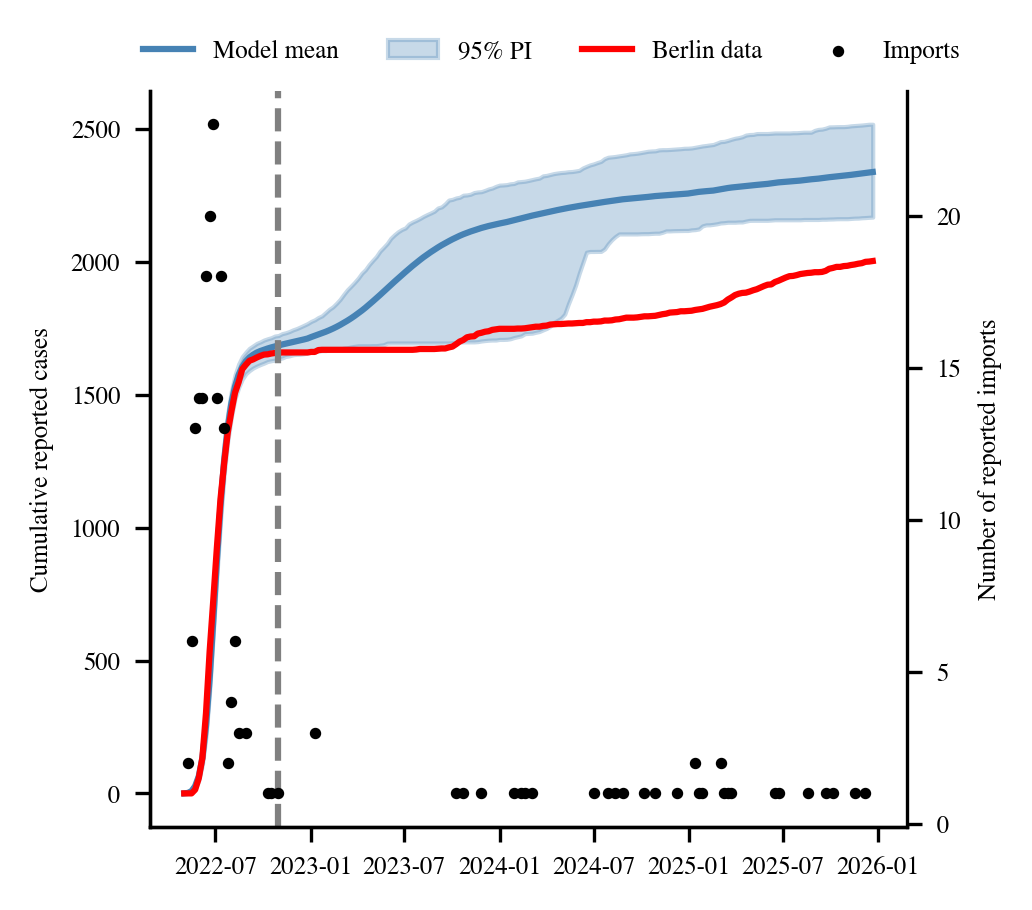

In [6]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(single_col, 3))

    ax.plot(t_label,model1_dict["diagnosis"].cumsum(axis = 1).mean(), color = "steelblue", label = "Model mean")

    ax.fill_between(t_label,
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    ax.plot(t_label, np.cumsum(berlin_mpox_all["reported_cases"]), color = "red", label = "Berlin data")
    ax.axvline(t_label[26], linestyle = "dashed", color = "grey")

    ax.set_ylabel("Cumulative reported cases")
    ax.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    #ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax.spines[['right']].set_visible(True)
    ax2 = ax.twinx()
    
    mask = (imports_t != 0) #& (t_label >= np.datetime64("2022-10-31"))
    ax2.scatter(t_label[mask], imports_t[mask], color = "black", s = 3, label = "Imports")
    #ax2.set_ylim(0,5)
    ax2.set_ylabel("Number of reported imports")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, frameon=False, ncol = 4, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    plt.tight_layout()

    plt.savefig(figure_path / "base_model_cases.pdf")
    plt.savefig(figure_path / "base_model_cases.svg")
    plt.show()

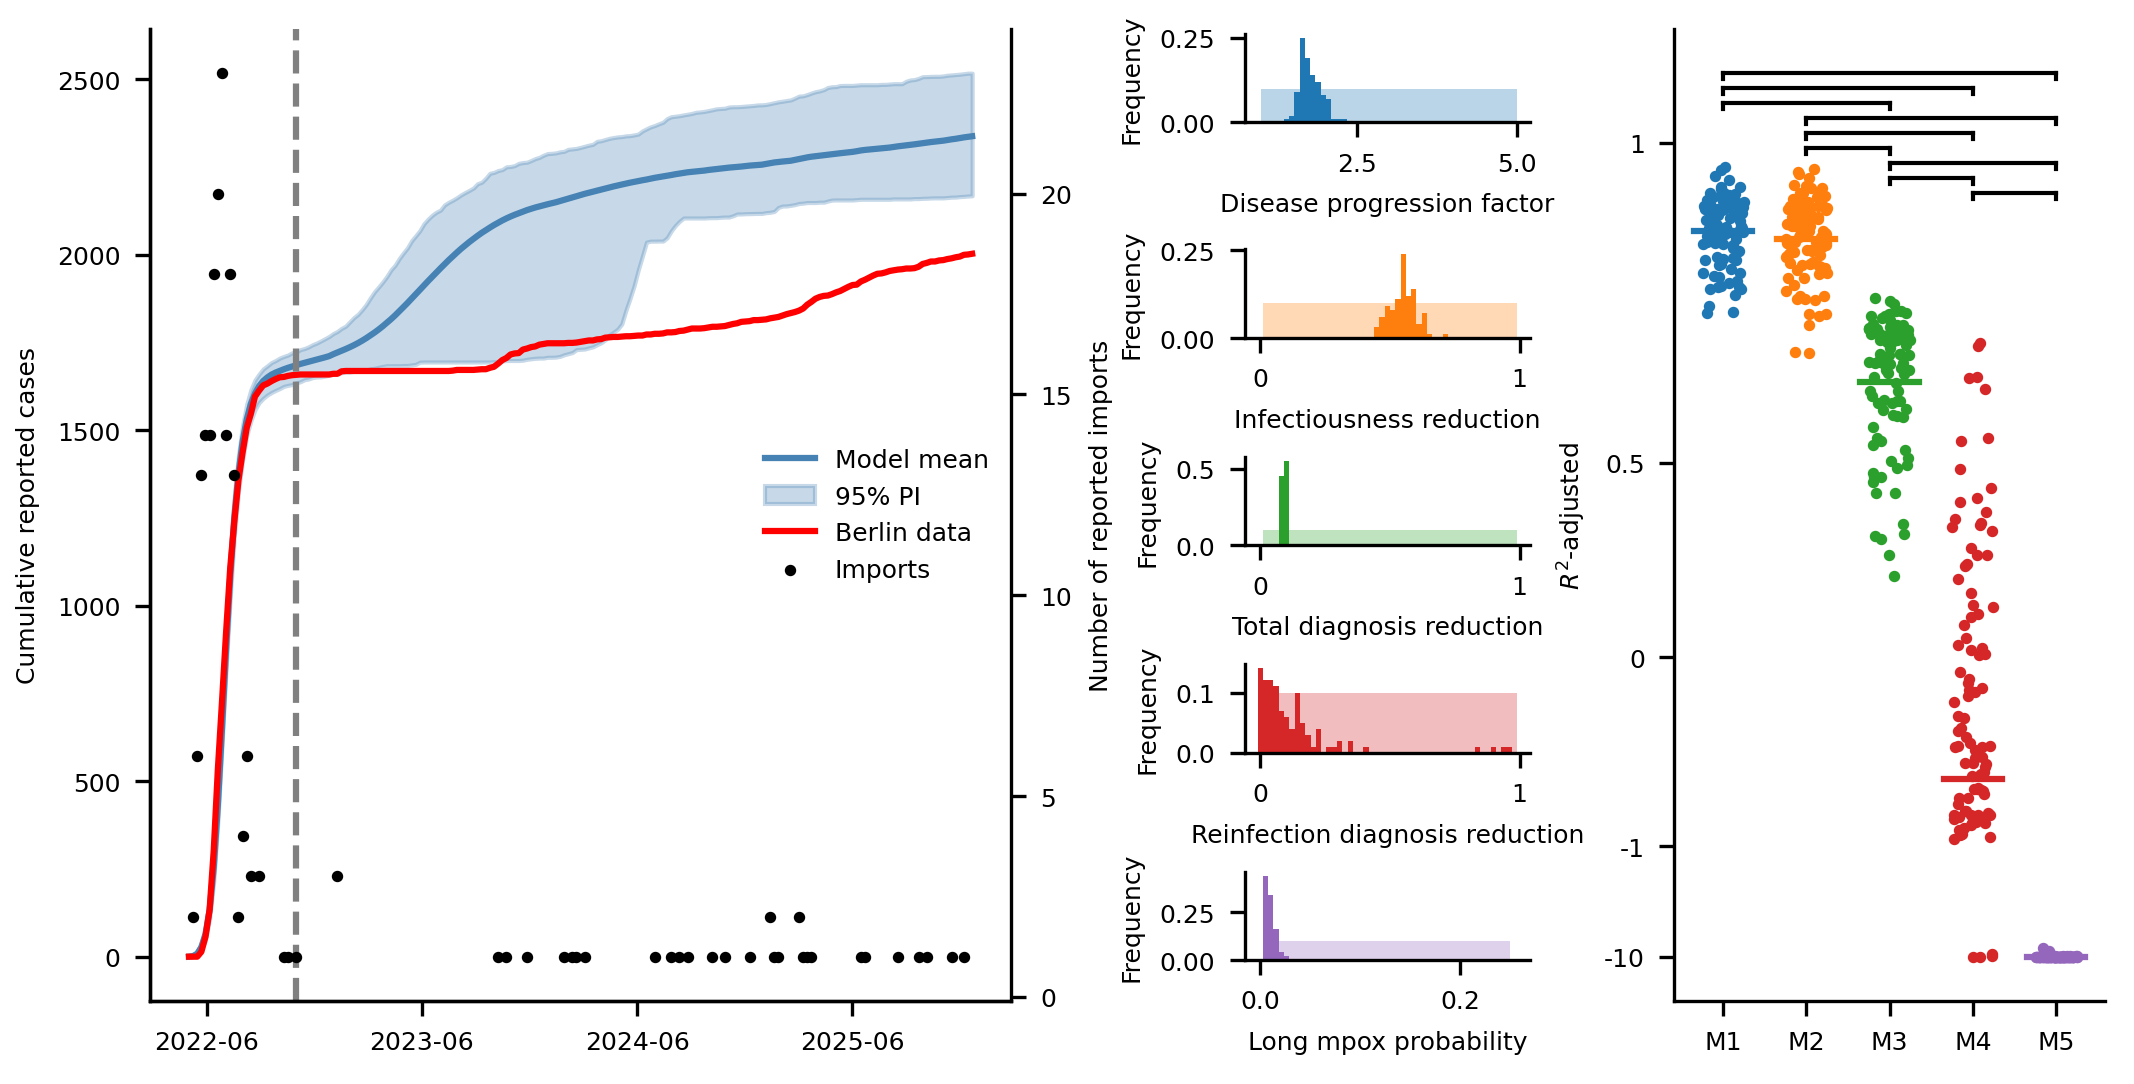

In [7]:
# base fit | posteriors | model evaluations 
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,3,figsize=(double_col, 2))
    fig = plt.figure(figsize=(double_col, 3.5), constrained_layout=True)
    gs = fig.add_gridspec(nrows=1, ncols=4)

    # A
    axA = fig.add_subplot(gs[0, 0:2])
    axA.plot(t_label,model1_dict["diagnosis"].cumsum(axis = 1).mean(), color = "steelblue", label = "Model mean")

    axA.fill_between(t_label,
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    axA.plot(t_label, np.cumsum(berlin_mpox_all["reported_cases"]), color = "red", label = "Berlin data")
    axA.axvline(t_label[26], linestyle = "dashed", color = "grey")

    axA.set_ylabel("Cumulative reported cases")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, -0.2), loc = "lower right")
    axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=6))
    axA.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    axA.spines[['right']].set_visible(True)
    ax2 = axA.twinx()
    
    mask = (imports_t != 0) #& (t_label >= np.datetime64("2022-10-31"))
    ax2.scatter(t_label[mask], imports_t[mask], color = "black", s = 3, label = "Imports")
    #ax2.set_ylim(0,5)
    ax2.set_ylabel("Number of reported imports")

    h1, l1 = axA.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    #axA.legend(h1+h2, l1+l2, frameon=False, ncol = 4, bbox_to_anchor=(1.1, 1.1), loc = "upper right")    
    axA.legend(h1+h2, l1+l2, frameon=False, ncol = 1,  loc = "center right")    

    # B
    gs_mid = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[0, 2])
    axB = [fig.add_subplot(gs_mid[i, 0]) for i in range(5)]
    # Re-Duration
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    params_reduration = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_dpsi/run1.csv'
    prior_reduration = pd.read_csv(file_path)["dpsi"]
    # Re-Inf
    file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
    params_reinf = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_2ndinf/run1.csv'
    prior_reinf = pd.read_csv(file_path)["infectiousness_2nd_factor"]
    # all-diag
    file_path = current_dir.parent / 'inputs/model_diag/final_run.csv'
    params_diag = pd.read_csv(file_path)
    prior_diag = prior_reinf
    # Re-diag
    file_path = current_dir.parent / 'inputs/model_2nddiag/final_run.csv'
    params_rediag = pd.read_csv(file_path)
    prior_rediag = prior_reinf
    # long
    file_path = current_dir.parent / 'inputs/model_long/final_run.csv'
    params_long = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_long/run1.csv'
    prior_long = pd.read_csv(file_path)["long_mpox_prob"]
    #prior_long = prior_reinf



    params_all = [params_reduration, params_reinf, params_diag, params_rediag, params_long]
    priors_all = [prior_reduration, prior_reinf, prior_diag, prior_rediag, prior_long]
    colums = ["dpsi", "infectiousness_2nd_factor", "diag", "diag_2nd_factor", "long_mpox_prob"]
    xlabels = ["Disease progression factor", "Infectiousness reduction", "Total diagnosis reduction", "Reinfection diagnosis reduction", "Long mpox probability"]

    with plt.rc_context(STYLE):
        for i in range(5):
            axi = axB[i]
            prior = priors_all[i]
            axi.hist(prior, color = colors[i], weights=np.zeros_like(prior) + 1. / prior.size, alpha = 0.3)
            counts, bins = np.histogram(params_all[i][colums[i]], bins = np.linspace(np.min(prior)-0.01, np.max(prior)+0.01, 50))
            axi.bar(bins[:-1], counts/np.sum(counts), color = colors[i], width = bins[1] - bins[0])
            #axi.hist(params_all[i][colums[i]], color = colors[i], weights=np.zeros_like(params_all[i][colums[i]]) + 1. / params_all[i][colums[i]].size)
            axi.set_xlabel(xlabels[i])
            axi.set_ylabel("Frequency")
    
    # C
    axC = fig.add_subplot(gs[0, 3])

    significant_pairs = []
    significant_labels = []
    alpha = 0.05
    for i,model_dict in enumerate(model_dicts):
        for j,model_dict2 in reversed(list(enumerate(model_dicts))):
            statistic, p_value = mannwhitneyu(model_dict["r2_adjusted"], model_dict2["r2_adjusted"], alternative='greater')
            if i != j and p_value < alpha:
                significant_pairs.append((i,j))
                tmp_label = "*"
                #if p_value < 0.01:
                #    tmp_label = "**"
                #if p_value < 0.001:
                #    tmp_label = "***"
                significant_labels.append(tmp_label)

    for i,model_dict in enumerate(model_dicts):
        df_tmp = model_dict["r2_adjusted"]
        axC.scatter(i + np.random.rand(len(df_tmp))*0.5-0.25, np.exp(df_tmp), s = 3, color = colors[i])
        axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = colors[i])
        #axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = "black", linestyle = "dashed", linewidth = 1)
    axC.set_xticks(np.arange(len(model_dicts)), labels)
    axC.set_ylabel(r"$R^2$-adjusted")

    axC.set_yticks([np.exp(1), np.exp(0.5), np.exp(0), np.exp(-1), np.exp(-10)])
    axC.set_yticklabels([1,0.5,0,-1, -10])
    axC.tick_params(axis='x')#, labelrotation=90)

    w = 0
    for (i, j) in significant_pairs:#reversed(significant_pairs):
        y = 2.95 - w *0.05 #max(max(np.exp(model_dicts[i]["r2_adjusted"])), max(np.exp(model_dicts[i]["r2_adjusted"]))) + 0.2 * w
        axC.plot([i, j ], [y, y], 'k', lw=1)
        axC.plot([i,i], [y, y-0.02], 'k', lw=1)
        axC.plot([j,j], [y, y-0.02], 'k', lw=1)
        #axC.text((i + j) / 2, y, '*', ha='center', va='bottom')
        w +=1
    
    axes = [axA, axB[0], axC]   # list all axes in the order you want labeled

    #for lab, ax in zip(string.ascii_uppercase, axes):
    #    ax.text(
    #        0.02, 0.98, lab,
    #        transform=ax.transAxes,
    #        ha="left", va="top",
    #        fontsize=12, fontweight="bold"
    #    )

    #plt.tight_layout()
    plt.savefig(figure_path / "figure2_raw.svg")


plt.show()

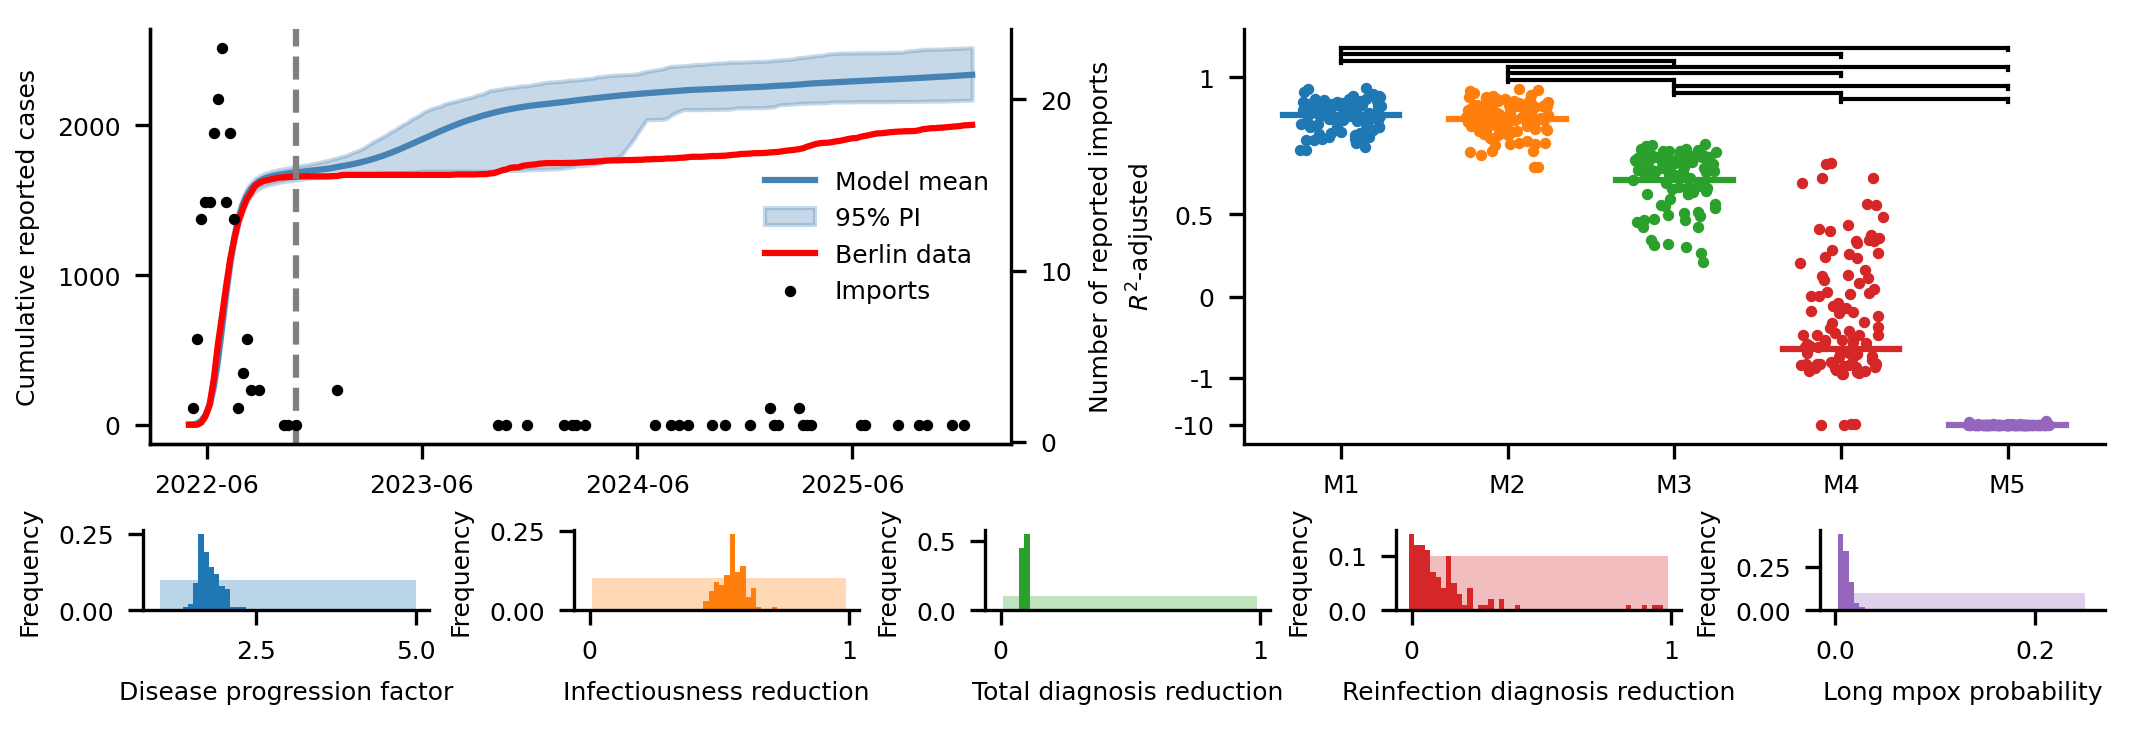

In [8]:
# base fit | posteriors | model evaluations 
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,3,figsize=(double_col, 2))
    fig = plt.figure(figsize=(double_col, 3.5*2/3), constrained_layout=True)
    gs = fig.add_gridspec(nrows=3, ncols=4)

    # A
    axA = fig.add_subplot(gs[0:2, 0:2])
    axA.plot(t_label,model1_dict["diagnosis"].cumsum(axis = 1).mean(), color = "steelblue", label = "Model mean")

    axA.fill_between(t_label,
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    axA.plot(t_label, np.cumsum(berlin_mpox_all["reported_cases"]), color = "red", label = "Berlin data")
    axA.axvline(t_label[26], linestyle = "dashed", color = "grey")

    axA.set_ylabel("Cumulative reported cases")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, -0.2), loc = "lower right")
    axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=6))
    axA.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    axA.spines[['right']].set_visible(True)
    ax2 = axA.twinx()
    
    mask = (imports_t != 0) #& (t_label >= np.datetime64("2022-10-31"))
    ax2.scatter(t_label[mask], imports_t[mask], color = "black", s = 3, label = "Imports")
    #ax2.set_ylim(0,5)
    ax2.set_ylabel("Number of reported imports")

    h1, l1 = axA.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    #axA.legend(h1+h2, l1+l2, frameon=False, ncol = 4, bbox_to_anchor=(1.1, 1.1), loc = "upper right")    
    axA.legend(h1+h2, l1+l2, frameon=False, ncol = 1,  loc = "center right")    

    # B
    gs_mid = GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[2, :])
    axB = [fig.add_subplot(gs_mid[0, i]) for i in range(5)]
    # Re-Duration
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    params_reduration = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_dpsi/run1.csv'
    prior_reduration = pd.read_csv(file_path)["dpsi"]
    # Re-Inf
    file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
    params_reinf = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_2ndinf/run1.csv'
    prior_reinf = pd.read_csv(file_path)["infectiousness_2nd_factor"]
    # all-diag
    file_path = current_dir.parent / 'inputs/model_diag/final_run.csv'
    params_diag = pd.read_csv(file_path)
    prior_diag = prior_reinf
    # Re-diag
    file_path = current_dir.parent / 'inputs/model_2nddiag/final_run.csv'
    params_rediag = pd.read_csv(file_path)
    prior_rediag = prior_reinf
    # long
    file_path = current_dir.parent / 'inputs/model_long/final_run.csv'
    params_long = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_long/run1.csv'
    prior_long = pd.read_csv(file_path)["long_mpox_prob"]
    #prior_long = prior_reinf



    params_all = [params_reduration, params_reinf, params_diag, params_rediag, params_long]
    priors_all = [prior_reduration, prior_reinf, prior_diag, prior_rediag, prior_long]
    colums = ["dpsi", "infectiousness_2nd_factor", "diag", "diag_2nd_factor", "long_mpox_prob"]
    xlabels = ["Disease progression factor", "Infectiousness reduction", "Total diagnosis reduction", "Reinfection diagnosis reduction", "Long mpox probability"]

    with plt.rc_context(STYLE):
        for i in range(5):
            axi = axB[i]
            prior = priors_all[i]
            axi.hist(prior, color = colors[i], weights=np.zeros_like(prior) + 1. / prior.size, alpha = 0.3)
            counts, bins = np.histogram(params_all[i][colums[i]], bins = np.linspace(np.min(prior)-0.01, np.max(prior)+0.01, 50))
            axi.bar(bins[:-1], counts/np.sum(counts), color = colors[i], width = bins[1] - bins[0])
            #axi.hist(params_all[i][colums[i]], color = colors[i], weights=np.zeros_like(params_all[i][colums[i]]) + 1. / params_all[i][colums[i]].size)
            axi.set_xlabel(xlabels[i])
            axi.set_ylabel("Frequency")
    
    # C
    axC = fig.add_subplot(gs[0:2, 2:])

    significant_pairs = []
    significant_labels = []
    alpha = 0.05
    for i,model_dict in enumerate(model_dicts):
        for j,model_dict2 in reversed(list(enumerate(model_dicts))):
            statistic, p_value = mannwhitneyu(model_dict["r2_adjusted"], model_dict2["r2_adjusted"], alternative='greater')
            if i != j and p_value < alpha:
                significant_pairs.append((i,j))
                tmp_label = "*"
                #if p_value < 0.01:
                #    tmp_label = "**"
                #if p_value < 0.001:
                #    tmp_label = "***"
                significant_labels.append(tmp_label)

    for i,model_dict in enumerate(model_dicts):
        df_tmp = model_dict["r2_adjusted"]
        axC.scatter(i + np.random.rand(len(df_tmp))*0.5-0.25, np.exp(df_tmp), s = 3, color = colors[i])
        axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = colors[i])
        #axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = "black", linestyle = "dashed", linewidth = 1)
    axC.set_xticks(np.arange(len(model_dicts)), labels)
    axC.set_ylabel(r"$R^2$-adjusted")

    axC.set_yticks([np.exp(1), np.exp(0.5), np.exp(0), np.exp(-1), np.exp(-10)])
    axC.set_yticklabels([1,0.5,0,-1, -10])
    axC.tick_params(axis='x')#, labelrotation=90)

    w = 0
    for (i, j) in significant_pairs:#reversed(significant_pairs):
        y = 2.95 - w *0.05 #max(max(np.exp(model_dicts[i]["r2_adjusted"])), max(np.exp(model_dicts[i]["r2_adjusted"]))) + 0.2 * w
        axC.plot([i, j ], [y, y], 'k', lw=1)
        axC.plot([i,i], [y, y-0.02], 'k', lw=1)
        axC.plot([j,j], [y, y-0.02], 'k', lw=1)
        #axC.text((i + j) / 2, y, '*', ha='center', va='bottom')
        w +=1
    
    axes = [axA, axB[0], axC]   # list all axes in the order you want labeled

    #for lab, ax in zip(string.ascii_uppercase, axes):
    #    ax.text(
    #        0.02, 0.98, lab,
    #        transform=ax.transAxes,
    #        ha="left", va="top",
    #        fontsize=12, fontweight="bold"
    #    )

    #plt.tight_layout()
    plt.savefig(figure_path / "figure2_raw.svg")


plt.show()

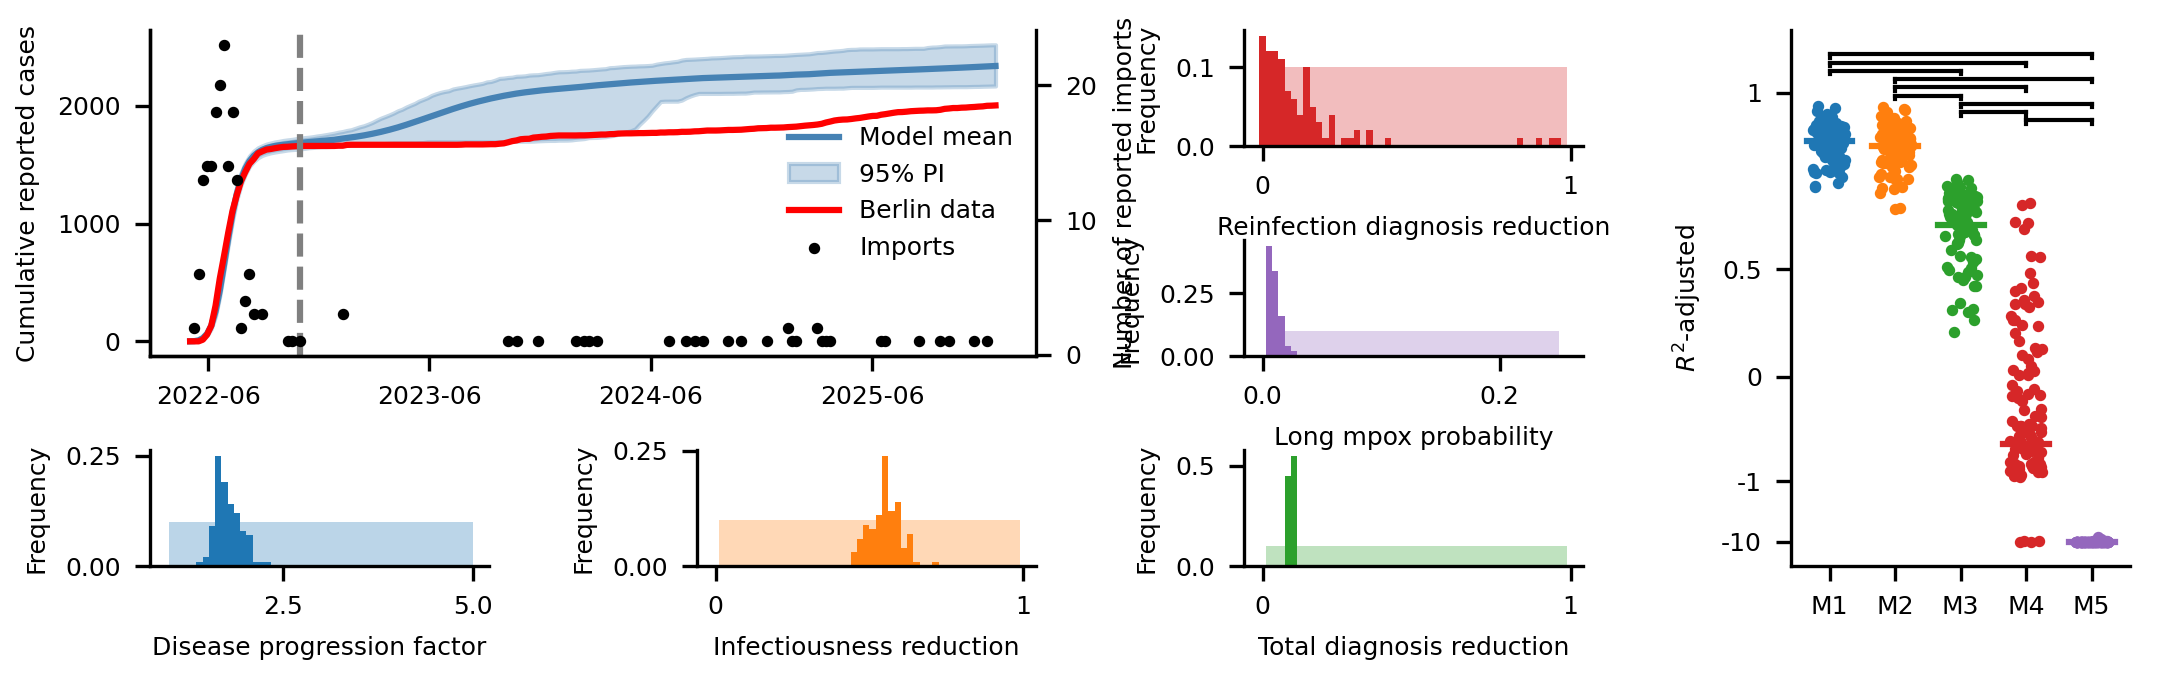

In [9]:
# base fit | posteriors | model evaluations 
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,3,figsize=(double_col, 2))
    fig = plt.figure(figsize=(double_col, 3.5/5*3))
    gs = fig.add_gridspec(nrows=3, ncols=4)

    # A
    axA = fig.add_subplot(gs[0:2, 0:2])
    axA.plot(t_label,model1_dict["diagnosis"].cumsum(axis = 1).mean(), color = "steelblue", label = "Model mean")

    axA.fill_between(t_label,
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    axA.plot(t_label, np.cumsum(berlin_mpox_all["reported_cases"]), color = "red", label = "Berlin data")
    axA.axvline(t_label[26], linestyle = "dashed", color = "grey")

    axA.set_ylabel("Cumulative reported cases")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, -0.2), loc = "lower right")
    axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=6))
    axA.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    axA.spines[['right']].set_visible(True)
    ax2 = axA.twinx()
    
    mask = (imports_t != 0) #& (t_label >= np.datetime64("2022-10-31"))
    ax2.scatter(t_label[mask], imports_t[mask], color = "black", s = 3, label = "Imports")
    #ax2.set_ylim(0,5)
    ax2.set_ylabel("Number of reported imports")

    h1, l1 = axA.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    #axA.legend(h1+h2, l1+l2, frameon=False, ncol = 4, bbox_to_anchor=(1.1, 1.1), loc = "upper right")    
    axA.legend(h1+h2, l1+l2, frameon=False, ncol = 1,  loc = "center right")    

    # B
    #gs_mid = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[0, 2])
    #axB = [fig.add_subplot(gs_mid[i, 0]) for i in range(5)]
    axB = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[2, 2]), fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 2])]
    # Re-Duration
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    params_reduration = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_dpsi/run1.csv'
    prior_reduration = pd.read_csv(file_path)["dpsi"]
    # Re-Inf
    file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
    params_reinf = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_2ndinf/run1.csv'
    prior_reinf = pd.read_csv(file_path)["infectiousness_2nd_factor"]
    # all-diag
    file_path = current_dir.parent / 'inputs/model_diag/final_run.csv'
    params_diag = pd.read_csv(file_path)
    prior_diag = prior_reinf
    # Re-diag
    file_path = current_dir.parent / 'inputs/model_2nddiag/final_run.csv'
    params_rediag = pd.read_csv(file_path)
    prior_rediag = prior_reinf
    # long
    file_path = current_dir.parent / 'inputs/model_long/final_run.csv'
    params_long = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_long/run1.csv'
    prior_long = pd.read_csv(file_path)["long_mpox_prob"]
    #prior_long = prior_reinf



    params_all = [params_reduration, params_reinf, params_diag, params_rediag, params_long]
    priors_all = [prior_reduration, prior_reinf, prior_diag, prior_rediag, prior_long]
    colums = ["dpsi", "infectiousness_2nd_factor", "diag", "diag_2nd_factor", "long_mpox_prob"]
    xlabels = ["Disease progression factor", "Infectiousness reduction", "Total diagnosis reduction", "Reinfection diagnosis reduction", "Long mpox probability"]

    with plt.rc_context(STYLE):
        for i in range(5):
            axi = axB[i]
            prior = priors_all[i]
            axi.hist(prior, color = colors[i], weights=np.zeros_like(prior) + 1. / prior.size, alpha = 0.3)
            counts, bins = np.histogram(params_all[i][colums[i]], bins = np.linspace(np.min(prior)-0.01, np.max(prior)+0.01, 50))
            axi.bar(bins[:-1], counts/np.sum(counts), color = colors[i], width = bins[1] - bins[0])
            #axi.hist(params_all[i][colums[i]], color = colors[i], weights=np.zeros_like(params_all[i][colums[i]]) + 1. / params_all[i][colums[i]].size)
            axi.set_xlabel(xlabels[i])
            axi.set_ylabel("Frequency")
    
    # C
    axC = fig.add_subplot(gs[:, 3])

    significant_pairs = []
    significant_labels = []
    alpha = 0.05
    for i,model_dict in enumerate(model_dicts):
        for j,model_dict2 in reversed(list(enumerate(model_dicts))):
            statistic, p_value = mannwhitneyu(model_dict["r2_adjusted"], model_dict2["r2_adjusted"], alternative='greater')
            if i != j and p_value < alpha:
                significant_pairs.append((i,j))
                tmp_label = "*"
                #if p_value < 0.01:
                #    tmp_label = "**"
                #if p_value < 0.001:
                #    tmp_label = "***"
                significant_labels.append(tmp_label)

    for i,model_dict in enumerate(model_dicts):
        df_tmp = model_dict["r2_adjusted"]
        axC.scatter(i + np.random.rand(len(df_tmp))*0.5-0.25, np.exp(df_tmp), s = 3, color = colors[i])
        axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = colors[i])
        #axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = "black", linestyle = "dashed", linewidth = 1)
    axC.set_xticks(np.arange(len(model_dicts)), labels)
    axC.set_ylabel(r"$R^2$-adjusted")

    axC.set_yticks([np.exp(1), np.exp(0.5), np.exp(0), np.exp(-1), np.exp(-10)])
    axC.set_yticklabels([1,0.5,0,-1, -10])
    axC.tick_params(axis='x')#, labelrotation=90)

    w = 0
    for (i, j) in significant_pairs:#reversed(significant_pairs):
        y = 2.95 - w *0.05 #max(max(np.exp(model_dicts[i]["r2_adjusted"])), max(np.exp(model_dicts[i]["r2_adjusted"]))) + 0.2 * w
        axC.plot([i, j ], [y, y], 'k', lw=1)
        axC.plot([i,i], [y, y-0.02], 'k', lw=1)
        axC.plot([j,j], [y, y-0.02], 'k', lw=1)
        #axC.text((i + j) / 2, y, '*', ha='center', va='bottom')
        w +=1
    
    axes = [axA, axB[0], axC]   # list all axes in the order you want labeled

    #for lab, ax in zip(string.ascii_uppercase, axes):
    #    ax.text(
    #        0.02, 0.98, lab,
    #        transform=ax.transAxes,
    #        ha="left", va="top",
    #        fontsize=12, fontweight="bold"
    #    )

    plt.tight_layout(pad=0.0, w_pad=0., h_pad=0.)
    plt.savefig(figure_path / "figure2_raw.svg")


plt.show()

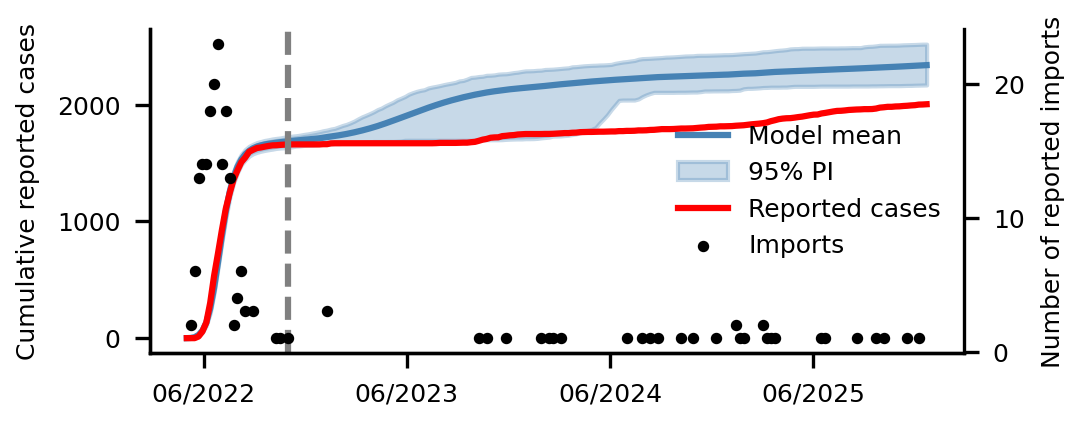

In [10]:
# base fit
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,3,figsize=(double_col, 2))
    fig = plt.figure(figsize=(double_col/2, 3.5/5*2))

    # A
    axA = fig.add_subplot()
    axA.plot(t_label,model1_dict["diagnosis"].cumsum(axis = 1).mean(), color = "steelblue", label = "Model mean")

    axA.fill_between(t_label,
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].cumsum(axis = 1).quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    axA.plot(t_label, np.cumsum(berlin_mpox_all["reported_cases"]), color = "red", label = "Reported cases")
    axA.axvline(t_label[26], linestyle = "dashed", color = "grey")

    axA.set_ylabel("Cumulative reported cases")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    #axA.legend(frameon=False, ncol = 3, bbox_to_anchor=(1.1, -0.2), loc = "lower right")
    axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=6))
    axA.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

    axA.spines[['right']].set_visible(True)
    ax2 = axA.twinx()
    
    mask = (imports_t != 0) #& (t_label >= np.datetime64("2022-10-31"))
    ax2.scatter(t_label[mask], imports_t[mask], color = "black", s = 3, label = "Imports")
    #ax2.set_ylim(0,5)
    ax2.set_ylabel("Number of reported imports")

    h1, l1 = axA.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    #axA.legend(h1+h2, l1+l2, frameon=False, ncol = 4, bbox_to_anchor=(1.1, 1.1), loc = "upper right")    
    axA.legend(h1+h2, l1+l2, frameon=False, ncol = 1,  loc = "center right")    

    #plt.tight_layout(pad=0.0, w_pad=0., h_pad=0.)
    plt.savefig(figure_path / "extrapolated_fit.svg")

plt.show()

M1 1.8202 1.5444 2.1525
M2 0.5587 0.4701 0.6435
M3 0.1044 0.1007 0.1136
M4 0.1394 0.0089 0.8846
M5 0.0133 0.01 0.0245


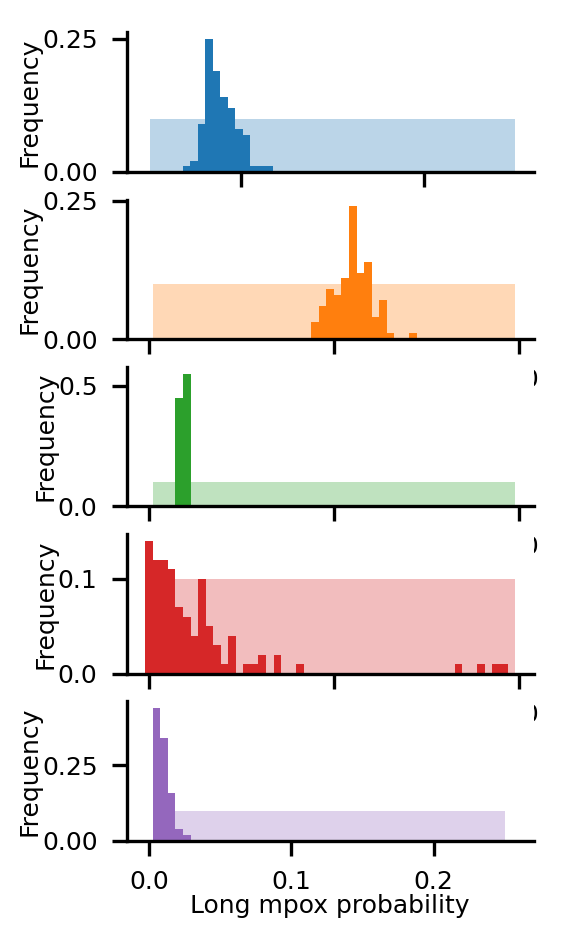

In [11]:
# base fit | posteriors | model evaluations 
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,3,figsize=(double_col, 2))
    fig, axB = plt.subplots(5,1,figsize=(double_col/4, 3.5))
      

    # B
    #gs_mid = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[0, 2])
    #axB = [fig.add_subplot(gs_mid[i, 0]) for i in range(5)]
    # Re-Duration
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    params_reduration = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_dpsi/run1.csv'
    prior_reduration = pd.read_csv(file_path)["dpsi"]
    # Re-Inf
    file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
    params_reinf = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_2ndinf/run1.csv'
    prior_reinf = pd.read_csv(file_path)["infectiousness_2nd_factor"]
    # all-diag
    file_path = current_dir.parent / 'inputs/model_diag/final_run.csv'
    params_diag = pd.read_csv(file_path)
    prior_diag = prior_reinf
    # Re-diag
    file_path = current_dir.parent / 'inputs/model_2nddiag/final_run.csv'
    params_rediag = pd.read_csv(file_path)
    prior_rediag = prior_reinf
    # long
    file_path = current_dir.parent / 'inputs/model_long/final_run.csv'
    params_long = pd.read_csv(file_path)
    file_path = current_dir.parent / 'inputs/model_long/run1.csv'
    prior_long = pd.read_csv(file_path)["long_mpox_prob"]
    #prior_long = prior_reinf



    params_all = [params_reduration, params_reinf, params_diag, params_rediag, params_long]
    priors_all = [prior_reduration, prior_reinf, prior_diag, prior_rediag, prior_long]
    colums = ["dpsi", "infectiousness_2nd_factor", "diag", "diag_2nd_factor", "long_mpox_prob"]
    xlabels = ["Disease progression factor", "Infectiousness reduction", "Total diagnosis reduction", "Reinfection diagnosis reduction", "Long mpox probability"]

    with plt.rc_context(STYLE):
        for i in range(5):
            axi = axB[i]
            prior = priors_all[i]
            axi.hist(prior, color = colors[i], weights=np.zeros_like(prior) + 1. / prior.size, alpha = 0.3)
            counts, bins = np.histogram(params_all[i][colums[i]], bins = np.linspace(np.min(prior)-0.01, np.max(prior)+0.01, 50))
            axi.bar(bins[:-1], counts/np.sum(counts), color = colors[i], width = bins[1] - bins[0])
            #axi.hist(params_all[i][colums[i]], color = colors[i], weights=np.zeros_like(params_all[i][colums[i]]) + 1. / params_all[i][colums[i]].size)
            axi.set_xlabel(xlabels[i], labelpad = 0)
            axi.set_ylabel("Frequency", labelpad = 0)
            print(labels[i], np.round(params_all[i][colums[i]].mean(), 4),np.round(params_all[i][colums[i]].quantile(0.025), 4), np.round(params_all[i][colums[i]].quantile(0.975), 4))
    
    

    #plt.tight_layout(pad=0.0, w_pad=0., h_pad=0.)
    plt.savefig(figure_path / "model_posterior.svg")

plt.show()

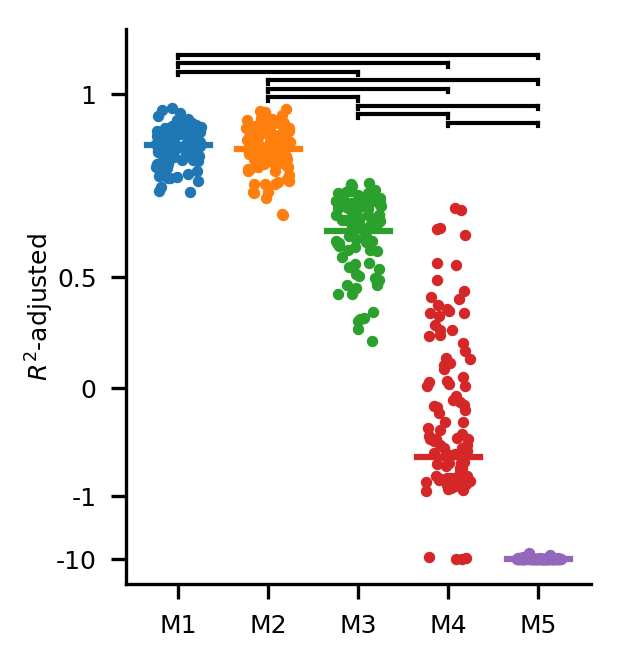

In [12]:
# base fit | posteriors | model evaluations 
with plt.rc_context(STYLE):
    fig, axC = plt.subplots(1,1,figsize=(double_col/3.5, 3.5/5*3+0.3))

    
    # C
    significant_pairs = []
    significant_labels = []
    alpha = 0.05
    for i,model_dict in enumerate(model_dicts):
        for j,model_dict2 in reversed(list(enumerate(model_dicts))):
            statistic, p_value = mannwhitneyu(model_dict["r2_adjusted"], model_dict2["r2_adjusted"], alternative='greater')
            if i != j and p_value < alpha:
                significant_pairs.append((i,j))
                tmp_label = "*"
                #if p_value < 0.01:
                #    tmp_label = "**"
                #if p_value < 0.001:
                #    tmp_label = "***"
                significant_labels.append(tmp_label)

    for i,model_dict in enumerate(model_dicts):
        df_tmp = model_dict["r2_adjusted"]
        axC.scatter(i + np.random.rand(len(df_tmp))*0.5-0.25, np.exp(df_tmp), s = 3, color = colors[i])
        axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = colors[i])
        #axC.plot([i-0.35, i+0.35], [np.exp(df_tmp.mean()),np.exp(df_tmp.mean())], color = "black", linestyle = "dashed", linewidth = 1)
    axC.set_xticks(np.arange(len(model_dicts)), labels)
    axC.set_ylabel(r"$R^2$-adjusted", labelpad = 0)

    axC.set_yticks([np.exp(1), np.exp(0.5), np.exp(0), np.exp(-1), np.exp(-10)])
    axC.set_yticklabels([1,0.5,0,-1, -10])
    axC.tick_params(axis='x')#, labelrotation=90)

    w = 0
    for (i, j) in significant_pairs:#reversed(significant_pairs):
        y = 2.95 - w *0.05 #max(max(np.exp(model_dicts[i]["r2_adjusted"])), max(np.exp(model_dicts[i]["r2_adjusted"]))) + 0.2 * w
        axC.plot([i, j ], [y, y], 'k', lw=1)
        axC.plot([i,i], [y, y-0.02], 'k', lw=1)
        axC.plot([j,j], [y, y-0.02], 'k', lw=1)
        #axC.text((i + j) / 2, y, '*', ha='center', va='bottom')
        w +=1

    plt.savefig(figure_path / "model_comparison.svg")
    

plt.show()

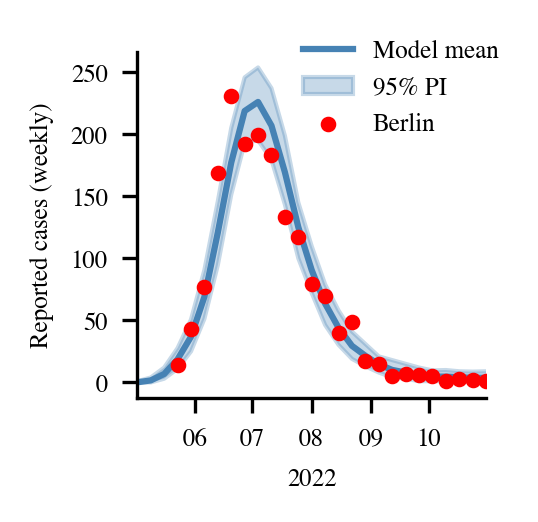

In [13]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    ax.plot(t_label,model1_dict["diagnosis"].mean(), color = "steelblue", label = "Model mean")

    ax.fill_between(t_label,
                    model1_dict["diagnosis"].quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    mask = berlin_mpox_all["reported_cases"]>0
    ax.scatter(berlin_mpox_all[mask]["start_date_week"], berlin_mpox_all[mask]["reported_cases"], color = "red", label = "Berlin", zorder = 2, s = 7.5)
    ax.set_xlim(t_label[0],t_label[26])
    ax.set_ylabel("Reported cases (weekly)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
    ax.set_xlabel("2022")
    ax.legend(frameon=False, ncol = 1, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    plt.savefig(figure_path / "fit_to_cases.svg")
    plt.show()

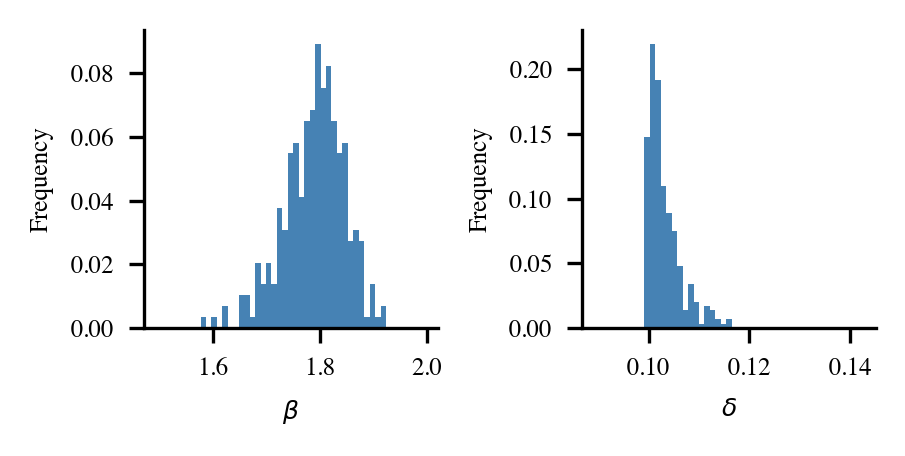

In [14]:
params = ["beta", "diag"]
bins = [np.linspace(1.5,2.0,50),np.linspace(0.09,0.143,50)]
labels = [r"$\beta$", r"$\delta$"]

scale_I = 2/5
#accepted_params["diag_prob"] = 1 - (1/scale_I/(accepted_params["diag"]+1/scale_I))**5
#accepted_params["infection_prob"] = accepted_params["beta"]/(accepted_params["beta"] + accepted_params["diag"])*(1 - ((1/scale_I)/(accepted_params["beta"] + accepted_params["diag"] + (1/scale_I)))**5)
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,2, figsize=(3, 1.5))
    for i in range(2):
        counts, bin = np.histogram(accepted_params[params[i]], bins = bins[i])
        ax[i].bar(bin[:-1], counts/np.sum(counts), color = "steelblue", width = bin[1] - bin[0])
        ax[i].set_xlabel(labels[i])
        ax[i].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.savefig(figure_path / "posteriors_beta_gamma.svg")
    plt.show() 

In [15]:
def pop_immune_decomposition(ax, model, year, pos = 0):
    data_df = model["infection_risk"+year].sum(axis = 1).mean()/np.sum(P_k0)
    vacc2_df = model["vaccination2_risk"+year].sum(axis = 1).mean()/np.sum(P_k0)
    vacc1_df = (model["vaccination1_risk"+year].sum(axis = 1).mean() - vacc2_df)/np.sum(P_k0)
    bc_df =  (- model["br_risk"+year] + counts_bc).sum(axis = 1).mean()/np.sum(P_k0)

    ax.bar(pos, bc_df, bottom = (data_df+vacc2_df+vacc1_df), label = "Reduced behaviour", color = "tab:red")
    ax.bar(pos, vacc1_df, bottom = (data_df+vacc2_df), label = "Protected vaccination", color = "tab:blue")
    ax.bar(pos, vacc2_df, bottom = (data_df), label = "Protected fully vaccinated", color = "tab:orange")
    ax.bar(pos, data_df, label = "Protected infection", color = "tab:green")

def pop_S(ax, model, year, pos = 0):
    data_df = model["infection_risk"+year]
    vacc2_df = model["vaccination2_risk"+year]
    vacc1_df = model["vaccination1_risk"+year]- vacc2_df
    bc_df =  (- model["br_risk"+year] + counts_bc)

    ax.plot(np.arange(1,61), np.ones(60) - (data_df + vacc2_df + vacc1_df + bc_df).mean()/P_k0)
    ax.fill_between(np.arange(1,61),
                    np.ones(60) - (data_df + vacc2_df + vacc1_df + bc_df).quantile(0.025).to_numpy(dtype=float)/P_k0,
                    np.ones(60) - (data_df + vacc2_df + vacc1_df + bc_df).quantile(0.975).to_numpy(dtype=float)/P_k0,
                    alpha = 0.3)


def pop_immune_decomposition_k(ax, model, year):
    data_df = model["infection_risk"+year]
    vacc2_df = model["vaccination2_risk"+year]
    vacc1_df = model["vaccination1_risk"+year] - vacc2_df
    bc_df = - model["br_risk"+year] + counts_bc

    ax.bar(np.arange(1,61),bc_df.mean()/P_k0, bottom = (data_df+vacc2_df+vacc1_df).mean()/P_k0, label = "Reduced behaviour", color = "tab:red")
    ax.bar(np.arange(1,61),vacc1_df.mean()/P_k0, bottom = (data_df+vacc2_df).mean()/P_k0, label = "Protected vaccination", color = "tab:blue")
    ax.bar(np.arange(1,61),vacc2_df.mean()/P_k0, bottom = (data_df).mean()/P_k0, label = "Protected fully vaccinated", color = "tab:orange")
    ax.bar(np.arange(1,61),data_df.mean()/P_k0, label = "Protected infection", color = "tab:green")
    ax.plot([0,61], [1,1], color = "black", linestyle = "dashed", linewidth = 1)



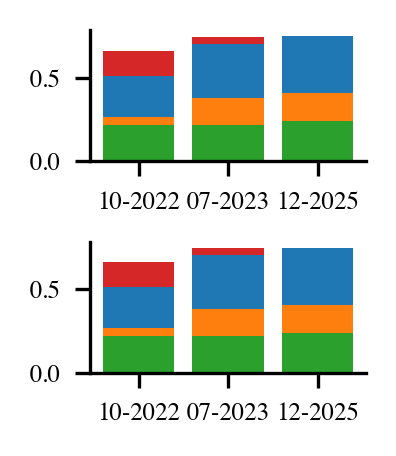

In [16]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(
        2, 1,
        figsize=(1.3, 1.5),
    )
    pop_immune_decomposition(ax[0], model_dpsi, "22", 0)
    pop_immune_decomposition(ax[0], model_dpsi, "23", 1)
    pop_immune_decomposition(ax[0], model_dpsi, "", 2)

    pop_immune_decomposition(ax[1], model_2ndinf, "22", 0)
    pop_immune_decomposition(ax[1], model_2ndinf, "23", 1)
    pop_immune_decomposition(ax[1], model_2ndinf, "", 2)

    for i in range(2):
        ax[i].set_xticks([0,1,2])
        ax[i].set_xticklabels(["10-2022", "07-2023", "12-2025"])
        #for j in range(3):
        #ax[i].set_ylim(0,1)
        #ax[i].set_xticks([])
    
    plt.tight_layout()

    plt.show()

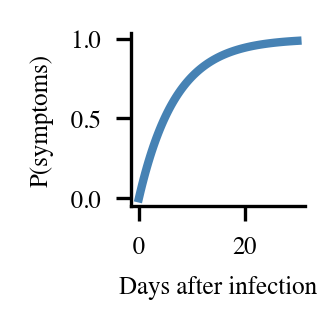

In [17]:
values = np.linspace(0, 30, 100)

incubation_rate = 1
incubation_period = 1- np.exp(-incubation_rate/7 * values)

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,1, figsize = [0.75, 0.75])

    ax.plot(values, incubation_period, color = "steelblue", label = "Model distribution", linewidth = 2)
    ax.set_xlabel("Days after infection")
    ax.set_ylabel("P(symptoms)")
    #ax.legend(loc="lower right", frameon=False)
    plt.savefig(figure_path / "incubation.svg")
    plt.show()


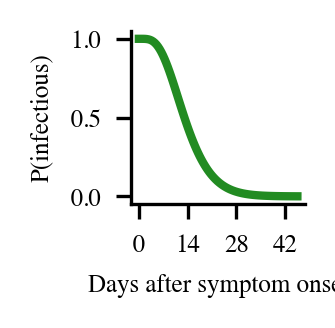

In [18]:
values = np.linspace(0, 6.5, 100)
import scipy
inf_rate = 2/5
infectious_period = 1-scipy.stats.erlang.cdf(values, 5, loc=0, scale=2/5)

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,1, figsize = [0.75, 0.75])

    ax.plot(values, infectious_period, color = "forestgreen", label = "Model distribution", linewidth = 2)
    ax.set_xlabel("Days after symptom onset")
    ax.set_ylabel("P(infectious)")
    ax.set_xticks([0, 2, 4, 6])
    ax.set_xticklabels([0, 2*7, 4*7, 6*7])
    plt.savefig(figure_path / "infectious.svg")
    #ax.legend(loc="lower right", frameon=False)

    plt.show()

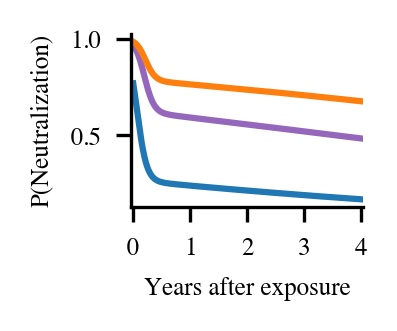

In [19]:
def ab_concentration(t, x0, f):
    delta_l = 0.0028
    delta_s = 0.23

    xs = x0 * f * np.exp(-delta_s * t)
    xl = x0 * (1-f) * np.exp(-delta_l * t)

    return(xs+xl)

def efficacy(c_t, ic50):
    return(c_t/(c_t + ic50))  

ic50 = 23.980360677686917

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1, 0.75))

    # plot 1 dose
    t = np.linspace(0,52*4,1000)
    mean = efficacy(ab_concentration(t, 80, 0.89), ic50)
    ax.plot(t,mean, label = "1-Dose")
    #lower = efficacy(ab_concentration(t, 63, 0.92), ic50)
    #upper = efficacy(ab_concentration(t, 102, 0.87), ic50)
    #ax.fill_between(t, lower, upper, alpha = 0.2)
    #print("Single dose efficacy after 2 years:", mean[-1])

    # plot 2 dose
    mean = efficacy(ab_concentration(t, 673, 0.94), ic50)
    ax.plot(t,mean, label = "2-Dose",color = "tab:purple")
    #lower = efficacy(ab_concentration(t, 537, 0.95), ic50)
    #upper = efficacy(ab_concentration(t, 854, 0.93), ic50)
    #ax.fill_between(t, lower, upper, alpha = 0.2, color = "tab:purple")
    #print("2-dose efficacy after 2 years:", mean[-1])


    # plot infection induced
    mean = efficacy(ab_concentration(t, 1500, 0.94), ic50)
    #lower = efficacy(ab_concentration(t, 1500, 0.95), ic50)
    #upper = efficacy(ab_concentration(t, 1500, 0.93), ic50)
    #ax.fill_between(t, lower, upper, alpha = 0.2)
    ax.plot(t,mean, label = "Infection")

    ax.set_xticks([0,52,2*52,3*52, 4*52], [0, 1, 2, 3, 4])
    ax.set_xlabel("Years after exposure")
    #ax.set_ylabel("Efficacy")
    ax.set_ylabel("P(Neutralization)")

    #ax.axhline(0.55, color = "black", linestyle = "dashed")

    #ax.axhline(0.22, color = "black", linestyle = "dashed")
    ax.margins(x=0.01)
    #ax.legend(frameon = False, ncol = 3)
    plt.savefig(figure_path / "vaccine_efficacies_overview.svg", bbox_inches='tight')

    plt.show()

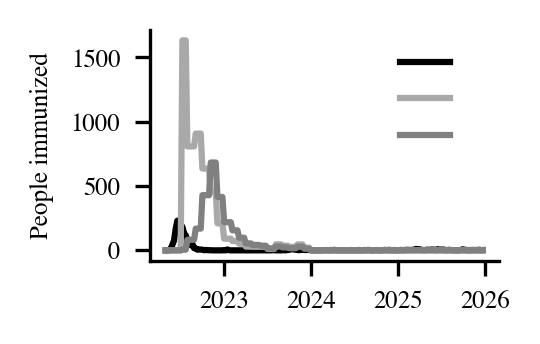

In [20]:
# immunization timeline 
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1))
    plt.plot(t_label, berlin_mpox_all["reported_cases"], color = "black", label = " ")
    plt.plot(t_label, berlin_mpox_all["first_dosis"], color = "darkgrey",label = " ")
    plt.plot(t_label, berlin_mpox_all["second_dosis"], color = "grey",label = " ")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylabel("People immunized")
    plt.legend(frameon=False)
    plt.savefig(figure_path / "immunization_timeline_overview.svg", bbox_inches='tight')
    plt.show()

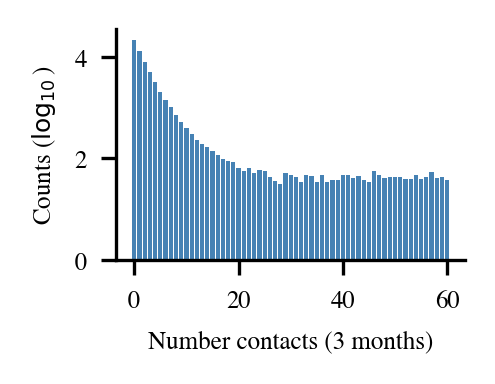

In [21]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1))
    values, unique = np.unique(degrees_real*12, return_counts=True)
    plt.bar(values, np.log10(unique), color = "steelblue")
    plt.xlabel("Number contacts (3 months)")
    plt.ylabel(r"Counts ($\log_{10}$)")
    plt.savefig(figure_path / "degree_distribution_overview.svg", bbox_inches='tight')
    plt.show()

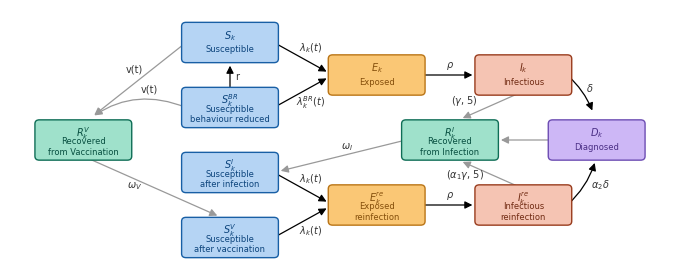

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np

fig, ax = plt.subplots(figsize=(6.9, 2.9))
ax.set_xlim(0, 9)
ax.set_ylim(0, 4)
ax.axis('off')

# ── Colours (light fills, darker edges/text matching the SVG palette) ──────────
COLORS = {
    "S": {"face": "#B5D4F4", "edge": "#185FA5", "text": "#0C447C"},
    "SBR": {"face": "#B5D4F4", "edge": "#185FA5", "text": "#0C447C"},
    "SI": {"face": "#B5D4F4", "edge": "#185FA5", "text": "#0C447C"},
    "SV": {"face": "#B5D4F4", "edge": "#185FA5", "text": "#0C447C"},
    "E": {"face": "#FAC775", "edge": "#BA7517", "text": "#854F0B"},
    "Ere": {"face": "#FAC775", "edge": "#BA7517", "text": "#854F0B"},
    "I": {"face": "#F5C4B3", "edge": "#993C1D", "text": "#712B13"},
    "Ire": {"face": "#F5C4B3", "edge": "#993C1D", "text": "#712B13"},
    "RI": {"face": "#9FE1CB", "edge": "#0F6E56", "text": "#085041"},
    "RV": {"face": "#9FE1CB", "edge": "#0F6E56", "text": "#085041"},
    "D": {"face": "#CDB7F6", "edge": "#6D4DB3", "text": "#4A2E85"},
}
LABELS = {"S": "Susceptible", "E": "Exposed", "I": "Infectious", "RI": "Recovered\nfrom Infection",
        "RV": "Recovered\nfrom Vaccination", "Ere": "Exposed\nreinfection", "Ire": "Infectious\nreinfection",
        "SBR": "Susecptible\nbehaviour reduced", "SI": "Susceptible\nafter infection", "SV": "Susceptible\nafter vaccination",
         "D": "Diagnosed" }
ARROW_KW = dict(arrowstyle="-|>", color="#555555",
                mutation_scale=14, lw=1.2,
                connectionstyle="arc3,rad=0.0")
FAINT_KW = dict(arrowstyle="-|>", color="#999999",
                mutation_scale=11, lw=0.9,
                connectionstyle="arc3,rad=0.0")

# ── Box positions {label: (centre_x, centre_y)} ───────────────────────────────
BOX_W, BOX_H = 1.2, 0.5
pos = {"S": (r"$S_k$",3, 3.5),"SBR": (r"$S^{BR}_k$", 3, 2.5), "SV": (r"$S^V_k$", 3, 0.5), "SI": (r"$S^I_k$", 3, 1.5),
       "RV": (r"$R^V_k$",1.0, 2), "RI": (r"$R^I_k$",6, 2),  "D": (r"$D_k$", 8, 2),
       "E": (r"$E_k$", 5, 3), "I": (r"$I_k$", 7, 3), 
       "Ere": (r"$E^{re}_k$", 5, 1), "Ire": (r"$I^{re}_k$",7, 1),}

def draw_box(ax, label, txt, cx, cy):
    x, y = cx - BOX_W / 2, cy - BOX_H / 2
    box = mpatches.FancyBboxPatch(
        (x, y), BOX_W, BOX_H,
        boxstyle="round,pad=0.06",
        facecolor=COLORS[label]["face"],
        edgecolor=COLORS[label]["edge"],
        linewidth=1.0, zorder=3,
    )
    ax.add_patch(box)
    ax.text(cx, cy + 0.1, txt,
            ha="center", va="center", fontsize=7, fontweight="bold",
            color=COLORS[label]["text"], zorder=4)
    ax.text(cx, cy - 0.11, LABELS[label],
            ha="center", va="center", fontsize=6, color=COLORS[label]["text"],
            zorder=4)

for lbl, (txt, cx, cy) in pos.items():
    draw_box(ax, lbl, txt, cx, cy)

# ── Helper: box edges ──────────────────────────────────────────────────────────
def left(lbl):  return pos[lbl][1] - BOX_W / 2, pos[lbl][2]
def right(lbl): return pos[lbl][1] + BOX_W / 2, pos[lbl][2]
def top(lbl):   return pos[lbl][1], pos[lbl][2] + BOX_H / 2
def bot(lbl):   return pos[lbl][1], pos[lbl][2] - BOX_H / 2

transitions = [
    (right("S"), left("E"), 0, 0, 5,"black"),
    (right("E"), left("I"), 0,0, 5,"black"),
    (bot("I"), top("RI"), 0,0, 10,"#999999"),
    (left("SBR"), top("RV"), 0.3,0, 10,"#999999"),
    (right("SBR"), left("E"), 0,0, 5,"black"),
    (bot("RV"), top("SV"), 0,0, 10,"#999999"),
    (left("RI"), right("SI"), 0,0, 5,"#999999"),
    (right("SI"), left("Ere"), 0,0, 5,"black"),
    (right("Ere"), left("Ire"), 0,0, 5,"black"),
    (right("I"), top("D"), -0.15,0, 10,"black"),
    (right("Ire"), bot("D"), 0.15,0, 5,"black"),
    (top("Ire"), bot("RI"), 0.0,0, 10,"#999999"),
    (left("S"), top("RV"), 0 ,0, 10,"#999999"),
    (top("SBR"), bot("S"), 0 ,0, 5,"black"),
    (right("SV"), left("Ere"), 0 ,0, 5,"black"),
    (left("D"), right("RI"), 0 ,0, 5,"#999999"),
]

for src, dst, rad, shrinkA, shrinkB, color in transitions:
    x0, y0 = src
    x1, y1 = dst
    arc = FancyArrowPatch(
        posA=(x0, y0), posB=(x1, y1),
        arrowstyle="-|>",
        connectionstyle="arc3,rad="+str(rad),   # negative rad = arc upward
        color=color, lw=0.9,
        mutation_scale=11, #linestyle="dashed",
        zorder=2,
        shrinkA=shrinkA,   # pull back from start
        shrinkB=shrinkB,   # pull back from end
        )
    ax.add_patch(arc)


ax.text(4.1, 3.3, r"$\lambda_k(t)$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(6, 3.05, r"$\rho$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(6, 1.05, r"$\rho$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(6.2, 2.5, r"($\gamma$, 5)", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(6.2, 1.35, r"($\alpha_1 \gamma$, 5)", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(3.1, 2.9, "r", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(4.1, 2.45, r"$\lambda^{BR}_k(t)$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(1.7, 3, "v(t)", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(1.9, 2.7, "v(t)", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(7.9, 2.7, r"$\delta$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(8.05, 1.2, r"$\alpha_2\delta$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(4.1, 1.3, r"$\lambda_k(t)$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(4.1, 0.5, r"$\lambda_k(t)$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(4.6, 1.8, r"$\omega_I$", ha="center", va="bottom", fontsize=7, color="#333333")
ax.text(1.7, 1.2, r"$\omega_V$", ha="center", va="bottom", fontsize=7, color="#333333")

#ax.text(0.9, 2.7, "Vaccination", ha="center", va="bottom", fontsize=7, color="#333333", fontweight="bold")


    
plt.tight_layout()
plt.savefig(figure_path /"compartments_raw.svg", bbox_inches="tight", dpi=300)
#plt.savefig("compartments.pdf", bbox_inches="tight")   # PDF for manuscripts
plt.show()

55


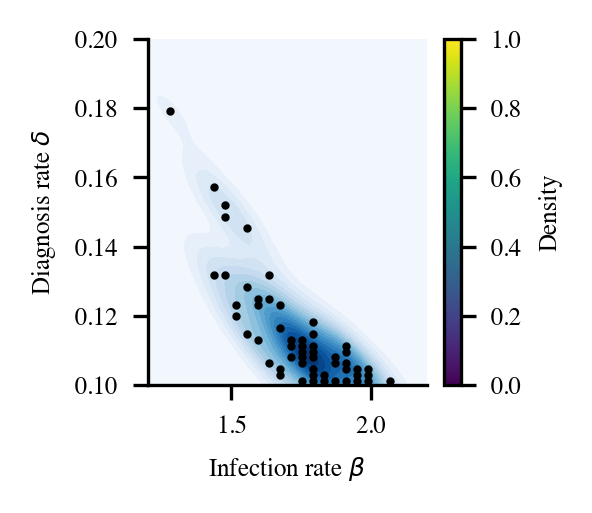

In [23]:
# abc smc 
# prior plot 
from scipy.stats import gaussian_kde

beta = np.linspace(0.1, 4.0, 100)
diag = np.linspace(5/2 * ((1- 0.18)**(-1/5) -1), 5/2 * ((1- 0.4)**(-1/5) -1), 100)
combined = [(f,s) for f in beta for s in diag]
df_tmp = pd.DataFrame(combined, columns=["beta", "diag"])
file_path = current_dir.parent / 'results/model2022/result1.csv'
results = pd.read_csv(file_path)
combined = pd.merge(df_tmp, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance'], ascending=True)
threshold = 250
threshold_cum = 750
accepted_params = combined[(combined["distance"] <threshold)&(combined["distance_cum"] <threshold_cum)][["beta", "diag"]].values
print(len(accepted_params))
data = accepted_params.T
kde = gaussian_kde(data, bw_method='scott')
x_grid = np.linspace(1.2, 2.2, 100)
y_grid = np.linspace(0.1, 0.2, 100)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])  # Positions must be a 2xN array

# Evaluate the KDE on the grid
density = kde(positions).reshape(X.shape)

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    plt.contourf(X, Y, density, levels=20, cmap='Blues')
    plt.scatter(data[0], data[1], s=1, color='black', alpha=1, label='Data points')
    plt.xlabel(r'Infection rate $\beta$')
    plt.ylabel(r'Diagnosis rate $\delta$')
    plt.colorbar(label='Density')
    #plt.legend()
    
    plt.savefig(figure_path / "abc_smc_prior.svg", bbox_inches='tight')
    plt.show()

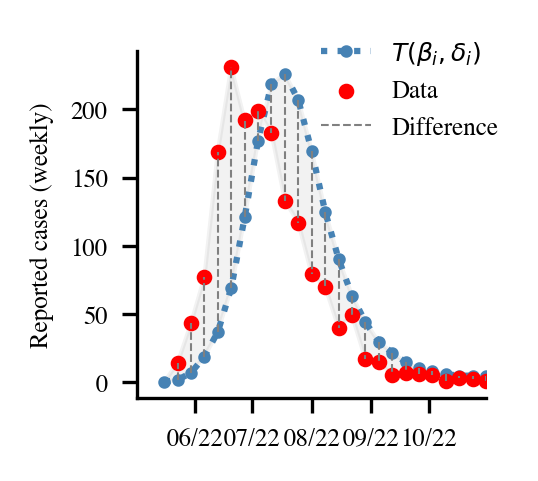

In [24]:
np.random.seed(1)
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    ax.plot(t_label[2:],model1_dict["diagnosis"].mean()[:-2],label = r"$T(\beta_i, \delta_i)$",linestyle=':',
         color='steelblue',
         marker='o',
         #markerfacecolor='black',
         #markeredgecolor='black',
        ms = 2)

    mask = berlin_mpox_all["reported_cases"]>0
    ax.scatter(berlin_mpox_all[mask]["start_date_week"], berlin_mpox_all[mask]["reported_cases"], color = "red", label = "Data", zorder = 2, s = 7.5)


    ax.vlines(t_label[2:], model1_dict["diagnosis"].mean()[:-2],berlin_mpox_all["reported_cases"][2:] , colors='gray', linestyles='dashed', linewidth=0.5, label = "Difference")
    #ax.fill_between(t_label[2:], model1_dict["diagnosis"].mean().to_numpy(dtype = float)[:-2],berlin_mpox_all["reported_cases"][2:] , color='gray', label = "Difference", alpha = 0.3, hatch='///', edgecolor='gray')
    ax.fill_between(t_label[2:], model1_dict["diagnosis"].mean().to_numpy(dtype = float)[:-2],berlin_mpox_all["reported_cases"][2:] , color='gray', alpha = 0.1,)

    ax.set_xlim(t_label[0],t_label[26])
    ax.set_ylabel("Reported cases (weekly)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))



    #ax.set_xlabel("2022")
    ax.legend(frameon=False, ncol = 1, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    plt.savefig(figure_path / "abc_smc_evaluation.svg", bbox_inches='tight')
    plt.show()

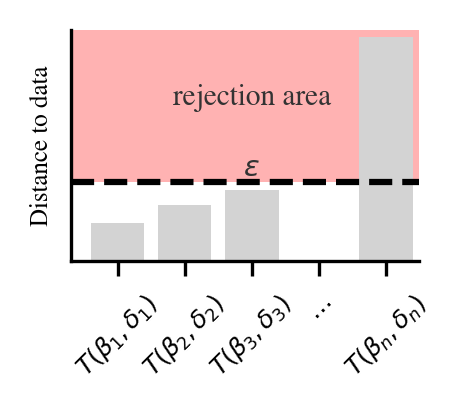

In [25]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,1,figsize=(1.5, 1))

    plt.bar(1, 1, color = "lightgrey")
    plt.bar(2, 1.5, color = "lightgrey")
    plt.bar(3, 1.9, color = "lightgrey")
    plt.bar(5, 6, color = "lightgrey")

    plt.xticks([1,2,3,4,5], [r"$T(\beta_1, \delta_1)$", r"$T(\beta_2, \delta_2)$",r"$T(\beta_3, \delta_3)$",r"$\dots$",r"$T(\beta_n, \delta_n)$"], rotation = 45)
    plt.yticks([])
    plt.ylabel("Distance to data")

    plt.axhline(2.1, linestyle="dashed", color ="black")
    ax.text(3, 2.1, r"$\varepsilon$", ha="center", va="bottom", fontsize=7, color="#333333")
    ax.text(3, 4, "rejection area", ha="center", va="bottom", fontsize=7, color="#333333")
    ax.fill_between([0.1,6], [2.1,2.1], [7,7], color = "red", alpha = 0.3, edgecolor = None, zorder = 0)
    ax.set_xlim(0.3, 5.5)
    ax.set_ylim(0.0, 6.2)
    plt.savefig(figure_path / "abc_smc_posterior.svg", bbox_inches='tight')
    plt.show()

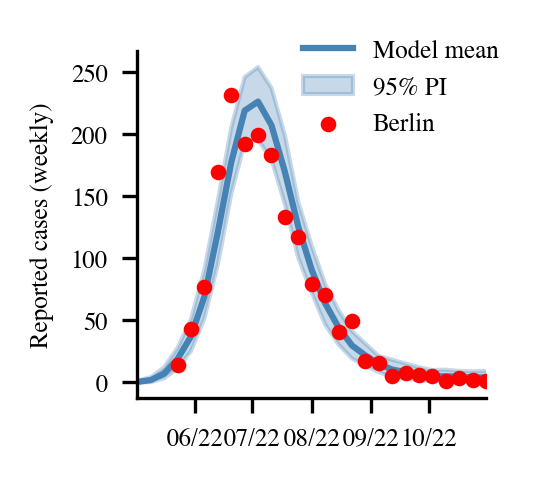

In [26]:
# calibration outputs

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    ax.plot(t_label,model1_dict["diagnosis"].mean(), color = "steelblue", label = "Model mean")

    ax.fill_between(t_label,
                    model1_dict["diagnosis"].quantile(0.025).to_numpy(dtype=float),
                    model1_dict["diagnosis"].quantile(0.975).to_numpy(dtype=float),
                    color = "steelblue",
                    alpha = 0.3,
                    label = "95% PI")

    mask = berlin_mpox_all["reported_cases"]>0
    ax.scatter(berlin_mpox_all[mask]["start_date_week"], berlin_mpox_all[mask]["reported_cases"], color = "red", label = "Berlin", zorder = 2, s = 7.5)
    ax.set_xlim(t_label[0],t_label[26])
    ax.set_ylabel("Reported cases (weekly)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))
    #ax.set_xlabel("2022")
    ax.legend(frameon=False, ncol = 1, bbox_to_anchor=(1.1, 1.1), loc = "upper right")
    plt.savefig(figure_path / "fit_to_cases.svg")
    plt.show()

1.7941 1.6663 1.8877
0.1036 0.1001 0.113


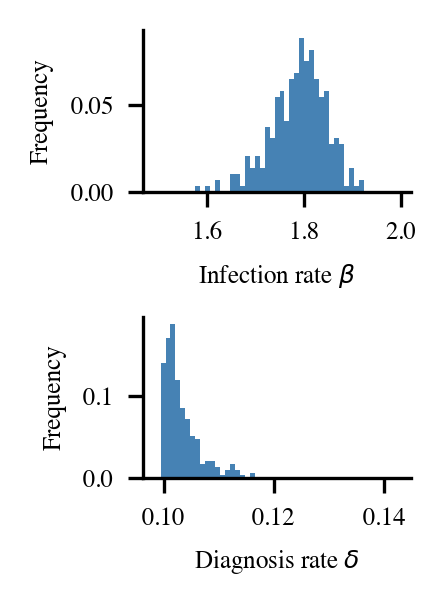

In [27]:
params = ["beta", "diag"]
bins = [np.linspace(1.5,2.0,50),np.linspace(0.099,0.143,50)]
labels = [r"Infection rate $\beta$", r"Diagnosis rate $\delta$"]

file_path = current_dir.parent / 'inputs/model2022/final_run.csv'
accepted_params = pd.read_csv(file_path)
scale_I = 2/5
#accepted_params["diag_prob"] = 1 - (1/scale_I/(accepted_params["diag"]+1/scale_I))**5
#accepted_params["infection_prob"] = accepted_params["beta"]/(accepted_params["beta"] + accepted_params["diag"])*(1 - ((1/scale_I)/(accepted_params["beta"] + accepted_params["diag"] + (1/scale_I)))**5)
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(2,1, figsize=(1.5, 2.0))
    for i in range(2):
        counts, bin = np.histogram(accepted_params[params[i]], bins = bins[i])
        ax[i].bar(bin[:-1], counts/np.sum(counts), color = "steelblue", width = bin[1] - bin[0])
        ax[i].set_xlabel(labels[i])
        ax[i].set_ylabel("Frequency")
        print(np.round(accepted_params[params[i]].mean(),4), np.round(accepted_params[params[i]].quantile(0.025),4), np.round(accepted_params[params[i]].quantile(0.975),4))
    
    plt.tight_layout()
    plt.savefig(figure_path / "posteriors_beta_gamma.svg")
    plt.show() 



In [28]:
# underreporting multiplyer calibration phase

tmp = (model_dpsi["infectionS"].iloc[:, :27].sum(axis = 1)+model_dpsi["infectionSBR"].iloc[:, :27].sum(axis = 1)+ model_dpsi["reinfection"].iloc[:, :27].sum(axis = 1) + model_dpsi["reinfectionV"].iloc[:, :27].sum(axis = 1))/model_dpsi["diagnosis"].iloc[:, :27].sum(axis = 1)
print(np.round(tmp.mean(),4))
print(np.round(tmp.quantile(0.025),4))
print(np.round(tmp.quantile(0.975),4))

5.1057
4.7749
5.3188


# Figure 3

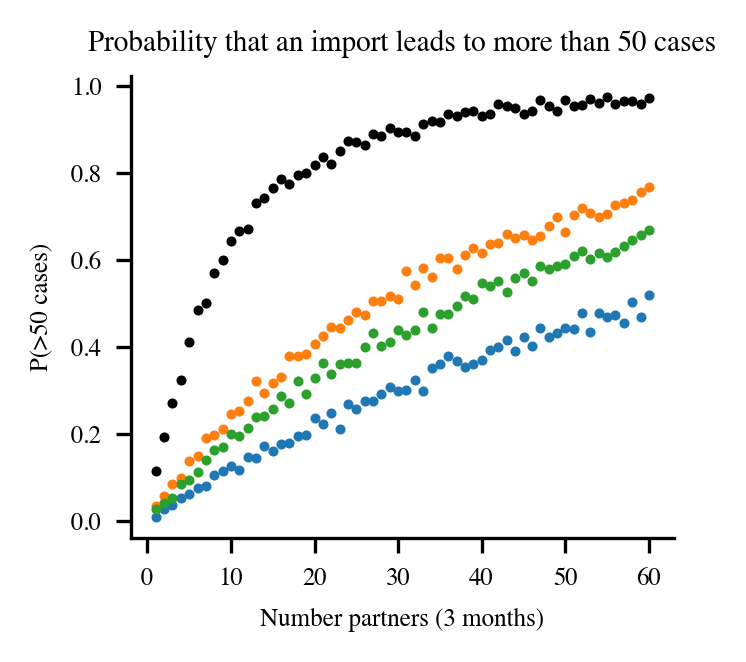

In [29]:
file_tmp = 'results/model_dpsi/final_run/'
result_files_dict =  current_dir.parent / file_tmp
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 2.0))
    file_path = os.path.join(result_files_dict, 'single_import_1.csv')
    si_1 = pd.read_csv(file_path)
    si_1["count_above_50"] = si_1.gt(50).sum(axis=1)
    plt.scatter(np.arange(1,61), si_1['count_above_50']/1000, label = "2022-05",s = 2, color = "black")
    #plt.plot(np.arange(1,61), si_1['count_above_50']/1000, label = "2022-05", linestyle = ":", marker = "o", ms = 2)

    file_path = os.path.join(result_files_dict, 'single_import_26.csv')
    si_26 = pd.read_csv(file_path)
    si_26["count_above_50"] = si_26.gt(50).sum(axis=1)
    plt.scatter(np.arange(1,61), si_26['count_above_50']/1000, label = "2022-10",s = 2)
    #plt.plot(np.arange(1,61), si_26['count_above_50']/1000, label = "2022-10", linestyle = ":", marker = "o",ms = 2)

    file_path = os.path.join(result_files_dict, 'single_import_61.csv')
    si_61 = pd.read_csv(file_path)
    si_61["count_above_50"] = si_61.gt(50).sum(axis=1)
    plt.scatter(np.arange(1,61), si_61['count_above_50']/1000, label = "2023-07",s = 2)
    #plt.plot(np.arange(1,61), si_61['count_above_50']/1000, label = "2023-07", linestyle = ":", marker = "o",ms = 2)

    file_path = os.path.join(result_files_dict, 'single_import_190.csv')
    si_190 = pd.read_csv(file_path)
    si_190["count_above_50"] = si_190.gt(50).sum(axis=1)
    plt.scatter(np.arange(1,61), si_190['count_above_50']/1000, label = "2025-12",s = 2)
    #plt.plot(np.arange(1,61), si_190['count_above_50']/1000, label = "2025-12", linestyle = ":", marker = "o",ms = 2)

    #plt.legend(frameon = False, ncol = 2)#, loc = "lower right")
    plt.xlabel("Number partners (3 months)")
    #plt.ylabel("P(import leads to >50 cases)")
    plt.ylabel("P(>50 cases)")
    plt.title("Probability that an import leads to more than 50 cases")
    plt.savefig(figure_path / "import_outbreak_prob.svg")
    plt.show()

9.0 0.49116011264133863
4.0 0.4672040291398847


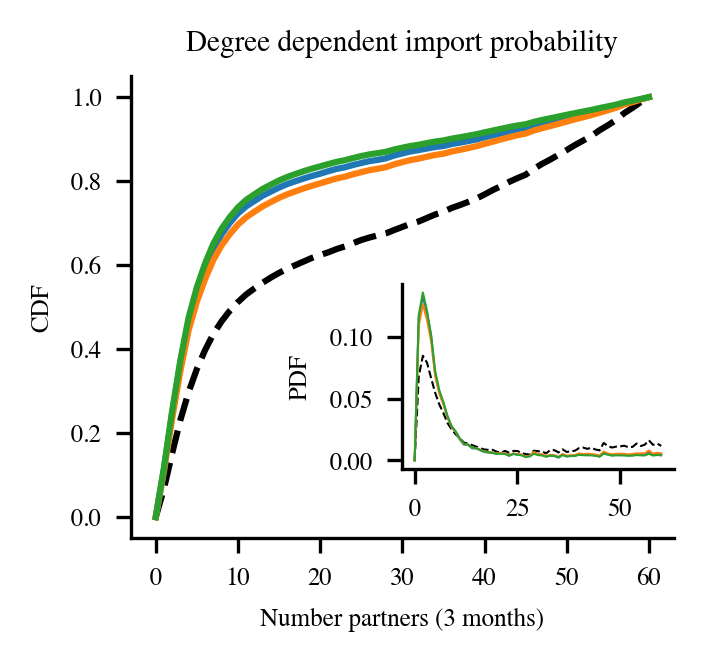

In [30]:
def import_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    df_tmp["weighted_mean"] = df_tmp["mean"] * df_tmp["k"]
    df_tmp["import_pdf"] = df_tmp["weighted_mean"]/np.sum(df_tmp["weighted_mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["weighted_lower"] = df_tmp["lower_ci"] * df_tmp["k"]
    df_tmp["import_lower"] = df_tmp["weighted_lower"]/np.sum(df_tmp["weighted_lower"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["weighted_upper"] = df_tmp["upper_ci"] * df_tmp["k"]
    df_tmp["import_upper"] = df_tmp["weighted_upper"]/np.sum(df_tmp["weighted_upper"])

    return(df_tmp[["k", "import_pdf", "import_lower", "import_upper"]])


with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 2.0))

    ax_inset = ax.inset_axes(
        [0.5, 0.15, 0.5, 0.4]
    )
    df_tmp = import_pdf('S_sum1.csv')
    plt.plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2022-05", linestyle = "dashed", color = "black")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"], linewidth = 0.5, linestyle = "dashed", color = "black")
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]))
    print(df_tmp["k"][9], np.cumsum(df_tmp["import_pdf"])[9])

    df_tmp = import_pdf('S_sum26.csv')
    plt.plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2022-10")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"],linewidth = 0.5)
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)
    print(df_tmp["k"][4], np.cumsum(df_tmp["import_pdf"])[4])

    df_tmp = import_pdf('S_sum61.csv')
    plt.plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2023-07")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"],linewidth = 0.5)
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)

    df_tmp = import_pdf('S_sum190.csv')
    plt.plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2025-12")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"], linewidth = 0.5)
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)
    #plt.legend(frameon = False, ncol = 2)#, loc = "lower right")
    plt.xlabel("Number partners (3 months)")
    #plt.ylabel("P(degree of import < k)")
    plt.ylabel("CDF")
    ax_inset.set_ylabel("PDF")
    plt.title("Degree dependent import probability")

    plt.savefig(figure_path / "import_prob.svg")

    plt.show()

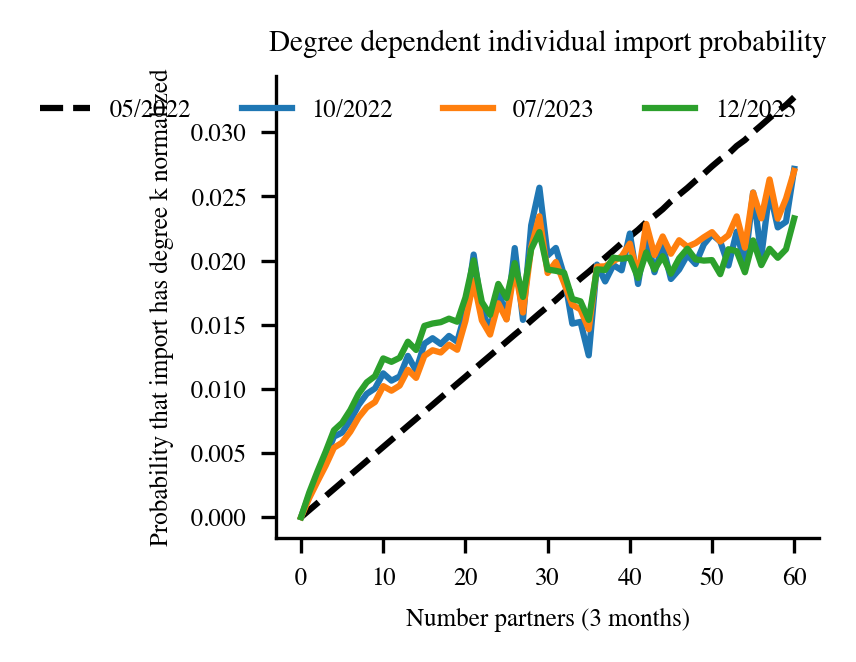

In [31]:
def import_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    df_tmp["weighted_mean"] = df_tmp["mean"] * df_tmp["k"]/P_k
    df_tmp["import_pdf"] = df_tmp["weighted_mean"]/np.sum(df_tmp["weighted_mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["weighted_lower"] = df_tmp["lower_ci"] * df_tmp["k"]
    df_tmp["import_lower"] = df_tmp["weighted_lower"]/np.sum(df_tmp["weighted_lower"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["weighted_upper"] = df_tmp["upper_ci"] * df_tmp["k"]
    df_tmp["import_upper"] = df_tmp["weighted_upper"]/np.sum(df_tmp["weighted_upper"])

    return(df_tmp[["k", "import_pdf", "import_lower", "import_upper"]])


with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 2.0))

    #ax_inset = ax.inset_axes(
    #    [0.5, 0.15, 0.5, 0.4]
    #)
    df_tmp = import_pdf('S_sum1.csv')
    plt.plot(df_tmp["k"], df_tmp["import_pdf"],label = "05/2022", color = "black", linestyle = "dashed")
    #ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"])
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]))
    df_tmp = import_pdf('S_sum26.csv')
    plt.plot(df_tmp["k"], df_tmp["import_pdf"],label = "10/2022")
    #ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"])

    df_tmp = import_pdf('S_sum61.csv')
    plt.plot(df_tmp["k"], df_tmp["import_pdf"],label = "07/2023")
    #ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"])

    df_tmp = import_pdf('S_sum190.csv')
    plt.plot(df_tmp["k"], df_tmp["import_pdf"],label = "12/2025")
    #ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"])
    
    plt.xlabel("Number partners (3 months)")
    #plt.ylabel("P(degree k person becomes import)")
    plt.ylabel("Probability that import has degree k normalized")
    #ax_inset.set_ylabel("P(degree of import)")
    plt.legend(frameon=False, ncols = 4)
    plt.title("Degree dependent individual import probability")
    plt.savefig(figure_path / "import_prob_normalized.svg", bbox_inches='tight')

    plt.show()

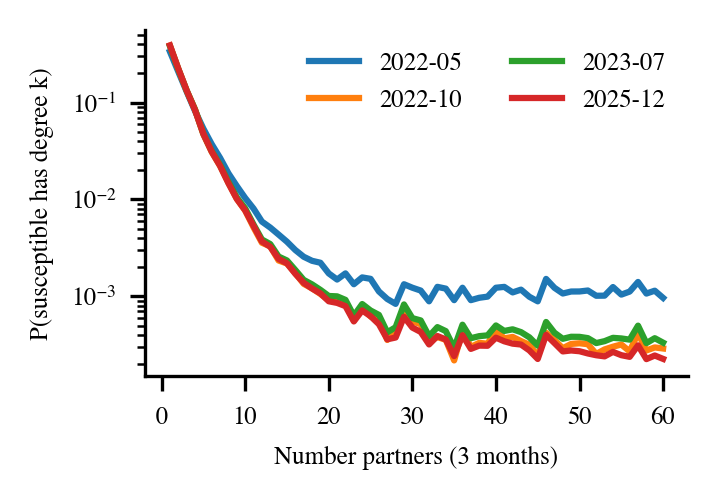

In [32]:
def S_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)
    # remove k = 0
    df_tmp = df_tmp.iloc[1:]

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    df_tmp["S_pdf"] = df_tmp["mean"]/np.sum(df_tmp["mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["S_lower"] = df_tmp["lower_ci"]/np.sum(df_tmp["lower_ci"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["S_upper"] = df_tmp["upper_ci"]/np.sum(df_tmp["upper_ci"])

    return(df_tmp[["k", "S_pdf", "S_lower", "S_upper"]])


with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 1.5))
    df_tmp = S_pdf('S_sum1.csv')
    plt.plot(df_tmp["k"], df_tmp["S_pdf"],label = "2022-05")
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]))

    df_tmp = S_pdf('S_sum26.csv')
    plt.plot(df_tmp["k"], df_tmp["S_pdf"],label = "2022-10")
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)

    df_tmp = S_pdf('S_sum61.csv')
    plt.plot(df_tmp["k"], df_tmp["S_pdf"],label = "2023-07")
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)

    df_tmp = S_pdf('S_sum190.csv')
    plt.plot(df_tmp["k"], df_tmp["S_pdf"],label = "2025-12")
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)
    plt.legend(frameon = False, ncol = 2)#, loc = "lower right")
    plt.xlabel("Number partners (3 months)")
    plt.ylabel("P(susceptible has degree k)")

    plt.yscale("log")

    plt.savefig(figure_path / "s_prob.svg")

    plt.show()

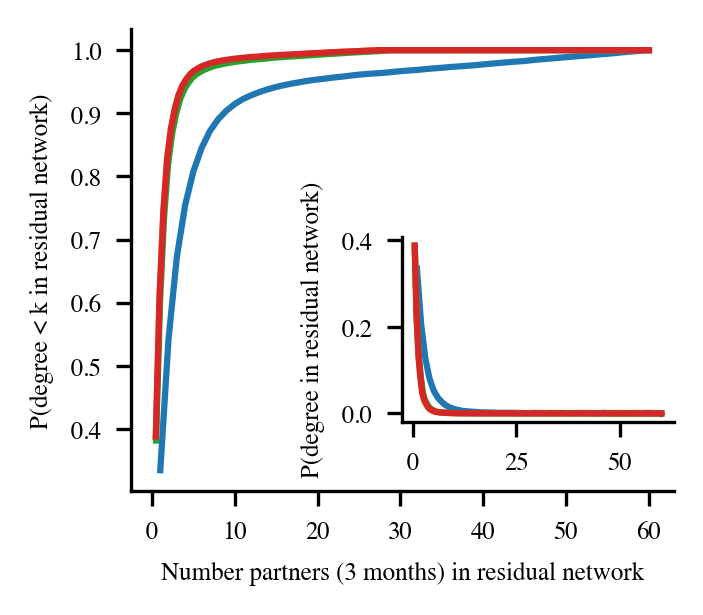

In [33]:
def residual_degree_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)
    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    s_prob = np.sum(corr * df_tmp["mean"]/P_k)
    # remove k = 0
    df_tmp = df_tmp.iloc[1:]

    df_tmp["S_pdf"] = df_tmp["mean"]/np.sum(df_tmp["mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["S_lower"] = df_tmp["lower_ci"]/np.sum(df_tmp["lower_ci"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["S_upper"] = df_tmp["upper_ci"]/np.sum(df_tmp["upper_ci"])
    df_tmp["residual_degree"] = s_prob * df_tmp["k"]

    if 60 not in df_tmp["residual_degree"].values:
        df_tmp = pd.concat([df_tmp, pd.DataFrame({"residual_degree": [60], "S_pdf": [0], "S_lower": [0], "S_upper": [0]})])

    return(df_tmp[["residual_degree", "S_pdf", "S_lower", "S_upper"]])


with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 2.0))
    ax_inset = ax.inset_axes(
        [0.5, 0.15, 0.5, 0.4]
    )
    df_tmp = residual_degree_pdf('S_sum1.csv')
    plt.plot(df_tmp["residual_degree"], np.cumsum(df_tmp["S_pdf"]),label = "2022-05")
    ax_inset.plot(df_tmp["residual_degree"], df_tmp["S_pdf"])
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]))

    df_tmp = residual_degree_pdf('S_sum26.csv')
    plt.plot(df_tmp["residual_degree"], np.cumsum(df_tmp["S_pdf"]),label = "2022-10")
    ax_inset.plot(df_tmp["residual_degree"], df_tmp["S_pdf"])
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)

    df_tmp = residual_degree_pdf('S_sum61.csv')
    plt.plot(df_tmp["residual_degree"], np.cumsum(df_tmp["S_pdf"]),label = "2023-07")
    ax_inset.plot(df_tmp["residual_degree"], df_tmp["S_pdf"])
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)

    df_tmp = residual_degree_pdf('S_sum190.csv')
    plt.plot(df_tmp["residual_degree"], np.cumsum(df_tmp["S_pdf"]),label = "2025-12")
    ax_inset.plot(df_tmp["residual_degree"], df_tmp["S_pdf"])
    #plt.fill_between(df_tmp["k"], np.cumsum(df_tmp["import_lower"]), np.cumsum(df_tmp["import_upper"]), alpha = 0.3)
    #plt.legend(frameon = False, ncol = 2)#, loc = "lower right")
    plt.xlabel("Number partners (3 months) in residual network")
    plt.ylabel("P(degree < k in residual network)")

    ax_inset.set_ylabel("P(degree in residual network)")

    #plt.yscale("log")

    plt.savefig(figure_path / "residual_degree.svg")

    plt.show()

             category      mean  cum_before
0                   S  0.389975    0.000000
1                 SBR  0.144186    0.389975
2              S2I+RI  0.219346    0.534161
3              S2V+RV  0.245163    0.753507
4  currently_infected  0.001330    0.998670


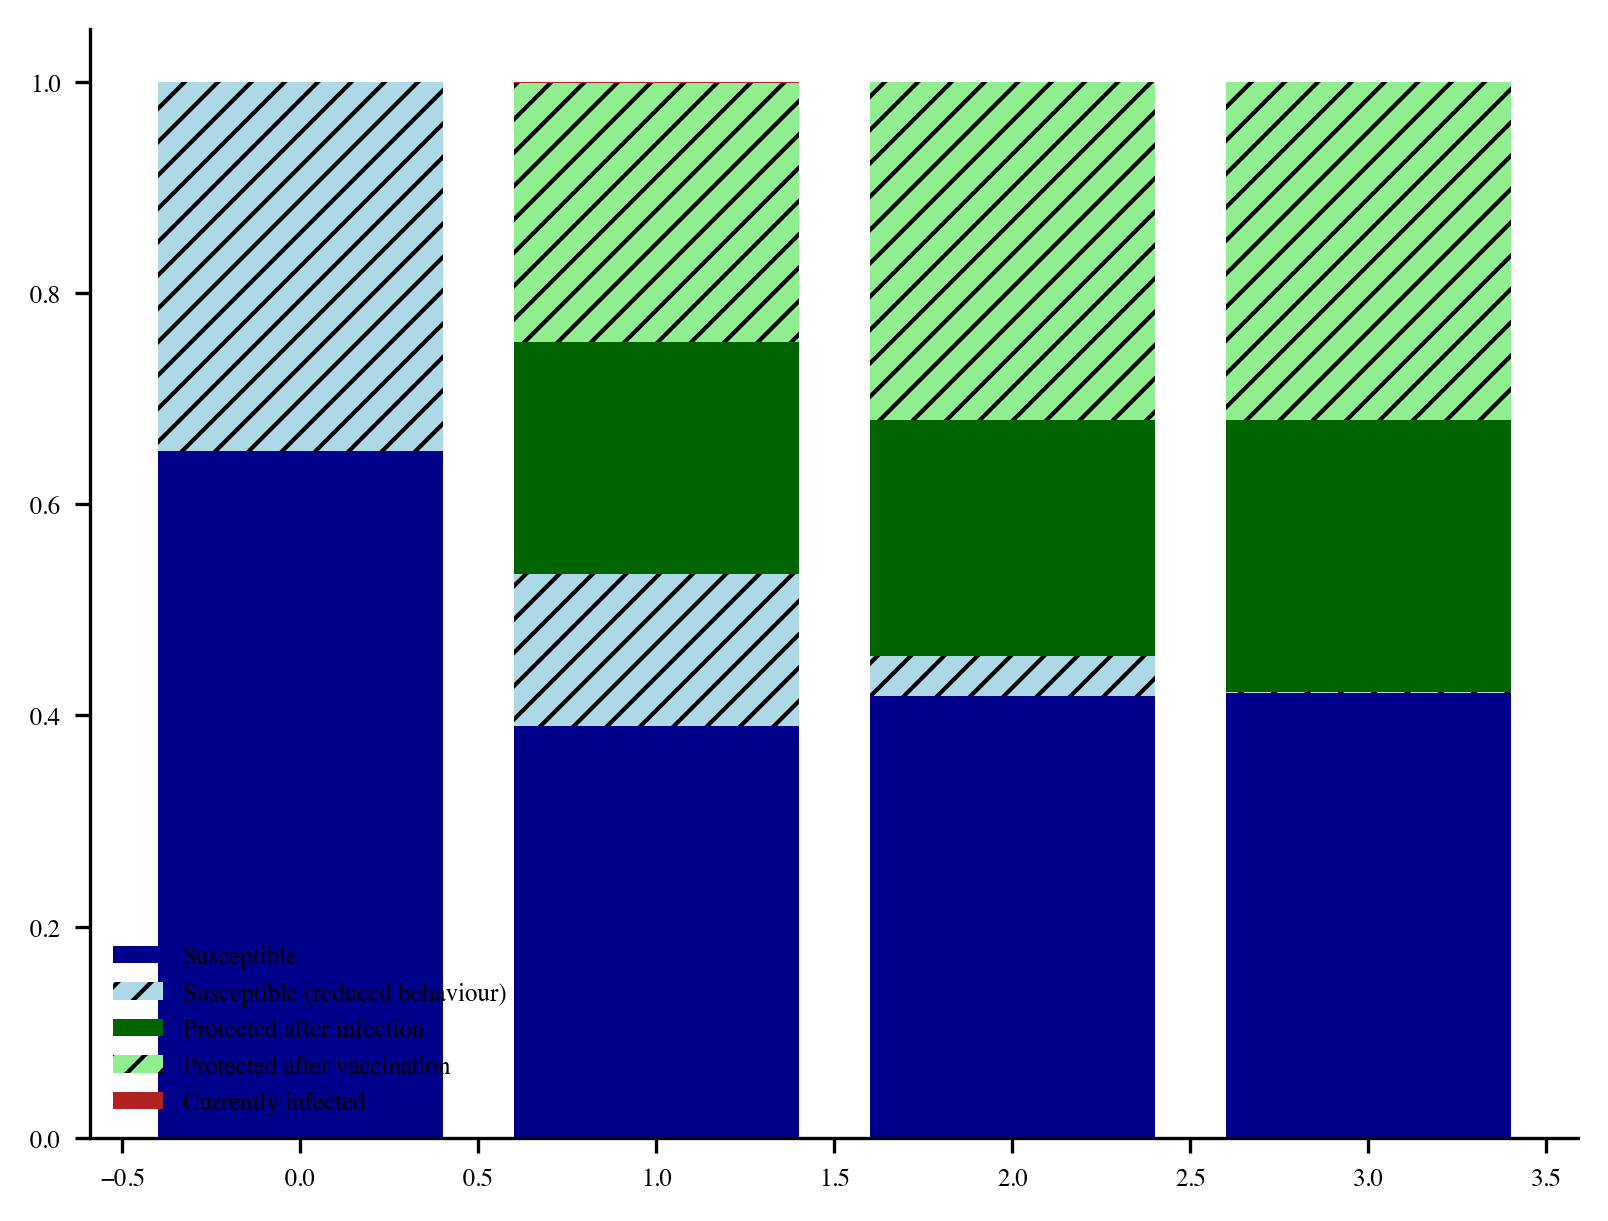

In [34]:
def pop_decomposition(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)
    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)/N
    tmp = np.zeros(len(df_tmp))
    tmp[1:] = np.cumsum(df_tmp["mean"])[:-1]
    df_tmp["cum_before"] = tmp
    return(df_tmp[["category", "mean", "cum_before"]])

def plot_pop_decomp(df_tmp, pos = 0, labels_bin = False, ax = ax):
    colors = ["darkblue", "lightblue","darkgreen", "lightgreen", "firebrick"]
    hatchs = ["", "///", "", "///", ""]
    labels = ["Susceptible", "Susceptible (reduced behaviour)", "Protected after infection", "Protected after vaccination", "Currently infected"]
    for i in range(len(df_tmp)):
        if labels_bin:
            ax.bar(pos, df_tmp.loc[i,"mean"], bottom = df_tmp.loc[i,"cum_before"], color = colors[i], hatch = hatchs[i], label = labels[i])
        else:
            ax.bar(pos, df_tmp.loc[i,"mean"], bottom = df_tmp.loc[i,"cum_before"], color = colors[i], hatch = hatchs[i])

with plt.rc_context(STYLE):  
    fig, ax = plt.subplots()
    df_tmp = pop_decomposition("pop_decomp1.csv")
    plot_pop_decomp(df_tmp, ax = ax)

    df_tmp = pop_decomposition("pop_decomp26.csv")
    print(df_tmp)
    plot_pop_decomp(df_tmp, 1, True, ax = ax)

    df_tmp = pop_decomposition("pop_decomp61.csv")
    plot_pop_decomp(df_tmp, 2, ax = ax)

    df_tmp = pop_decomposition("pop_decomp190.csv")
    plot_pop_decomp(df_tmp, 3, ax = ax)

    plt.legend(frameon = False)

    #plt.savefig(figure_path / "pop_decomp.svg")
    plt.show()


    
    


4.9251 4.8871 4.9297
3.3652 3.0214 3.7046
3.5104 3.1396 3.8628
3.3018 2.9629 3.6441


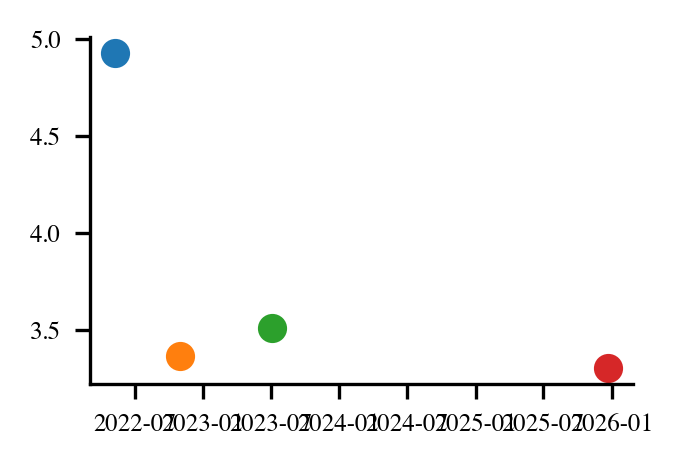

In [35]:
# average S degree over the three time points

def S_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)
    # remove k = 0
    df_tmp = df_tmp.iloc[1:]

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    mean_degree = np.sum(df_tmp["mean"]*df_tmp["k"])/np.sum(df_tmp["mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    lower = np.sum(df_tmp["lower_ci"]*df_tmp["k"])/np.sum(df_tmp["lower_ci"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    upper = np.sum(df_tmp["upper_ci"]*df_tmp["k"])/np.sum(df_tmp["upper_ci"])

    return(mean_degree, lower, upper)


with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(double_col/3, 1.5))
    mean_degree, lower, upper = S_pdf('S_sum1.csv')
    plt.scatter(t_label[1], mean_degree)
    print(np.round(mean_degree,4), np.round(lower,4), np.round(upper,4))

    mean_degree, lower, upper = S_pdf('S_sum26.csv')
    plt.scatter(t_label[26], mean_degree)
    print(np.round(mean_degree,4), np.round(lower,4), np.round(upper,4))

    mean_degree, lower, upper = S_pdf('S_sum61.csv')
    plt.scatter(t_label[61], mean_degree)
    print(np.round(mean_degree,4), np.round(lower,4), np.round(upper,4))

    mean_degree, lower, upper = S_pdf('S_sum190.csv')
    plt.scatter(t_label[190], mean_degree)
    print(np.round(mean_degree,4), np.round(lower,4), np.round(upper,4))
    
    #plt.savefig(figure_path / "s_prob.svg")

    plt.show()


4.9283 4.9261 4.9298
1.5225 1.4717 1.5901
1.7102 1.5836 1.8212
1.5217 1.3858 1.6327
             category      mean  cum_before
0                   S  0.389975    0.000000
1                 SBR  0.144186    0.389975
2              S2I+RI  0.219346    0.534161
3              S2V+RV  0.245163    0.753507
4  currently_infected  0.001330    0.998670


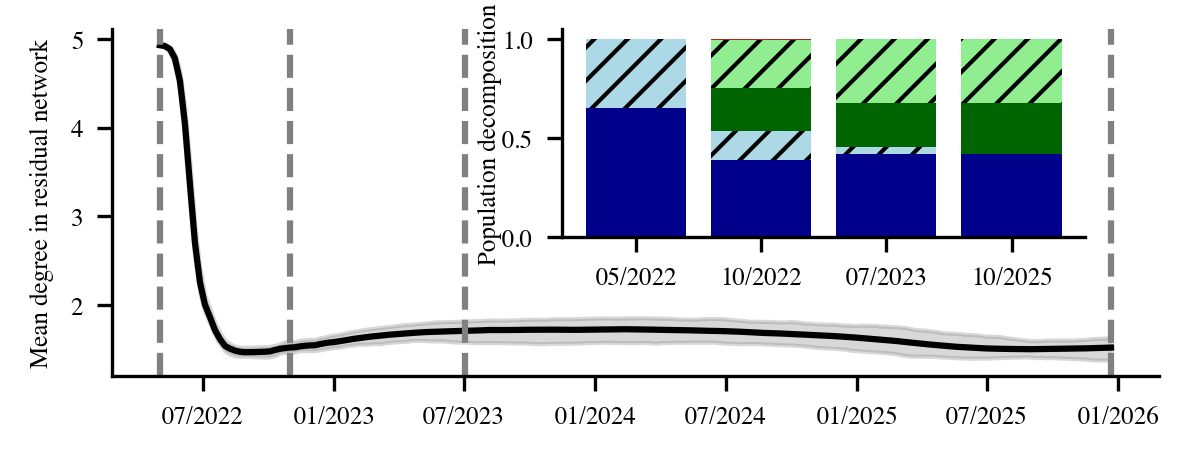

In [36]:
# residual network mean degree over time 
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(single_half_col, 1.5))
    
    file_path = os.path.join(result_files_dict, "res_residual.csv")
    df_tmp = pd.read_csv(file_path)

    plt.plot(t_label,df_tmp.iloc[:,1:].mean(axis = 1), color = "black")
    plt.fill_between(t_label,
                     df_tmp.iloc[:,1:].quantile(0.025,axis = 1).to_numpy(dtype = float),
                     df_tmp.iloc[:,1:].quantile(0.975,axis = 1).to_numpy(dtype = float),
                     color = "grey", alpha = 0.3)
    
    plt.axvline(t_label[0], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[26], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[61], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[190], color = "grey", linestyle = "dashed")

    print(np.round(df_tmp.iloc[0,1:].mean(),4), np.round(df_tmp.iloc[0,1:].quantile(0.025),4), np.round(df_tmp.iloc[0,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[26,1:].mean(),4), np.round(df_tmp.iloc[26,1:].quantile(0.025),4), np.round(df_tmp.iloc[26,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[61,1:].mean(),4), np.round(df_tmp.iloc[61,1:].quantile(0.025),4), np.round(df_tmp.iloc[61,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[190,1:].mean(),4), np.round(df_tmp.iloc[190,1:].quantile(0.025),4), np.round(df_tmp.iloc[190,1:].quantile(0.975),4))

    plt.ylabel("Mean degree in residual network")

    ax_inset = ax.inset_axes(
        [0.43, 0.4, 0.5, 0.6]
    )
    df_tmp = pop_decomposition("pop_decomp1.csv")
    plot_pop_decomp(df_tmp,0, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp26.csv")
    print(df_tmp)
    plot_pop_decomp(df_tmp, 1, True, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp61.csv")
    plot_pop_decomp(df_tmp, 2, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp190.csv")
    plot_pop_decomp(df_tmp, 3, ax = ax_inset)
    ax_inset.set_ylabel("Population decomposition", labelpad = 0.1)
    ax_inset.set_xticks([0,1,2,3],["05/2022", "10/2022", "07/2023", "10/2025"])

    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))


    plt.savefig(figure_path / "residual_network.svg")

    plt.show()


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/274360665.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inf = model_dict["infection"].replace(0, np.nan)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/274360665.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diag = model_dict["diagnosis"].replace(0, np.nan)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/274360665.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will chang

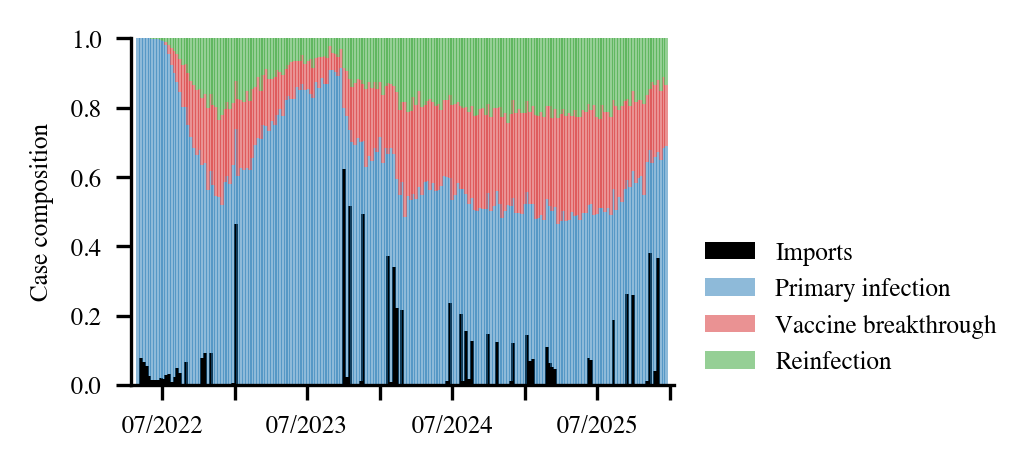

In [37]:
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,2,figsize=(double_col, 1.5))
    fig, ax_top_left = plt.subplots(
        #1, 4,
        figsize=(double_col/3, 1.5),
        #gridspec_kw={"width_ratios": [3, 1, 3, 1], "wspace": 0.25},
    )
  
    model_dict = model_dpsi
    # calculate fractions for each sim and take mean after
    inf = model_dict["infection"].replace(0, np.nan)
    diag = model_dict["diagnosis"].replace(0, np.nan)
    
    share_imports = model_dict["imports"].div(inf).fillna(0.0).mean(axis=0)
    share_imports_re = model_dict["imports_re"].div(inf).fillna(0.0).mean(axis=0)
    share_imports_rev = model_dict["imports_rev"].div(inf).fillna(0.0).mean(axis=0)
    share_re  = model_dict["reinfection"].div(inf).fillna(0.0).mean(axis = 0) - share_imports_re
    share_rev = model_dict["reinfectionV"].div(inf).fillna(0.0).mean(axis=0) - share_imports_rev


    # share first Inf
    share_1 = 1 - share_rev - share_re - share_imports

    ax_top_left.bar(t_label,share_imports, color="k", label="Imports", width = 10)
    ax_top_left.bar(t_label, share_1, bottom = share_imports, color="tab:blue", alpha=0.5, label="Primary infection", width = 10)
    ax_top_left.bar(t_label, share_rev, bottom = share_1 + share_imports, color="tab:red", alpha=0.5, label="Vaccine breakthrough", width = 10)
    ax_top_left.bar(t_label, share_re, bottom = share_1 + share_rev + share_imports, color="tab:green", alpha=0.5, label="Reinfection", width = 10)
    ax_top_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_top_left.margins(x=0.01)
    ax_top_left.set_xticklabels([])
    ax_top_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_top_left.legend(frameon=False, loc=(1.04, 0.0), ncol = 1)
    ax_top_left.set_ylabel("Case composition")
    #ax_top_left.set_yticklabels([])

    plt.savefig(figure_path / "case_decomposition.svg")
    

    plt.show()

# Fig 4

In [38]:
def jan_only_formatter(x, pos=None):
    d = mdates.num2date(x)
    return d.strftime('%m/%Y') if d.month == 7 else ''

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import re

def parse_lineage(lineage):
    """
    Parses strings like:
    B.1       -> ('B', [1])
    B.1.22    -> ('B', [1, 22])
    F.2.1     -> ('F', [2, 1])
    """
    parts = lineage.split(".")
    prefix = parts[0]
    nums = []
    for p in parts[1:]:
        try:
            nums.append(int(p))
        except ValueError:
            nums.append(0)
    return prefix, nums

def lineage_color(lineage, prefix_hues):
    prefix, nums = parse_lineage(lineage)

    # base hue from main lineage prefix
    h = prefix_hues[prefix]

    # default saturation/value
    s = 0.65
    v = 0.85

    # modify color according to numerical hierarchy
    if len(nums) >= 1:
        v = 0.55 + 0.3 * ((nums[0] % 10) / 9 if nums[0] > 0 else 0)
    if len(nums) >= 2:
        s = 0.45 + 0.4 * ((nums[1] % 10) / 9 if nums[1] > 0 else 0)
    if len(nums) >= 3:
        h = (h + 0.03 * ((nums[2] % 10) / 9)) % 1.0

    return colorsys.hsv_to_rgb(h, s, v)




5 rows were removed because of incomplete collection date.


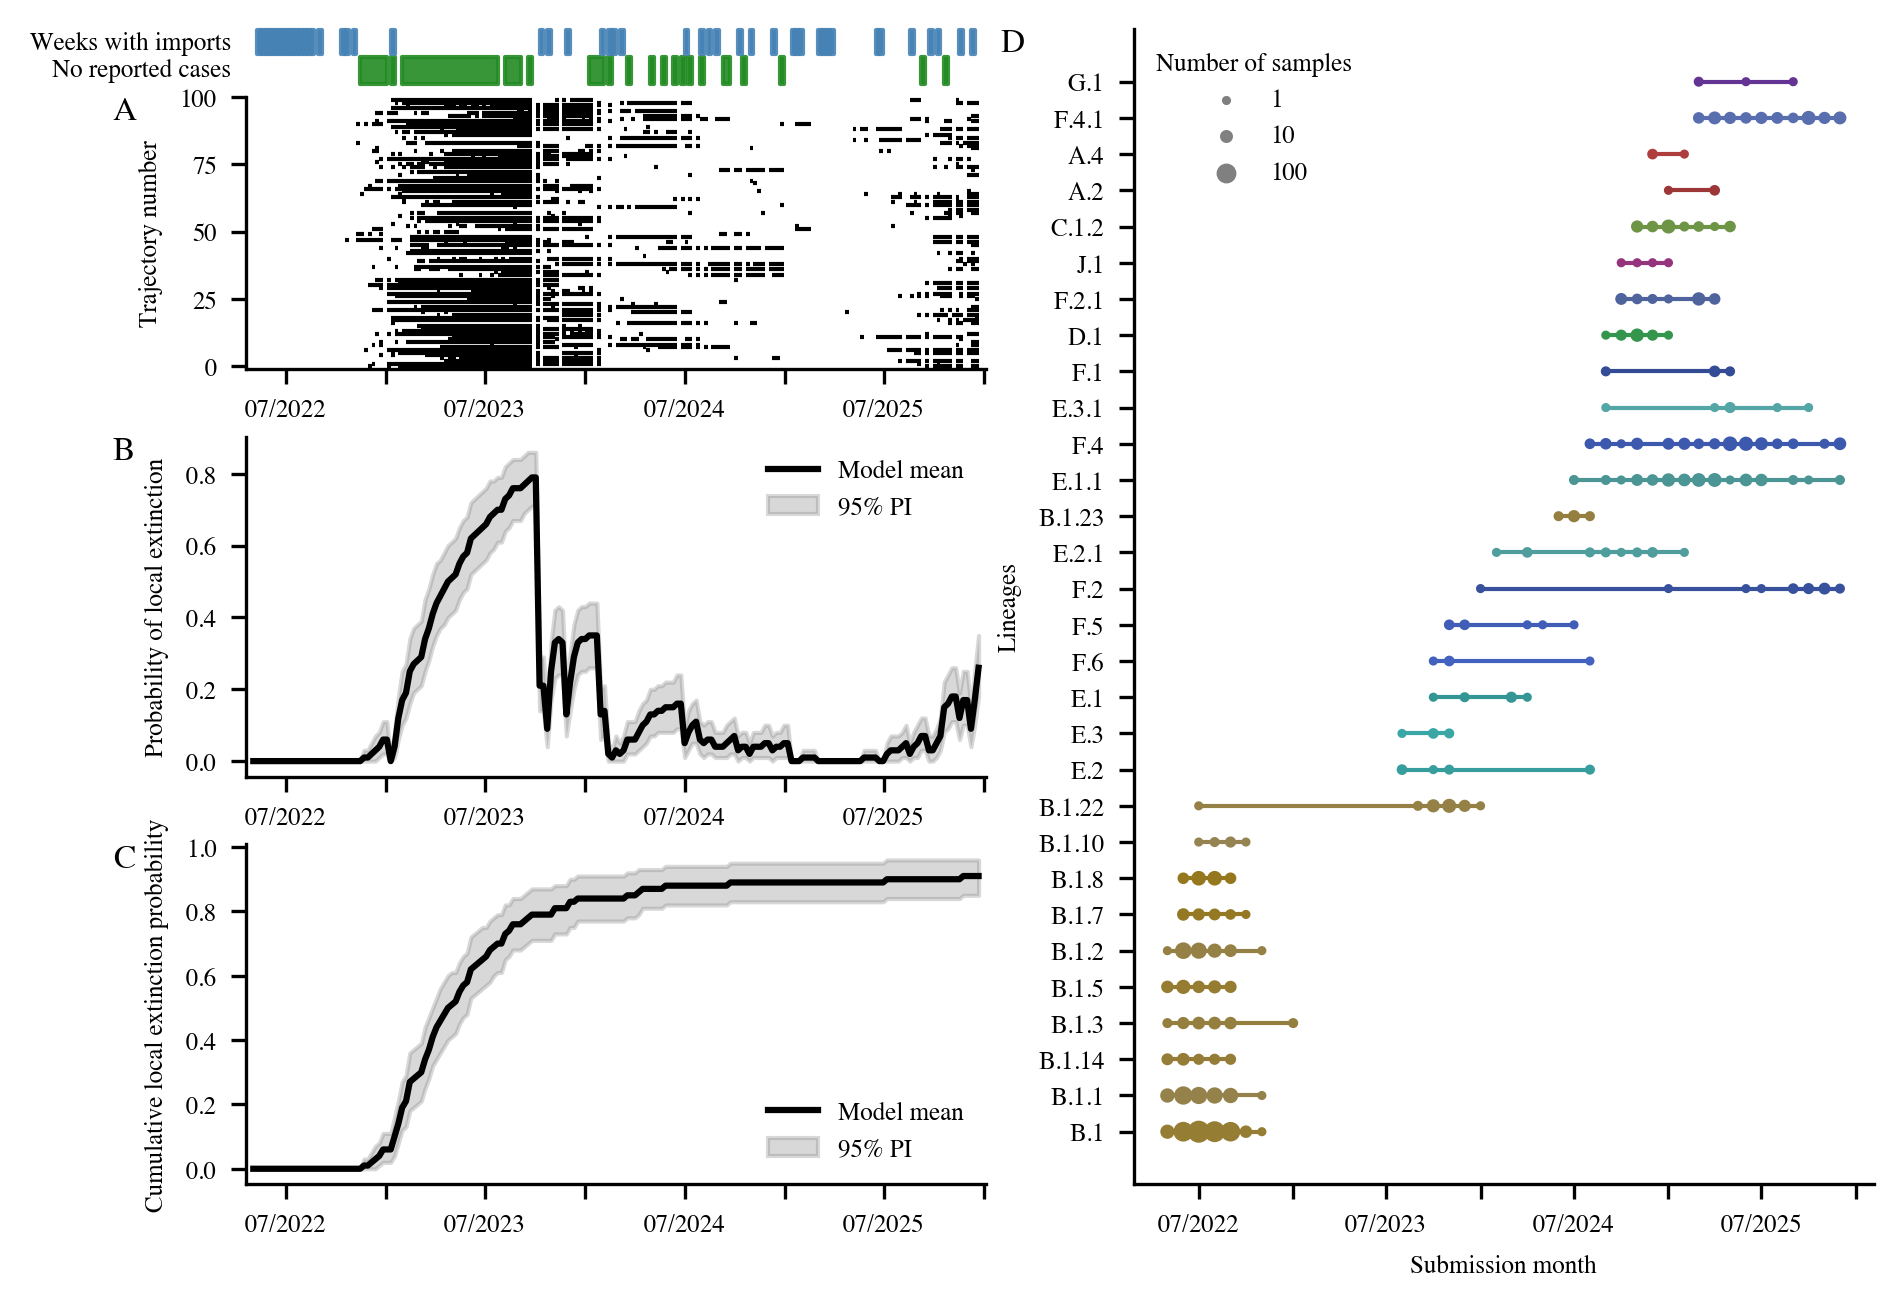

In [40]:
with plt.rc_context(STYLE):
    fig = plt.figure(
        figsize=(double_col, 5),
    )
    gs = fig.add_gridspec(nrows=3, ncols=2)

    ax_top_left  =  fig.add_subplot(gs[0, 0])
    ax_center_left  =  fig.add_subplot(gs[1, 0])
    ax_bottom_left  =  fig.add_subplot(gs[2, 0])
    ax_right = fig.add_subplot(gs[:, 1])

    model_dict = model_dpsi

    # file is currently located outside git realm
    #meta_data = pd.read_csv("/Users/nilsgubela/Desktop/Projects/Ideas/mpox_endemic/sequence_analysis/mpox_metadata_2026-01-28T1556.tsv", sep = "\t")
    file_path = os.path.join(data_path, 'mpox_metadata_2026-08-19T1509.tsv')
    meta_data = pd.read_csv(file_path, sep = "\t")
    meta_data = meta_data[["lineage", "sampleCollectionDate"]]
    meta_data["sampleCollectionDate"] = meta_data["sampleCollectionDate"].apply(lambda x: x[:7])
    meta_data["year"] = meta_data["sampleCollectionDate"].apply(lambda x: x[:4]).astype(int)
    meta_data["month"] = meta_data["sampleCollectionDate"].apply(lambda x: x[5:])
    before = len(meta_data)
    meta_data = meta_data[meta_data["month"] != ""].copy()
    removed = before - len(meta_data)
    print(f"{removed} rows were removed because of incomplete collection date.")
    meta_data["month"] = meta_data["month"].astype(int)
    meta_data["date_plot"] = pd.to_datetime(meta_data[['year', 'month']].assign(day=1))

    # plotting
    lineages = meta_data["lineage"].unique()
    cmap = plt.get_cmap('viridis', len(lineages))
    show_lineages = []
    for lineage in lineages:
        tmp_df = meta_data[meta_data["lineage"] == lineage]
        if len(tmp_df) > 3:
            show_lineages.append(lineage)

    # sort to keep related ones near each other
    #show_lineages = sorted(show_lineages)

    # assign one base hue per top-level prefix
    prefixes = sorted({x.split(".")[0] for x in show_lineages})
    prefix_hues = {p: i / max(len(prefixes), 1) for i, p in enumerate(prefixes)}

    for i,lineage in enumerate(show_lineages):
        tmp_df = meta_data[meta_data["lineage"] == lineage]
        values, counts = np.unique(tmp_df["date_plot"], return_counts=True)
        color = lineage_color(lineage, prefix_hues)
        ax_right.scatter(values, i*np.ones_like(counts), s = np.sqrt(counts*2 ), color = color)
        ax_right.plot(values, i*np.ones_like(counts), linewidth = 1, color = color)


    handles = [
        plt.scatter([], [], s=np.sqrt(1*2), color='gray', alpha=1, label='1'),
        plt.scatter([], [], s=np.sqrt(10*2), color='gray', alpha=1, label='10'),
        plt.scatter([], [], s=np.sqrt(100*2), color='gray', alpha=1, label='100'),
    ]

    ax_right.legend(handles=handles, title='Number of samples', frameon = False)

            
    ax_right.set_ylabel("Lineages")
    ax_right.set_xlabel("Submission month")
    ax_right.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_right.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_right.set_yticks(np.arange(len(show_lineages)), show_lineages)

    
    ax_center_left.plot(t_label, model_dpsi["die_out_prob"].mean(axis = 0), color = "black", label = "Model mean")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"])
    ax_center_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey", label = "95% PI")
    ax_center_left.set_ylabel("Probability of local extinction")
    ax_center_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_center_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_center_left.legend(frameon = False)
    ax_center_left.margins(x=0.01)
    ax_bottom_left.margins(x=0.01)


    ax_bottom_left.plot(t_label, model_dpsi["die_out_prob"].cummax(axis=1).astype(int).mean(axis = 0), color = "black", label = "Model mean")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"].cummax(axis=1).astype(int))
    ax_bottom_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey", label = "95% PI")
    ax_bottom_left.set_ylabel("Cumulative local extinction probability")
    ax_bottom_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_bottom_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_bottom_left.legend(frameon = False)

    df = model_dict["infection"] 
    for i in range(len(df)):
        y = i                       # unique y position for this row
        vals = df.iloc[i, :].to_numpy()
        is_zero = (vals == 0)

        # draw a small horizontal segment for each time where value is zero
        x = np.where(is_zero)[0]
        for t in x:
            ax_top_left.hlines(y, t_label[t-1], t_label[t], color="black", linewidth=1)

    ax_top_left.set_ylim(-1, len(df))
    pos = ax_top_left.get_position()
    ax_top_left.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])

    reported = berlin_mpox_all["reported_cases"].to_numpy()
    is_zero_rep = (reported == 0).astype(int)

    changes = np.diff(np.r_[0, is_zero_rep, 0])
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    # shade the zero regions
    for s, e in zip(starts, ends):
        if s > 5:
            #ax_top_left.axvspan(t_label[s], t_label[e], color="forestgreen", alpha=0.2)
            ax_top_left.fill_between([t_label[s], t_label[e]], 105, [115, 115], color="forestgreen", alpha=0.9, clip_on=False)

    # star for import
    for i in range(len(imports_t)):
        if imports_t[i] > 0:
            #ax_top_left.scatter(t_label[i], [115], marker='*', s=2, color='black', #edgecolor='black', clip_on=False)
            ax_top_left.fill_between([t_label[i],t_label[i+1]], 116, [125, 125], color="steelblue", alpha=0.9, clip_on=False)

    #ax_top_left.subplots_adjust(top=0.85)
    legend_elements = [
    Line2D([0], [0], color='black', lw=1, label='No simulated cases'),
        Patch(facecolor='forestgreen', edgecolor='forestgreen', alpha=0.9, label='No reported cases (Berlin)'),
        Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.9, label='Weeks with imports')
        ]
    
    ax_top_left.text(-0.02, 120, "Weeks with imports",
        transform=ax_top_left.get_yaxis_transform(),
        ha='right', va='center',
        clip_on=False)
    
    ax_top_left.text(-0.02, 110, "No reported cases",
        transform=ax_top_left.get_yaxis_transform(),
        ha='right', va='center',
        clip_on=False)

    #ax_top_left.legend(handles=legend_elements, frameon=False, ncol = 2)
    ax_top_left.set_ylabel("Trajectory number")
    ax_top_left.set_xlim(ax_center_left.get_xlim())
    ax_top_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_top_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))


    axes = [ax_top_left, ax_center_left, ax_bottom_left, ax_right]
    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            -0.18, 1., lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8, fontweight="bold"
        )    
    #plt.tight_layout()
    plt.savefig(figure_path / "figure4_raw.svg")
    #plt.savefig(figure_path / "Fig4.pdf")


    plt.show()


# Fig 5

In [41]:
# reporting countries

lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"])
die_out_local_df = pd.DataFrame({
    "start_date": t_label,
    "dpsi": model_dpsi["die_out_prob"].mean(axis = 0), 
    "lower_dpsi": lower_dpsi,
    "upper_dpsi": upper_dpsi,
    })

from datetime import datetime
# include case reporting country data
def first_day_of_iso_week(year, week):
    try:
        return datetime.fromisocalendar(year, week, 1)  # 1 corresponds to Monday
    except ValueError as e:
        # Handle invalid inputs, such as a week number that doesn't exist
        print(f"Error: {e}")
        return None

file_path = current_dir.parent / 'data/european/Joint ECDC-WHO Regional Office for Europe Mpox Surveillance Bulletin.csv'
europe_cases = pd.read_csv(file_path)
europe_cases["Date"] = pd.to_datetime(europe_cases["Date"], format="%Y-%m-%d")

europe_cases['year'] = europe_cases['Date'].dt.isocalendar().year
europe_cases['calendar_week'] = europe_cases['Date'].dt.isocalendar().week
europe_cases.loc[:,"start_date"] = europe_cases.apply(lambda row: first_day_of_iso_week(row['year'], row['calendar_week']), axis=1)

countries_with_cases = (
    europe_cases[europe_cases['Cases'] > 0]
    .groupby(['year', 'calendar_week', 'start_date'])['Country']
    .nunique()
    .reset_index(name='number_countries')
)

countries_with_cases = countries_with_cases[countries_with_cases["start_date"].isin(t_label)]

# synchronicity of outbreaks 
file_path = current_dir.parent / 'data/european/Joint ECDC-WHO Regional Office for Europe Mpox Surveillance Bulletin.csv'
europe_cases = pd.read_csv(file_path)
europe_cases["Date"] = pd.to_datetime(europe_cases["Date"], format="%Y-%m-%d")
countries = europe_cases["Country"].unique()

europe_cases['year'] = europe_cases['Date'].dt.isocalendar().year
europe_cases['calendar_week'] = europe_cases['Date'].dt.isocalendar().week
europe_cases.loc[:,"start_date"] = europe_cases.apply(lambda row: first_day_of_iso_week(row['year'], row['calendar_week']), axis=1)

cases_per_week_country = europe_cases.groupby(['year', 'calendar_week', 'start_date', 'Country'])['Cases'].sum().reset_index()
cases_per_week_total = cases_per_week_country.groupby(['year', 'calendar_week','start_date'])['Cases'].sum().reset_index()

# data prep WHO
world_pox = pd.read_csv(current_dir.parent / 'data/daily global cases by country as of 30 April 2026.csv')
world_pox["DATE"] = pd.to_datetime(world_pox["DATE"], format="%Y-%m-%d")

world_pox = world_pox[world_pox["DATE"] < np.max(countries_with_cases["start_date"])]

weekly_cases = (
    world_pox
    .groupby([
        "WHO_REGION",
        pd.Grouper(key="DATE", freq="W-MON")
    ])["NEW_CONF_CASES"]
    .sum()
    .reset_index()
)

plot_weekly_cases = weekly_cases.pivot(
    index="DATE",
    columns="WHO_REGION",
    values="NEW_CONF_CASES"
).fillna(0)

print(plot_weekly_cases)
# add TESSy
plot_weekly_cases = pd.merge(
    plot_weekly_cases,
    cases_per_week_total[["start_date", "Cases"]],
    left_index = True,
    right_on = "start_date"
)
print(plot_weekly_cases)

# aggregate to weekly country-level cases
weekly_country_cases = (
    world_pox
    .groupby([
        "WHO_REGION",
        "COUNTRY",
        pd.Grouper(key="DATE", freq="W-MON")
    ])["NEW_CONF_CASES"]
    .sum()
    .reset_index()
)

# keep only countries with >0 weekly cases
weekly_country_cases = weekly_country_cases[
    weekly_country_cases["NEW_CONF_CASES"] > 0
]

# count active countries per region and week
weekly_active_countries = (
    weekly_country_cases
    .groupby([
        "WHO_REGION",
        "DATE"
    ])["COUNTRY"]
    .nunique()
    .reset_index(name="N_COUNTRIES")
)

plot_df = weekly_active_countries.pivot(
    index="DATE",
    columns="WHO_REGION",
    values="N_COUNTRIES"
).fillna(0)


WHO_REGION   AFRO   AMRO  EMRO   EURO  SEARO   WPRO
DATE                                               
2022-01-10    1.0    0.0   0.0    0.0    0.0    0.0
2022-01-17    4.0    0.0   0.0    0.0    0.0    0.0
2022-01-24    1.0    0.0   0.0    0.0    0.0    0.0
2022-01-31    1.0    0.0   0.0    0.0    0.0    0.0
2022-02-07    1.0    0.0   0.0    0.0    0.0    0.0
...           ...    ...   ...    ...    ...    ...
2025-09-01  790.0  166.0   1.0    0.0   13.0  131.0
2025-09-08  674.0  187.0   0.0    0.0    0.0    3.0
2025-09-15  891.0  198.0   1.0  232.0    0.0    2.0
2025-09-22  672.0  189.0   2.0    0.0    0.0    6.0
2025-09-29  781.0    0.0   1.0    0.0    0.0    2.0

[195 rows x 6 columns]
      AFRO   AMRO  EMRO   EURO  SEARO   WPRO start_date  Cases
0      4.0    0.0   0.0    0.0    0.0    0.0 2022-03-07      1
1      2.0    0.0   0.0    0.0    0.0    0.0 2022-04-11      1
2      2.0    0.0   0.0    0.0    0.0    0.0 2022-04-18      6
3      2.0    3.0   0.0    0.0    0.0    0.0 202

In [42]:
plot_weekly_cases["AMRO_norm"] = plot_weekly_cases["AMRO"]/plot_weekly_cases["AMRO"].max()
plot_weekly_cases["Cases_norm"] = plot_weekly_cases["Cases"]/plot_weekly_cases["Cases"].max()
plot_weekly_cases["WPRO_norm"] = plot_weekly_cases["WPRO"]/plot_weekly_cases["WPRO"].max()

peak_amro = plot_weekly_cases.index[plot_weekly_cases["AMRO_norm"] == 1][0]
peak_wpro = plot_weekly_cases.index[plot_weekly_cases["WPRO_norm"] == 1][0]
peak_eu = plot_weekly_cases.index[plot_weekly_cases["Cases_norm"] == 1][0]

peak_berlin = berlin_mpox_all["reported_cases"].idxmax()

print(peak_eu, peak_amro,peak_wpro, peak_berlin)
print(berlin_mpox_all.iloc[0])
print(plot_weekly_cases.iloc[4])

plot_df = plot_df.reset_index()
plot_df = plot_df.rename(columns={"DATE": "start_date"})
print(plot_df)

13 17 75 7
start_date_week     2022-05-02
year                      2022
month                        5
CW                          18
reported_cases             0.0
first_dosis                0.0
second_dosis               0.0
imports_reported           0.0
Name: 0, dtype: object
AFRO                          2.0
AMRO                         12.0
EMRO                          0.0
EURO                          0.0
SEARO                         0.0
WPRO                          0.0
start_date    2022-05-02 00:00:00
Cases                          61
AMRO_norm                0.002408
Cases_norm               0.022493
WPRO_norm                     0.0
Name: 4, dtype: object
WHO_REGION start_date  AFRO  AMRO  EMRO  EURO  SEARO  WPRO
0          2022-01-10   1.0   0.0   0.0   0.0    0.0   0.0
1          2022-01-17   2.0   0.0   0.0   0.0    0.0   0.0
2          2022-01-24   1.0   0.0   0.0   0.0    0.0   0.0
3          2022-01-31   1.0   0.0   0.0   0.0    0.0   0.0
4          2022-02-07   1.

In [43]:
# Peak in Berlin is happening at week 7+4=11
# EU peak at week 13 (+2)
# America 17 (+6)
# Asia 75 (+64)

tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-2] = die_out_local_df.loc[2:, "start_date"].values
die_out_local_df["start_date_EU"] = tmp
tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-6] = die_out_local_df.loc[6:, "start_date"].values
die_out_local_df["start_date_AMRO"] = tmp
tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-64] = die_out_local_df.loc[64:, "start_date"].values
die_out_local_df["start_date_WPRO"] = tmp

die_out_shifted = die_out_local_df#[["start_date_shifted", "dpsi", "lower_dpsi", "upper_dpsi"]]
die_out_shifted = die_out_shifted.rename(columns={"dpsi": "extinction", "lower_dpsi": "extinction_lower", "upper_dpsi": "extinction_upper"})

def merge_extinction_prob(df, date_col, col, label):

    res_df = df.merge(
        die_out_shifted[[date_col, "extinction", "extinction_lower", "extinction_upper"]],
        left_on="start_date",
        right_on=date_col,
        how="left"
    )

    res_df["extinction"] = res_df["extinction"].fillna(1)
    res_df["extinction_lower"] = res_df["extinction_lower"].fillna(1)
    res_df["extinction_upper"] = res_df["extinction_upper"].fillna(1)

    res_df["ext_res_"+label] = res_df["extinction"] ** res_df[col]
    res_df["ext_lower_res_"+label] = res_df["extinction_lower"] ** res_df[col]
    res_df["ext_upper_res_"+label] = res_df["extinction_upper"] ** res_df[col]

    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_res_"+label] = 0
    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_lower_res_"+label] = 0
    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_upper_res_"+label] = 0

    res_df = res_df.drop(columns=["extinction", "extinction_lower", "extinction_upper"])

    return(res_df)

/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/4094017217.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res_df["extinction"] = res_df["extinction"].fillna(1)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/4094017217.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res_df["extinction"] = res_df["extinction"].fillna(1)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/4094017217.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futur

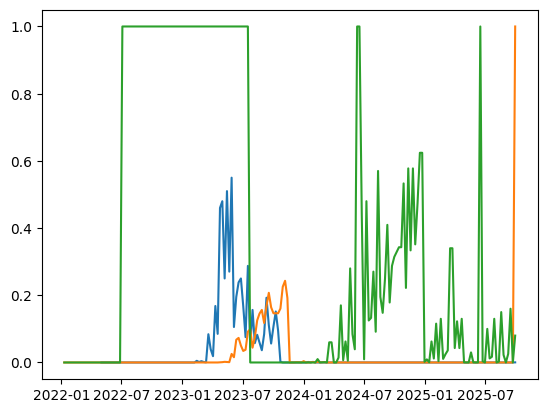

    start_date  number_countries start_date_EU    ext_res_EU  \
0   2022-05-02                 7           NaT  0.000000e+00   
1   2022-05-09                13           NaT  0.000000e+00   
2   2022-05-16                19    2022-05-16  0.000000e+00   
3   2022-05-23                21    2022-05-23  0.000000e+00   
4   2022-05-30                26    2022-05-30  0.000000e+00   
..         ...               ...           ...           ...   
174 2025-09-01                 7    2025-09-01  1.280000e-12   
175 2025-09-08                 6    2025-09-08  4.096000e-09   
176 2025-09-15                 7    2025-09-15  7.812500e-10   
177 2025-09-22                 6    2025-09-22  1.176490e-07   
178 2025-09-29                 3    2025-09-29  3.430000e-04   

     ext_lower_res_EU  ext_upper_res_EU  AMRO start_date_AMRO  ext_res_AMRO  \
0        0.000000e+00      0.000000e+00   1.0             NaT  0.000000e+00   
1        0.000000e+00      0.000000e+00   3.0             NaT  0.000000e+

In [44]:
euro_df = merge_extinction_prob(countries_with_cases[["start_date", "number_countries"]], "start_date_EU", "number_countries", "EU")
amro_df = merge_extinction_prob(plot_df[["start_date", "AMRO"]], "start_date_AMRO", "AMRO", "AMRO")
wpro_df = merge_extinction_prob(plot_df[["start_date", "WPRO"]], "start_date_WPRO", "WPRO", "WPRO")

plt.plot(euro_df["start_date"], euro_df["ext_res_EU"])
plt.plot(amro_df["start_date"], amro_df["ext_res_AMRO"])
plt.plot(wpro_df["start_date"], wpro_df["ext_res_WPRO"])
plt.show()


merged_df = euro_df.merge(
    amro_df,
    left_on="start_date",
    right_on = "start_date",
    how = "left"
)

merged_df = merged_df.merge(
    wpro_df,
    left_on="start_date",
    right_on = "start_date",
    how = "left"
)

print(merged_df)

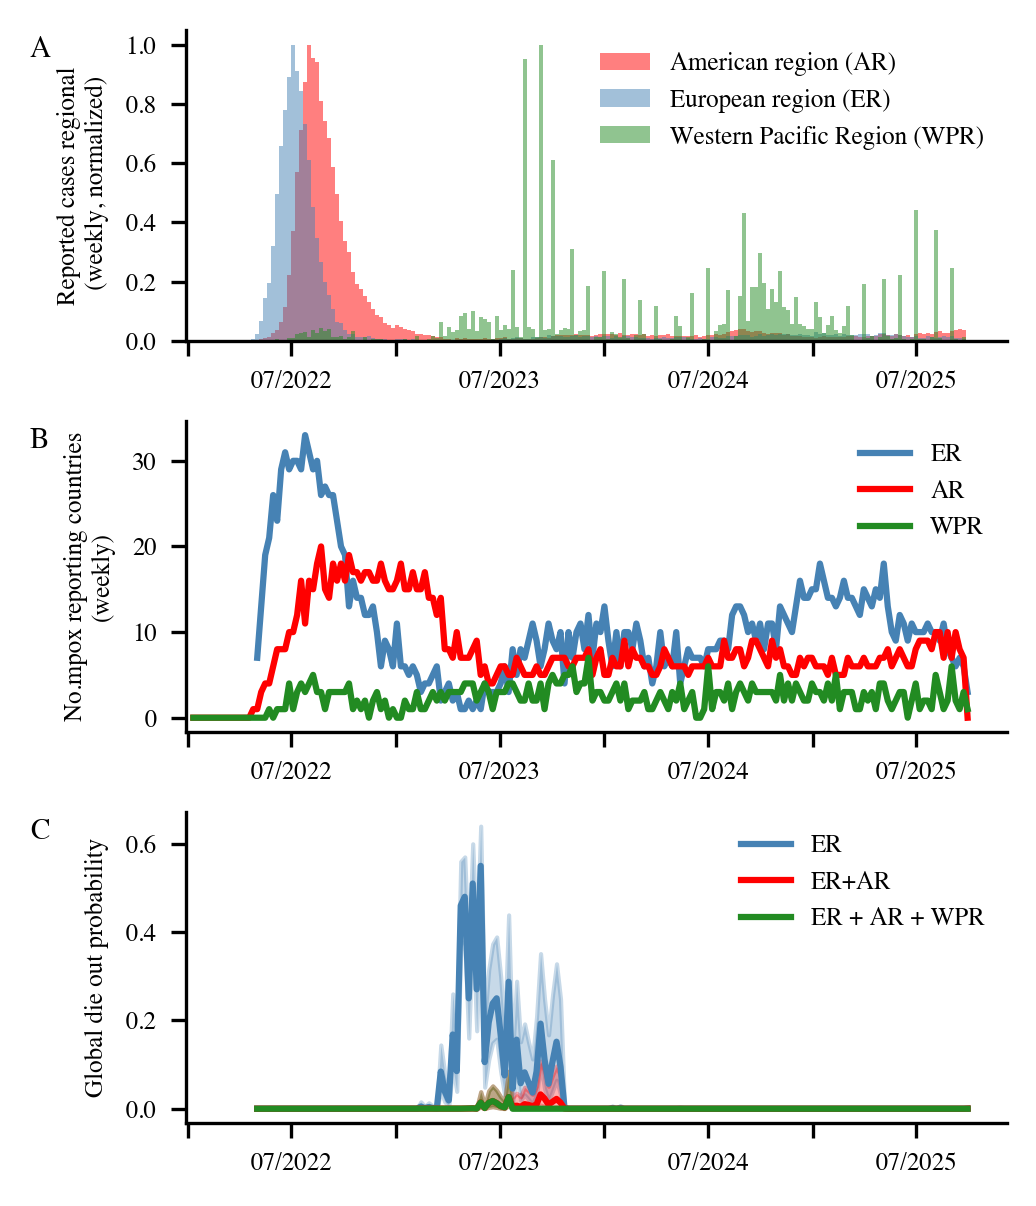

In [45]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(3,1,figsize=(single_col, 4))

    plot_weekly_cases["AMRO_norm"] = plot_weekly_cases["AMRO"]/plot_weekly_cases["AMRO"].max()
    plot_weekly_cases["Cases_norm"] = plot_weekly_cases["Cases"]/plot_weekly_cases["Cases"].max()
    plot_weekly_cases["WPRO_norm"] = plot_weekly_cases["WPRO"]/plot_weekly_cases["WPRO"].max()

    # A
    axA = ax[0]
    axA.bar(plot_weekly_cases["start_date"],plot_weekly_cases["AMRO_norm"], width = 7, label = "American region (AR)", color = "red", alpha = 0.5)
    axA.bar(plot_weekly_cases["start_date"],plot_weekly_cases["Cases_norm"], width = 7, label = "European region (ER)", color = "steelblue", alpha = 0.5)
    axA.bar(plot_weekly_cases["start_date"],plot_weekly_cases["WPRO_norm"], width = 7, color = "forestgreen", label = "Western Pacific Region (WPR)", alpha = 0.5)
    axA.set_ylabel("Reported cases regional\n (weekly, normalized)")
    axA.legend(loc=0, frameon = False)
    axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axA.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    #axA.set_yscale("log")

    # empty panel 
    #axEmpty = ax[1]
    #axEmpty.spines[['left', 'bottom']].set_visible(False)
    #axEmpty.set_yticks([])
    #axEmpty.set_xticks([])


    # B
    axB = ax[1]
    axB.plot(countries_with_cases["start_date"], countries_with_cases["number_countries"], color = "steelblue", label = "ER")#/len(countries))
    axB.plot(plot_df["start_date"], plot_df["AMRO"], label = "AR", color = "red")
    axB.plot(plot_df["start_date"], plot_df["WPRO"], label = "WPR", color = "forestgreen")
    axB.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axB.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    axB.set_ylabel("No.mpox reporting countries\n(weekly)")
    axB.legend(frameon=False)
    axB.set_xlim(axA.get_xlim())

    # C
    axC = ax[2]
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"], label = "ER", color = "steelblue")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"],merged_df["ext_upper_res_EU"], alpha = 0.3, color = "steelblue")
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"] * merged_df["ext_res_AMRO"], label = "ER+AR", color = "red")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"] * merged_df["ext_lower_res_AMRO"],merged_df["ext_upper_res_EU"]*merged_df["ext_upper_res_AMRO"], alpha = 0.3, color = "red")
    #axC.plot(merged_df["start_date"], merged_df["ext_euro"] * merged_df["ext_asia"], label = "Europe + WP")
    #axC.fill_between(merged_df["start_date"], merged_df["ext_euro_lower"] * merged_df["ext_asia_lower"],merged_df["ext_euro_upper"]*merged_df["ext_asia_upper"], alpha = 0.3)
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"] * merged_df["ext_res_AMRO"]* merged_df["ext_res_WPRO"], label = "ER + AR + WPR", color = "forestgreen")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"] * merged_df["ext_lower_res_AMRO"]* merged_df["ext_lower_res_WPRO"],merged_df["ext_upper_res_EU"] * merged_df["ext_upper_res_AMRO"]* merged_df["ext_upper_res_WPRO"], alpha = 0.3, color = "forestgreen")
    axC.set_ylabel("Global die out probability")
    axC.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axC.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    #axC.set_ylabel("Probability of no active infections")
    axC.legend(frameon=False)
    axC.set_xlim(axA.get_xlim())
    axC.set_yticks([0, 0.2, 0.4, 0.6])

    axes = [axA,axB,axC]
    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            -0.19, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=7, fontweight="bold"
            # optionally: bbox=dict(facecolor="white", edgecolor="none", pad=1)
        )    
    plt.tight_layout()
    plt.savefig(figure_path / "figure5_raw.svg")
    plt.savefig(figure_path / "Fig5.pdf")

    plt.show()

# Supplementary Figs (M2)

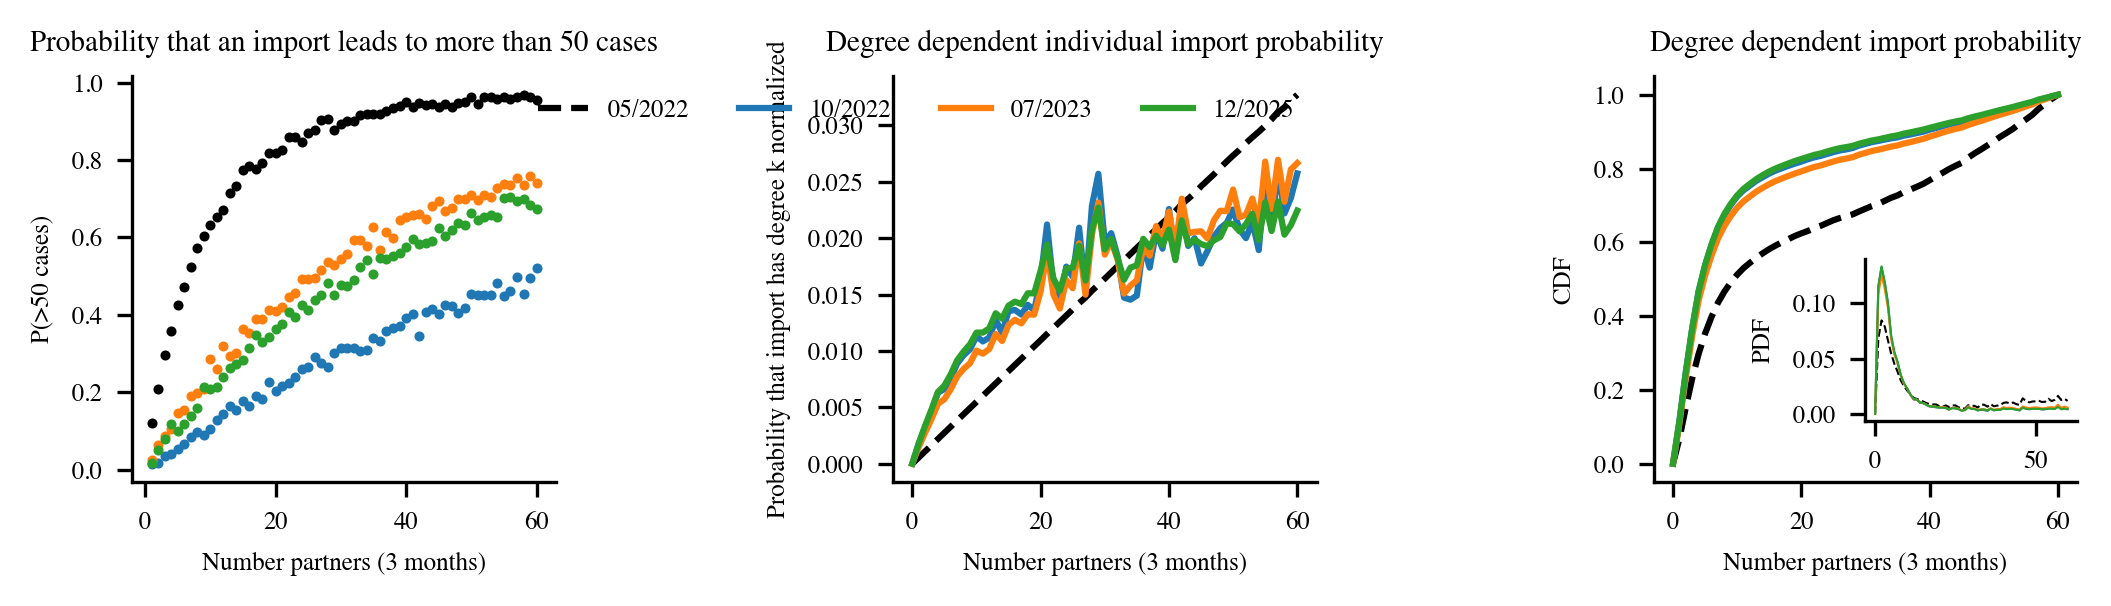

In [46]:
file_tmp = 'results/model_2ndinf/final_run/'
result_files_dict =  current_dir.parent / file_tmp
def import_pdf(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    df_tmp["weighted_mean"] = df_tmp["mean"] * df_tmp["k"]
    df_tmp["import_pdf"] = df_tmp["weighted_mean"]/np.sum(df_tmp["weighted_mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["weighted_lower"] = df_tmp["lower_ci"] * df_tmp["k"]
    df_tmp["import_lower"] = df_tmp["weighted_lower"]/np.sum(df_tmp["weighted_lower"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["weighted_upper"] = df_tmp["upper_ci"] * df_tmp["k"]
    df_tmp["import_upper"] = df_tmp["weighted_upper"]/np.sum(df_tmp["weighted_upper"])

    return(df_tmp[["k", "import_pdf", "import_lower", "import_upper"]])

def import_pdf2(file_name):
    file_path = os.path.join(result_files_dict, file_name)
    df_tmp = pd.read_csv(file_path)

    df_tmp["mean"] = df_tmp.iloc[:,1:].mean(axis = 1)
    df_tmp["weighted_mean"] = df_tmp["mean"] * df_tmp["k"]/P_k
    df_tmp["import_pdf"] = df_tmp["weighted_mean"]/np.sum(df_tmp["weighted_mean"])

    df_tmp["lower_ci"] = df_tmp.iloc[:,1:].quantile(0.025, axis = 1)
    df_tmp["weighted_lower"] = df_tmp["lower_ci"] * df_tmp["k"]
    df_tmp["import_lower"] = df_tmp["weighted_lower"]/np.sum(df_tmp["weighted_lower"])

    df_tmp["upper_ci"] = df_tmp.iloc[:,1:].quantile(0.975, axis = 1)
    df_tmp["weighted_upper"] = df_tmp["upper_ci"] * df_tmp["k"]
    df_tmp["import_upper"] = df_tmp["weighted_upper"]/np.sum(df_tmp["weighted_upper"])

    return(df_tmp[["k", "import_pdf", "import_lower", "import_upper"]])




with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,3,figsize=(double_col, 2.0))

    file_path = os.path.join(result_files_dict, 'single_import_1.csv')
    si_1 = pd.read_csv(file_path)
    si_1["count_above_50"] = si_1.gt(50).sum(axis=1)
    ax[0].scatter(np.arange(1,61), si_1['count_above_50']/1000, label = "2022-05",s = 2, color = "black")
 
    file_path = os.path.join(result_files_dict, 'single_import_26.csv')
    si_26 = pd.read_csv(file_path)
    si_26["count_above_50"] = si_26.gt(50).sum(axis=1)
    ax[0].scatter(np.arange(1,61), si_26['count_above_50']/1000, label = "2022-10",s = 2)

    file_path = os.path.join(result_files_dict, 'single_import_61.csv')
    si_61 = pd.read_csv(file_path)
    si_61["count_above_50"] = si_61.gt(50).sum(axis=1)
    ax[0].scatter(np.arange(1,61), si_61['count_above_50']/1000, label = "2023-07",s = 2)

    file_path = os.path.join(result_files_dict, 'single_import_190.csv')
    si_190 = pd.read_csv(file_path)
    si_190["count_above_50"] = si_190.gt(50).sum(axis=1)
    ax[0].scatter(np.arange(1,61), si_190['count_above_50']/1000, label = "2025-12",s = 2)

    ax[0].set_xlabel("Number partners (3 months)")
    ax[0].set_ylabel("P(>50 cases)")
    ax[0].set_title("Probability that an import leads to more than 50 cases")



    ax_inset = ax[2].inset_axes(
        [0.5, 0.15, 0.5, 0.4]
    )
    df_tmp = import_pdf('S_sum1.csv')
    ax[2].plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2022-05", linestyle = "dashed", color = "black")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"], linewidth = 0.5, linestyle = "dashed", color = "black")

    df_tmp = import_pdf('S_sum26.csv')
    ax[2].plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2022-10")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"],linewidth = 0.5)

    df_tmp = import_pdf('S_sum61.csv')
    ax[2].plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2023-07")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"],linewidth = 0.5)

    df_tmp = import_pdf('S_sum190.csv')
    ax[2].plot(df_tmp["k"], np.cumsum(df_tmp["import_pdf"]),label = "2025-12")
    ax_inset.plot(df_tmp["k"], df_tmp["import_pdf"], linewidth = 0.5)
    ax[2].set_xlabel("Number partners (3 months)")
    ax[2].set_ylabel("CDF")
    ax_inset.set_ylabel("PDF")
    ax[2].set_title("Degree dependent import probability")


    df_tmp = import_pdf2('S_sum1.csv')
    ax[1].plot(df_tmp["k"], df_tmp["import_pdf"],label = "05/2022", color = "black", linestyle = "dashed")
    df_tmp = import_pdf2('S_sum26.csv')
    ax[1].plot(df_tmp["k"], df_tmp["import_pdf"],label = "10/2022")

    df_tmp = import_pdf2('S_sum61.csv')
    ax[1].plot(df_tmp["k"], df_tmp["import_pdf"],label = "07/2023")

    df_tmp = import_pdf2('S_sum190.csv')
    ax[1].plot(df_tmp["k"], df_tmp["import_pdf"],label = "12/2025")
        
    ax[1].set_xlabel("Number partners (3 months)")
    ax[1].set_ylabel("Probability that import has degree k normalized")
    ax[1].legend(frameon=False, ncols = 4)
    ax[1].set_title("Degree dependent individual import probability")
    plt.tight_layout()
    plt.savefig(figure_path / "import_prob_normalized_suppl.svg", bbox_inches='tight')

    plt.show()

4.9279 4.9252 4.9297
1.5199 1.4598 1.582
1.73 1.6411 1.8071
1.5855 1.436 1.7193
             category      mean  cum_before
0                   S  0.390910    0.000000
1                 SBR  0.144236    0.390910
2              S2I+RI  0.218375    0.535147
3              S2V+RV  0.245145    0.753522
4  currently_infected  0.001334    0.998666


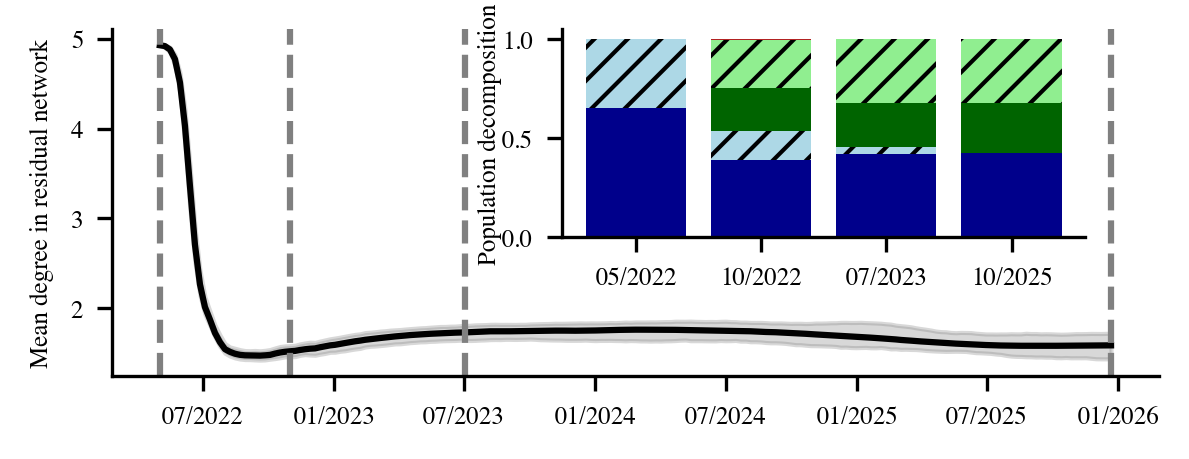

In [47]:
# residual network mean degree over time 
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(single_half_col, 1.5))
    
    file_path = os.path.join(result_files_dict, "res_residual.csv")
    df_tmp = pd.read_csv(file_path)

    plt.plot(t_label,df_tmp.iloc[:,1:].mean(axis = 1), color = "black")
    plt.fill_between(t_label,
                     df_tmp.iloc[:,1:].quantile(0.025,axis = 1).to_numpy(dtype = float),
                     df_tmp.iloc[:,1:].quantile(0.975,axis = 1).to_numpy(dtype = float),
                     color = "grey", alpha = 0.3)
    
    plt.axvline(t_label[0], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[26], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[61], color = "grey", linestyle = "dashed")
    plt.axvline(t_label[190], color = "grey", linestyle = "dashed")

    print(np.round(df_tmp.iloc[0,1:].mean(),4), np.round(df_tmp.iloc[0,1:].quantile(0.025),4), np.round(df_tmp.iloc[0,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[26,1:].mean(),4), np.round(df_tmp.iloc[26,1:].quantile(0.025),4), np.round(df_tmp.iloc[26,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[61,1:].mean(),4), np.round(df_tmp.iloc[61,1:].quantile(0.025),4), np.round(df_tmp.iloc[61,1:].quantile(0.975),4))
    print(np.round(df_tmp.iloc[190,1:].mean(),4), np.round(df_tmp.iloc[190,1:].quantile(0.025),4), np.round(df_tmp.iloc[190,1:].quantile(0.975),4))

    plt.ylabel("Mean degree in residual network")

    ax_inset = ax.inset_axes(
        [0.43, 0.4, 0.5, 0.6]
    )
    df_tmp = pop_decomposition("pop_decomp1.csv")
    plot_pop_decomp(df_tmp,0, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp26.csv")
    print(df_tmp)
    plot_pop_decomp(df_tmp, 1, True, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp61.csv")
    plot_pop_decomp(df_tmp, 2, ax = ax_inset)

    df_tmp = pop_decomposition("pop_decomp190.csv")
    plot_pop_decomp(df_tmp, 3, ax = ax_inset)
    ax_inset.set_ylabel("Population decomposition", labelpad = 0.1)
    ax_inset.set_xticks([0,1,2,3],["05/2022", "10/2022", "07/2023", "10/2025"])

    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))


    plt.savefig(figure_path / "residual_network_suppl.svg")

    plt.show()


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/1242242755.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inf = model_dict["infection"].replace(0, np.nan)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/1242242755.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diag = model_dict["diagnosis"].replace(0, np.nan)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/1242242755.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will ch

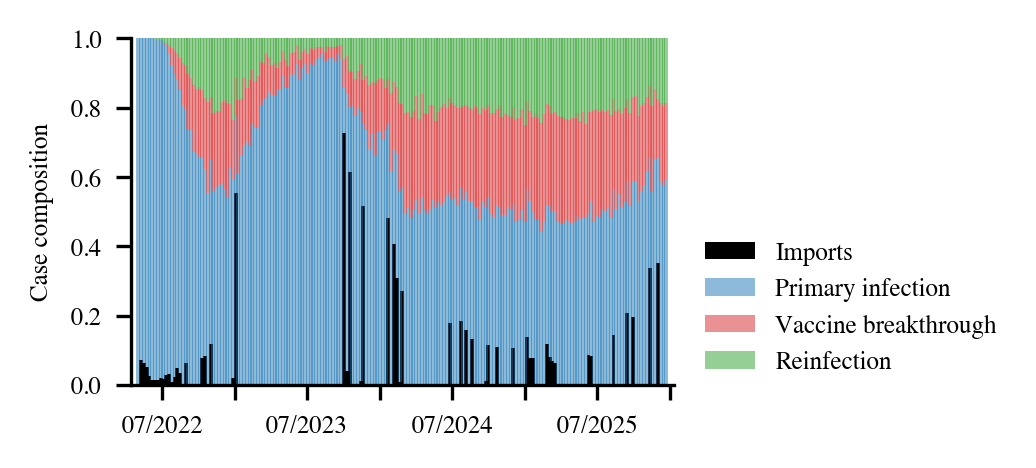

In [48]:
with plt.rc_context(STYLE):
    #fig, ax = plt.subplots(1,2,figsize=(double_col, 1.5))
    fig, ax_top_left = plt.subplots(
        #1, 4,
        figsize=(double_col/3, 1.5),
        #gridspec_kw={"width_ratios": [3, 1, 3, 1], "wspace": 0.25},
    )
  
    model_dict = model_2ndinf

    # calculate fractions for each sim and take mean after
    inf = model_dict["infection"].replace(0, np.nan)
    diag = model_dict["diagnosis"].replace(0, np.nan)
    
    share_imports = model_dict["imports"].div(inf).fillna(0.0).mean(axis=0)
    share_imports_re = model_dict["imports_re"].div(inf).fillna(0.0).mean(axis=0)
    share_imports_rev = model_dict["imports_rev"].div(inf).fillna(0.0).mean(axis=0)
    share_re  = model_dict["reinfection"].div(inf).fillna(0.0).mean(axis = 0) - share_imports_re
    share_rev = model_dict["reinfectionV"].div(inf).fillna(0.0).mean(axis=0) - share_imports_rev


    # share first Inf
    share_1 = 1 - share_rev - share_re - share_imports

    ax_top_left.bar(t_label,share_imports, color="k", label="Imports", width = 10)
    ax_top_left.bar(t_label, share_1, bottom = share_imports, color="tab:blue", alpha=0.5, label="Primary infection", width = 10)
    ax_top_left.bar(t_label, share_rev, bottom = share_1 + share_imports, color="tab:red", alpha=0.5, label="Vaccine breakthrough", width = 10)
    ax_top_left.bar(t_label, share_re, bottom = share_1 + share_rev + share_imports, color="tab:green", alpha=0.5, label="Reinfection", width = 10)
    ax_top_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_top_left.margins(x=0.01)
    ax_top_left.set_xticklabels([])
    ax_top_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_top_left.legend(frameon=False, loc=(1.04, 0.0), ncol = 1)
    ax_top_left.set_ylabel("Case composition")

    plt.savefig(figure_path / "case_decomposition_suppl.svg")
    
    plt.show()

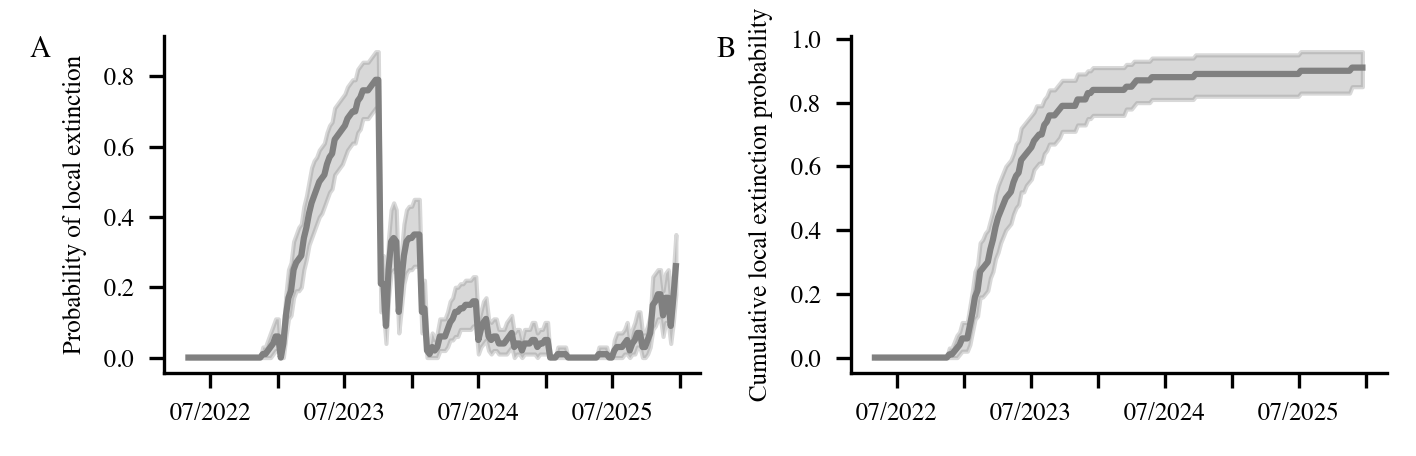

In [49]:
def jan_only_formatter(x, pos=None):
    d = mdates.num2date(x)
    return d.strftime('%m/%Y') if d.month == 7 else ''
    #return d.strftime('%y/%m') #if d.month == 1 else d.strftime('%m')

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,2,figsize=(double_col/3*2, 1.5))
    

    
    ax_center_left  =  ax[0]
    ax_bottom_left  =  ax[1]

    model_dict = model_2ndinf
    
    ax_center_left.plot(t_label, model_dpsi["die_out_prob"].mean(axis = 0), color = "grey")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"])
    ax_center_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey")
    ax_center_left.set_ylabel("Probability of local extinction")
    ax_center_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_center_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))


    ax_bottom_left.plot(t_label, model_dpsi["die_out_prob"].cummax(axis=1).astype(int).mean(axis = 0), color = "grey")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"].cummax(axis=1).astype(int))
    ax_bottom_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey")
    ax_bottom_left.set_ylabel("Cumulative local extinction probability")
    ax_bottom_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_bottom_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))


    axes = [ax_center_left, ax_bottom_left, ax_right]
    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            -0.25, 1, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=7, fontweight="bold"
        )    
    plt.tight_layout()
    plt.savefig(figure_path / "figure4_suppl.svg")
    plt.savefig(figure_path / "figure4_suppl.pdf")


    plt.show()


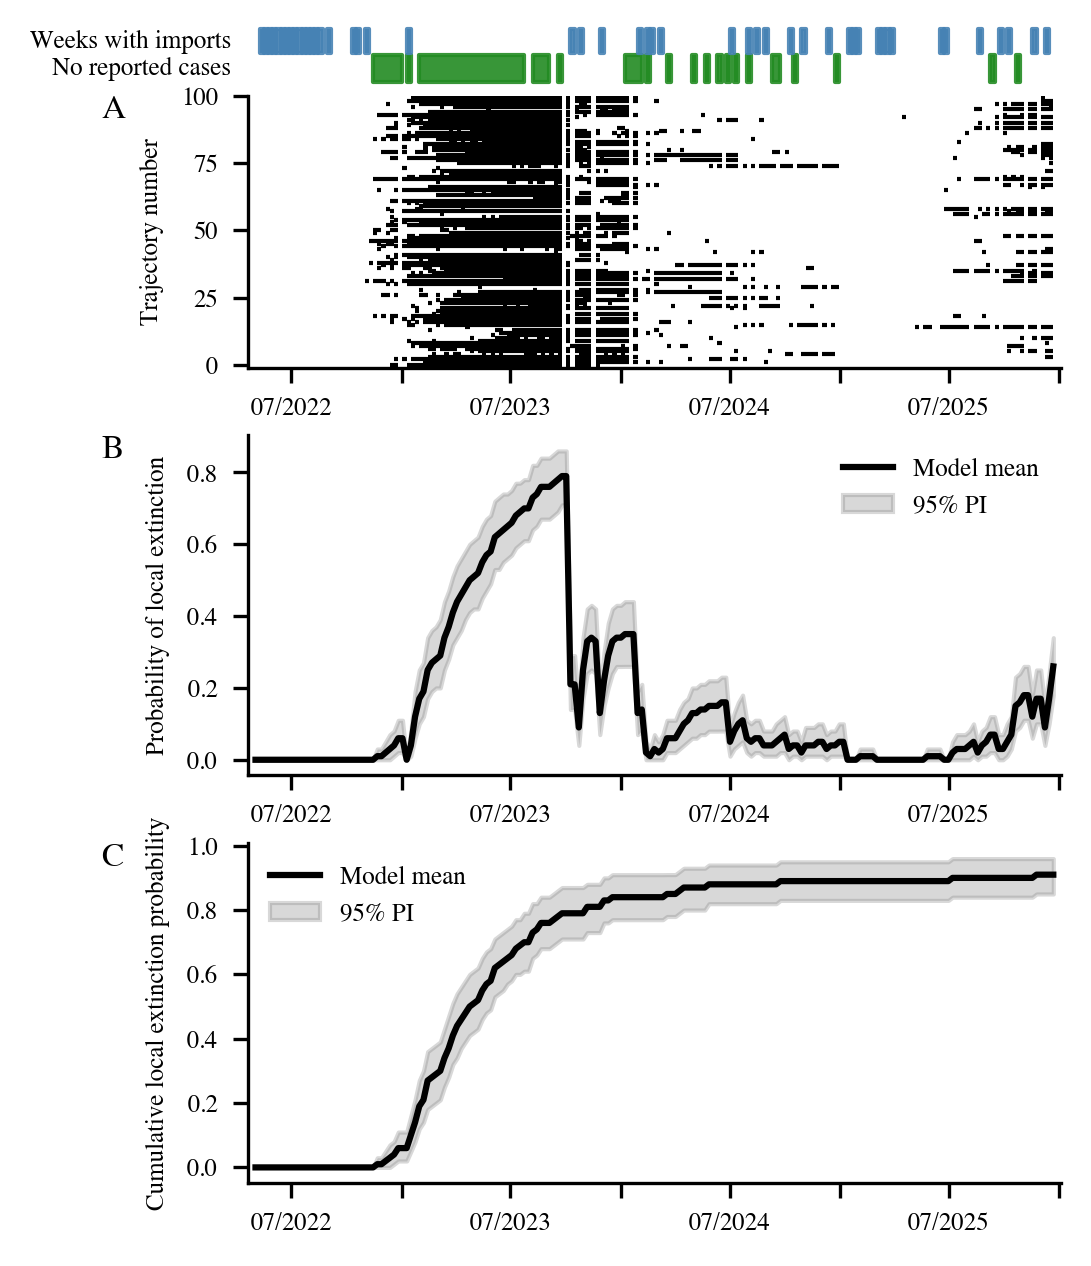

In [50]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(3,1,figsize=(double_col/2, 5))
    

    ax_top_left  =  ax[0]
    ax_center_left  =  ax[1]
    ax_bottom_left  =  ax[2]
    

    model_dict = model_2ndinf

    ax_center_left.plot(t_label, model_dpsi["die_out_prob"].mean(axis = 0), color = "black", label = "Model mean")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"])
    ax_center_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey", label = "95% PI")
    ax_center_left.set_ylabel("Probability of local extinction")
    ax_center_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_center_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_center_left.legend(frameon = False)
    ax_center_left.margins(x=0.01)
    ax_bottom_left.margins(x=0.01)


    ax_bottom_left.plot(t_label, model_dpsi["die_out_prob"].cummax(axis=1).astype(int).mean(axis = 0), color = "black", label = "Model mean")
    lower_dpsi, upper_dpsi = ci_by_bootstrap(model_dpsi["die_out_prob"].cummax(axis=1).astype(int))
    ax_bottom_left.fill_between(t_label, lower_dpsi, upper_dpsi, alpha = 0.3, color = "grey", label = "95% PI")
    ax_bottom_left.set_ylabel("Cumulative local extinction probability")
    ax_bottom_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_bottom_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    ax_bottom_left.legend(frameon = False)

    df = model_dict["infection"] 
    for i in range(len(df)):
        y = i                       # unique y position for this row
        vals = df.iloc[i, :].to_numpy()
        is_zero = (vals == 0)

        # draw a small horizontal segment for each time where value is zero
        x = np.where(is_zero)[0]
        for t in x:
            ax_top_left.hlines(y, t_label[t-1], t_label[t], color="black", linewidth=1)

    ax_top_left.set_ylim(-1, len(df))
    pos = ax_top_left.get_position()
    ax_top_left.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])

    reported = berlin_mpox_all["reported_cases"].to_numpy()
    is_zero_rep = (reported == 0).astype(int)

    changes = np.diff(np.r_[0, is_zero_rep, 0])
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    # shade the zero regions
    for s, e in zip(starts, ends):
        if s > 5:
            #ax_top_left.axvspan(t_label[s], t_label[e], color="forestgreen", alpha=0.2)
            ax_top_left.fill_between([t_label[s], t_label[e]], 105, [115, 115], color="forestgreen", alpha=0.9, clip_on=False)

    # star for import
    for i in range(len(imports_t)):
        if imports_t[i] > 0:
            #ax_top_left.scatter(t_label[i], [115], marker='*', s=2, color='black', #edgecolor='black', clip_on=False)
            ax_top_left.fill_between([t_label[i],t_label[i+1]], 116, [125, 125], color="steelblue", alpha=0.9, clip_on=False)

    #ax_top_left.subplots_adjust(top=0.85)
    legend_elements = [
    Line2D([0], [0], color='black', lw=1, label='No simulated cases'),
        Patch(facecolor='forestgreen', edgecolor='forestgreen', alpha=0.9, label='No reported cases (Berlin)'),
        Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.9, label='Weeks with imports')
        ]
    
    ax_top_left.text(-0.02, 120, "Weeks with imports",
        transform=ax_top_left.get_yaxis_transform(),
        ha='right', va='center',
        clip_on=False)
    
    ax_top_left.text(-0.02, 110, "No reported cases",
        transform=ax_top_left.get_yaxis_transform(),
        ha='right', va='center',
        clip_on=False)

    #ax_top_left.legend(handles=legend_elements, frameon=False, ncol = 2)
    ax_top_left.set_ylabel("Trajectory number")
    ax_top_left.set_xlim(ax_center_left.get_xlim())
    ax_top_left.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    ax_top_left.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))


    axes = [ax_top_left, ax_center_left, ax_bottom_left]
    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            -0.18, 1., lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8, fontweight="bold"
        )    
    #plt.tight_layout()
    plt.savefig(figure_path / "figure4_suppl_raw.svg")
    #plt.savefig(figure_path / "figure4_suppl.pdf")


    plt.show()


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/743664639.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res_df["extinction"] = res_df["extinction"].fillna(1)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/743664639.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res_df["extinction"] = res_df["extinction"].fillna(1)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/743664639.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future v

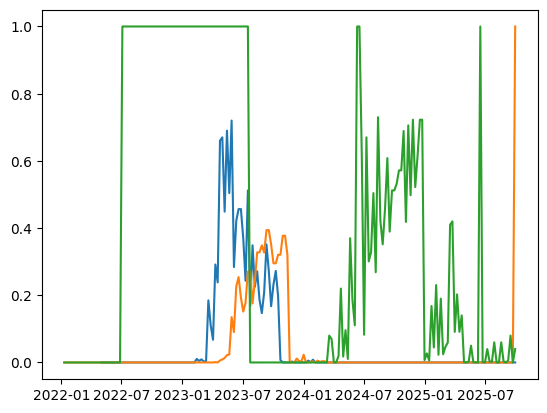

    start_date  number_countries start_date_EU    ext_res_EU  \
0   2022-05-02                 7           NaT  0.000000e+00   
1   2022-05-09                13           NaT  0.000000e+00   
2   2022-05-16                19    2022-05-16  0.000000e+00   
3   2022-05-23                21    2022-05-23  0.000000e+00   
4   2022-05-30                26    2022-05-30  0.000000e+00   
..         ...               ...           ...           ...   
174 2025-09-01                 7    2025-09-01  0.000000e+00   
175 2025-09-08                 6    2025-09-08  6.400000e-11   
176 2025-09-15                 7    2025-09-15  1.280000e-12   
177 2025-09-22                 6    2025-09-22  7.290000e-10   
178 2025-09-29                 3    2025-09-29  6.400000e-05   

     ext_lower_res_EU  ext_upper_res_EU  AMRO start_date_AMRO  ext_res_AMRO  \
0                 0.0      0.000000e+00   1.0             NaT  0.000000e+00   
1                 0.0      0.000000e+00   3.0             NaT  0.000000e+

In [51]:
lower_2ndinf, upper_2ndinf = ci_by_bootstrap(model_2ndinf["die_out_prob"])
die_out_local_df = pd.DataFrame({
    "start_date": t_label,
    "2ndinf": model_2ndinf["die_out_prob"].mean(axis = 0), 
    "lower_2ndinf": lower_2ndinf,
    "upper_2ndinf": upper_2ndinf,
    })


tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-2] = die_out_local_df.loc[2:, "start_date"].values
die_out_local_df["start_date_EU"] = tmp
tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-6] = die_out_local_df.loc[6:, "start_date"].values
die_out_local_df["start_date_AMRO"] = tmp
tmp = np.zeros_like(die_out_local_df.loc[:, "start_date"].values)
tmp[:-64] = die_out_local_df.loc[64:, "start_date"].values
die_out_local_df["start_date_WPRO"] = tmp

die_out_shifted = die_out_local_df#[["start_date_shifted", "dpsi", "lower_dpsi", "upper_dpsi"]]
die_out_shifted = die_out_shifted.rename(columns={"2ndinf": "extinction", "lower_2ndinf": "extinction_lower", "upper_2ndinf": "extinction_upper"})


def merge_extinction_prob(df, date_col, col, label):

    res_df = df.merge(
        die_out_shifted[[date_col, "extinction", "extinction_lower", "extinction_upper"]],
        left_on="start_date",
        right_on=date_col,
        how="left"
    )

    res_df["extinction"] = res_df["extinction"].fillna(1)
    res_df["extinction_lower"] = res_df["extinction_lower"].fillna(1)
    res_df["extinction_upper"] = res_df["extinction_upper"].fillna(1)

    res_df["ext_res_"+label] = res_df["extinction"] ** res_df[col]
    res_df["ext_lower_res_"+label] = res_df["extinction_lower"] ** res_df[col]
    res_df["ext_upper_res_"+label] = res_df["extinction_upper"] ** res_df[col]

    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_res_"+label] = 0
    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_lower_res_"+label] = 0
    res_df.loc[res_df["start_date"] < "2022-07-01", "ext_upper_res_"+label] = 0

    res_df = res_df.drop(columns=["extinction", "extinction_lower", "extinction_upper"])

    return(res_df)

euro_df = merge_extinction_prob(countries_with_cases[["start_date", "number_countries"]], "start_date_EU", "number_countries", "EU")
amro_df = merge_extinction_prob(plot_df[["start_date", "AMRO"]], "start_date_AMRO", "AMRO", "AMRO")
wpro_df = merge_extinction_prob(plot_df[["start_date", "WPRO"]], "start_date_WPRO", "WPRO", "WPRO")

plt.plot(euro_df["start_date"], euro_df["ext_res_EU"])
plt.plot(amro_df["start_date"], amro_df["ext_res_AMRO"])
plt.plot(wpro_df["start_date"], wpro_df["ext_res_WPRO"])
plt.show()


merged_df = euro_df.merge(
    amro_df,
    left_on="start_date",
    right_on = "start_date",
    how = "left"
)

merged_df = merged_df.merge(
    wpro_df,
    left_on="start_date",
    right_on = "start_date",
    how = "left"
)

print(merged_df)



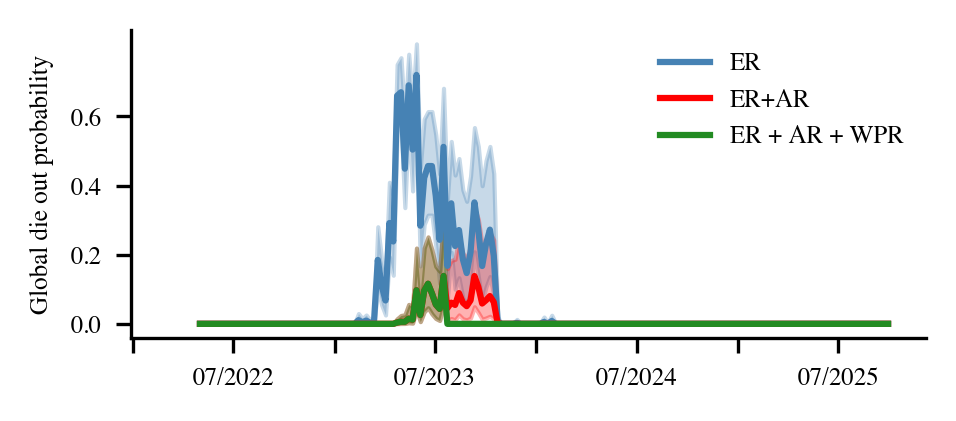

In [52]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,1,figsize=(single_col, 4/3))

    # C
    axC = ax
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"], label = "ER", color = "steelblue")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"],merged_df["ext_upper_res_EU"], alpha = 0.3, color = "steelblue")
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"] * merged_df["ext_res_AMRO"], label = "ER+AR", color = "red")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"] * merged_df["ext_lower_res_AMRO"],merged_df["ext_upper_res_EU"]*merged_df["ext_upper_res_AMRO"], alpha = 0.3, color = "red")
    #axC.plot(merged_df["start_date"], merged_df["ext_euro"] * merged_df["ext_asia"], label = "Europe + WP")
    #axC.fill_between(merged_df["start_date"], merged_df["ext_euro_lower"] * merged_df["ext_asia_lower"],merged_df["ext_euro_upper"]*merged_df["ext_asia_upper"], alpha = 0.3)
    axC.plot(merged_df["start_date"], merged_df["ext_res_EU"] * merged_df["ext_res_AMRO"]* merged_df["ext_res_WPRO"], label = "ER + AR + WPR", color = "forestgreen")
    axC.fill_between(merged_df["start_date"], merged_df["ext_lower_res_EU"] * merged_df["ext_lower_res_AMRO"]* merged_df["ext_lower_res_WPRO"],merged_df["ext_upper_res_EU"] * merged_df["ext_upper_res_AMRO"]* merged_df["ext_upper_res_WPRO"], alpha = 0.3, color = "forestgreen")
    axC.set_ylabel("Global die out probability")
    axC.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axC.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    #axC.set_ylabel("Probability of no active infections")
    axC.legend(frameon=False)
    axC.set_xlim(axA.get_xlim())
    axC.set_yticks([0, 0.2, 0.4, 0.6])

    #plt.tight_layout()
    plt.savefig(figure_path / "figure5_suppl.svg")
    plt.savefig(figure_path / "figure5_suppl.pdf")

    plt.show()

# Other Supplementary Figures


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_3090/782207089.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


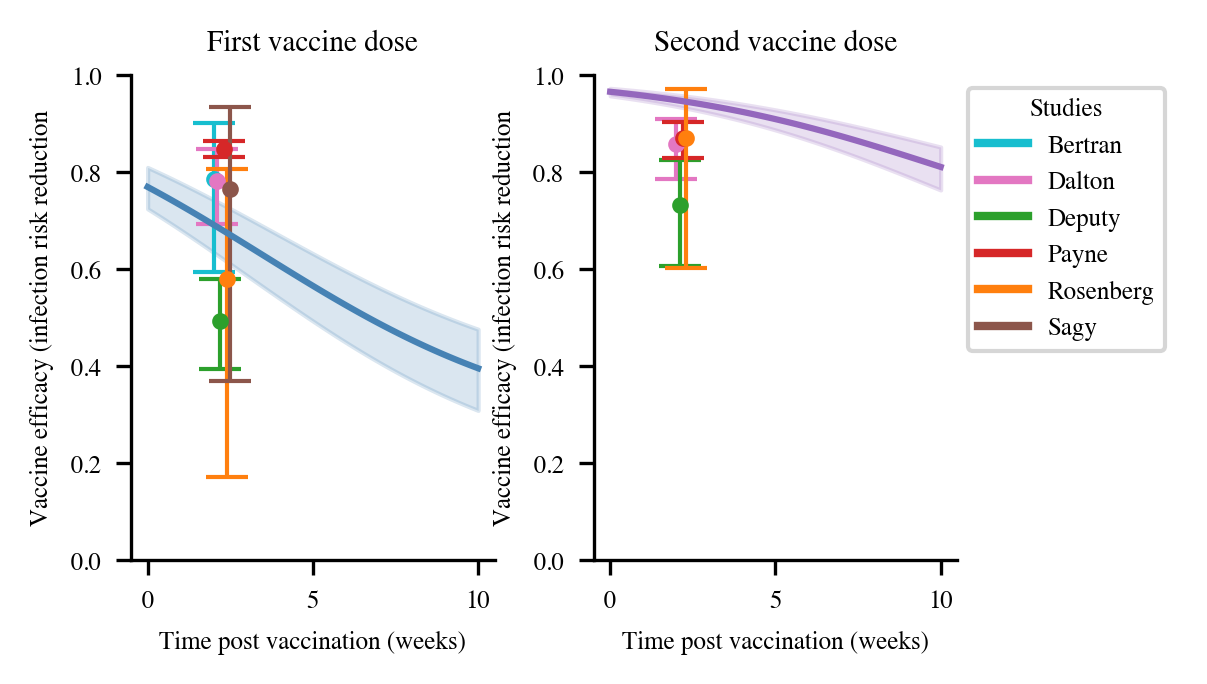

In [56]:
ve_studies = pd.read_csv("/Users/nilsgubela/Desktop/Projects/Ideas/MPox/Hawkes/mpox_hawkes/Mpox_ELISA_Effectiveness_correlates-main/Output/Figure1/Indiv_eff.csv")
ve_studies_1 = ve_studies[ve_studies["Vaccine"] == 2].reset_index(drop=True)
ve_studies_2 = ve_studies[ve_studies["Vaccine"] == 3].reset_index(drop=True)

def ab_concentration(t, x0, f):
    delta_l = 0.0028
    delta_s = 0.23

    xs = x0 * f * np.exp(-delta_s * t)
    xl = x0 * (1-f) * np.exp(-delta_l * t)

    return(xs+xl)

def efficacy(c_t, ic50):
    return(c_t/(c_t + ic50))  

ic50 = 23.980360677686917


colors = {"Bertran": 'tab:cyan',
          "Dalton": 'tab:pink',
          "Deputy": 'tab:green',
          "Payne": 'tab:red',
          "Rosenberg": 'tab:orange',
          "Sagy": 'tab:brown'}

with plt.rc_context(STYLE):

    #fig, ax = plt.subplots(1, 3, figsize=(single_half_col, 2))
    fig = plt.figure(
        figsize=(single_half_col, 2.1),
    )
    gs = fig.add_gridspec(1, 3,width_ratios=[3, 3, 1],wspace=0.35)
    ax = [fig.add_subplot(gs[0, 0]),fig.add_subplot(gs[0, 1]),fig.add_subplot(gs[0, 2])]


    for i in range(len(ve_studies_1)):
        color = colors[ve_studies_1.loc[i, "Study"]]
        yerr = np.array([[ve_studies_1.loc[i, "X50."] - ve_studies_1.loc[i, "X2.5."]], [ve_studies_1.loc[i, "X97.5."] - ve_studies_1.loc[i, "X50."]]])
        ax[0].errorbar(2+i/10, ve_studies_1.loc[i, "X50."]/100, fmt='o', yerr=yerr/100, capsize=5, ms = 3, color = color, elinewidth = 1)

    for i in range(len(ve_studies_2)):
        color = colors[ve_studies_2.loc[i, "Study"]]
        yerr = np.array([[ve_studies_2.loc[i, "X50."] - ve_studies_2.loc[i, "X2.5."]], [ve_studies_2.loc[i, "X97.5."] - ve_studies_2.loc[i, "X50."]]])
        ax[1].errorbar(2+i/10, ve_studies_2.loc[i, "X50."]/100, fmt='o', yerr=yerr/100, capsize=5, ms = 3, color = color, elinewidth = 1)

    ax[0].set_ylim(0,1)
    ax[1].set_ylim(0,1)

    # plot 1 dose
    t = np.linspace(0,10,100)
    mean = efficacy(ab_concentration(t, 80, 0.89), ic50)
    ax[0].plot(t,mean, color = "steelblue")
    lower = efficacy(ab_concentration(t, 63, 0.92), ic50)
    upper = efficacy(ab_concentration(t, 102, 0.87), ic50)
    ax[0].fill_between(t, lower, upper, alpha = 0.2, color = "steelblue")

    # plot 2 dose
    c_t = ab_concentration(t, 673, 0.94)
    mean = efficacy(ab_concentration(t, 673, 0.94),ic50)
    ax[1].plot(t,mean, color = "tab:purple")
    lower = efficacy(ab_concentration(t, 537, 0.95), ic50)
    upper = efficacy(ab_concentration(t, 854, 0.93), ic50)
    ax[1].fill_between(t, lower, upper, alpha = 0.2, color = "tab:purple")

    
    ax[0].set_xlabel("Time post vaccination (weeks)")
    ax[1].set_xlabel("Time post vaccination (weeks)")

    ax[0].set_ylabel("Vaccine efficacy (infection risk reduction")
    ax[1].set_ylabel("Vaccine efficacy (infection risk reduction")

    ax[0].set_title("First vaccine dose")
    ax[1].set_title("Second vaccine dose")

    legend_handles = [
        Line2D([0], [0], color=colors[key], lw=2, label=key)
        for key in colors.keys()
    ]
    ax[2].legend(handles=legend_handles, title='Studies')
    ax[2].legend(handles=legend_handles, title='Studies')


    ax[2].spines[['bottom', "left"]].set_visible(False)
    ax[2].set_yticks([])
    ax[2].set_xticks([])
    plt.tight_layout()

    plt.savefig(figure_path / "ic50_fitting.pdf", bbox_inches='tight')
    plt.show()


Single dose efficacy after 2 years: 0.17010497523147025
2-dose efficacy after 2 years: 0.48467965287307646


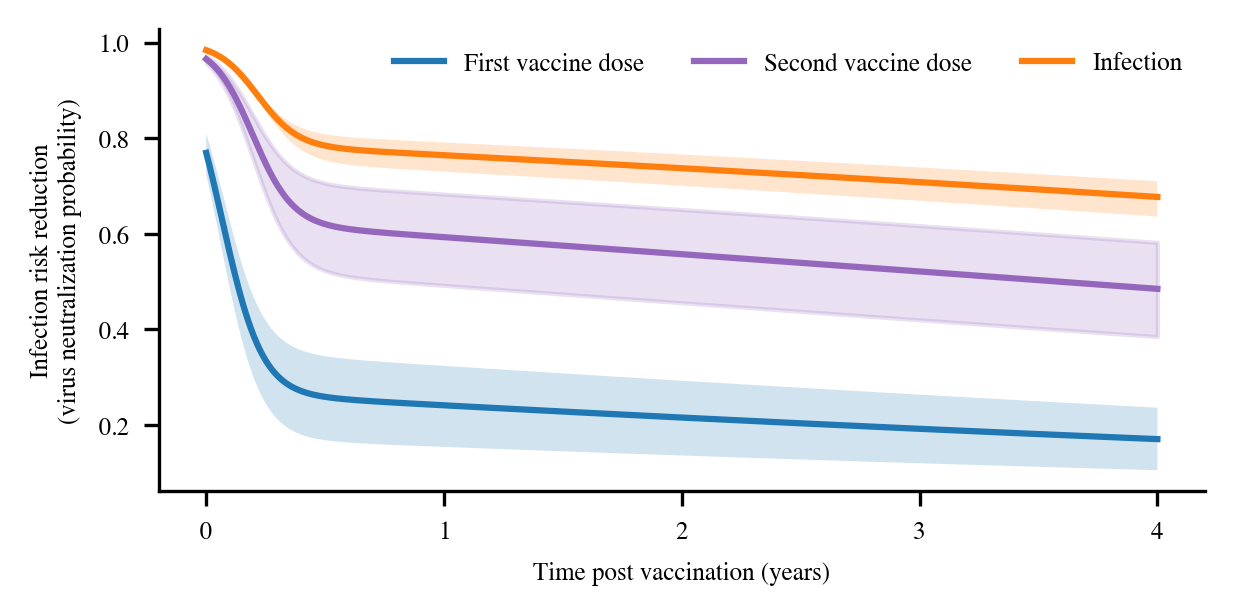

In [61]:

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(single_half_col, 2))

    # plot 1 dose
    t = np.linspace(0,52*4,1000)
    mean = efficacy(ab_concentration(t, 80, 0.89), ic50)
    ax.plot(t,mean, label = "First vaccine dose")
    lower = efficacy(ab_concentration(t, 63, 0.92), ic50)
    upper = efficacy(ab_concentration(t, 102, 0.87), ic50)
    ax.fill_between(t, lower, upper, alpha = 0.2)
    print("Single dose efficacy after 2 years:", mean[-1])

    # plot 2 dose
    mean = efficacy(ab_concentration(t, 673, 0.94), ic50)
    ax.plot(t,mean, label = "Second vaccine dose",color = "tab:purple")
    lower = efficacy(ab_concentration(t, 537, 0.95), ic50)
    upper = efficacy(ab_concentration(t, 854, 0.93), ic50)
    ax.fill_between(t, lower, upper, alpha = 0.2, color = "tab:purple")
    print("2-dose efficacy after 2 years:", mean[-1])


    # plot infection induced
    mean = efficacy(ab_concentration(t, 1500, 0.94), ic50)
    lower = efficacy(ab_concentration(t, 1500, 0.95), ic50)
    upper = efficacy(ab_concentration(t, 1500, 0.93), ic50)
    ax.fill_between(t, lower, upper, alpha = 0.2)
    ax.plot(t,mean, label = "Infection")

    ax.set_xticks([0,52,2*52,3*52, 4*52], [0, 1, 2, 3, 4])
    ax.set_xlabel("Time post vaccination (years)")

    ax.set_ylabel("Infection risk reduction\n(virus neutralization probability)")



    ax.legend(frameon = False, ncol = 3)
    plt.savefig(figure_path / "vaccine_efficacies.pdf", bbox_inches='tight')

    plt.show()

2.0
1.0987791342952276
1.2949640287769784 0.929141248240263
Diagnosis prob 1st inf: 0.18330356392052163 [ 0.1782702719721812 , 0.19928246206094838 ]
Diagnosis prob reinf: 0.1070655741306472 [ 0.0890672764864474 , 0.13205183251619473 ]
Mean: 1873.68 95\% CI: 1485.32 2368.47
Mean: 415.21 95\% CI: 321.95 536.77
Mean: 559.0 95\% CI: 434.32 691.72
Mean: 899.47 95\% CI: 708.4 1119.1
Mean: 1562.17 95\% CI: 1113.55 2061.55
Mean: 348.37 95\% CI: 248.28 451.97
Mean: 468.44 95\% CI: 332.48 614.2
Mean: 745.36 95\% CI: 530.9 1009.75
Mean: 5.27 95\% CI: 4.92 5.52
Mean: 5.09 95\% CI: 4.76 5.32
Mean: 7.42 95\% CI: 6.06 8.79
Mean: 5.05 95\% CI: 4.71 5.26
Mean: 0.87 95\% CI: 0.82 0.91
Mean: 0.87 95\% CI: 0.82 0.91


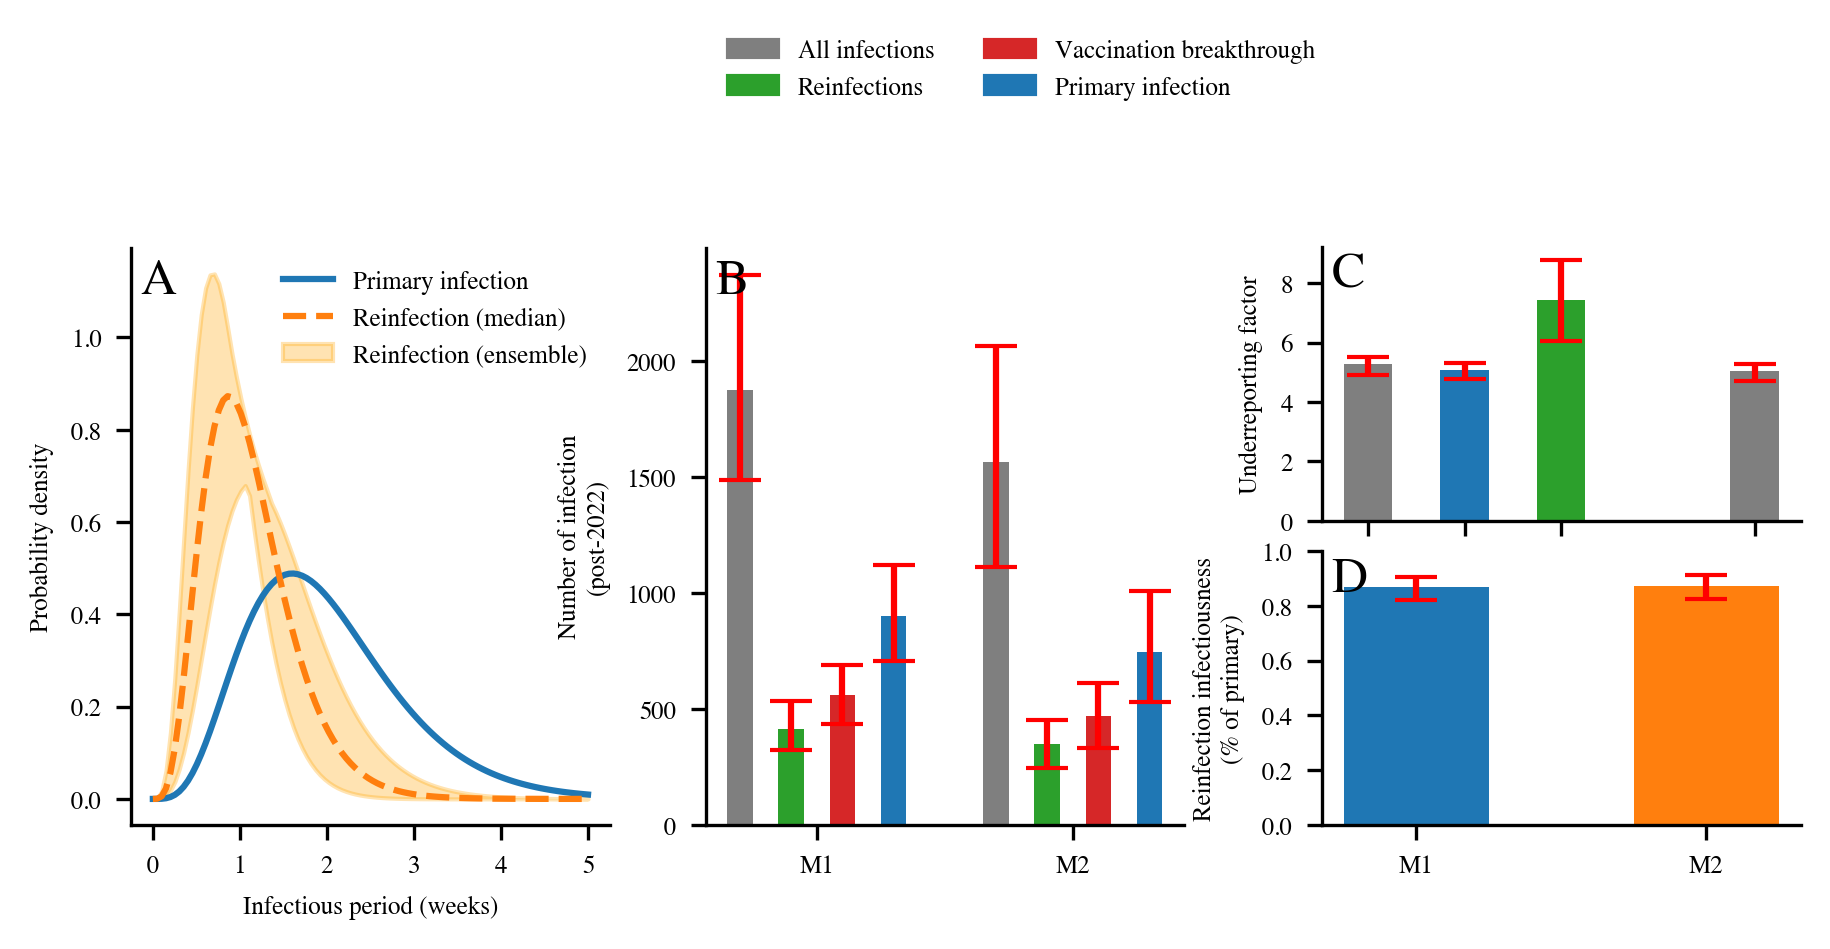

In [76]:
# Infectious period difference | case comparision | underreporting 
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd', "gold"]
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,3,figsize=(double_col, 2.5))

    # A
    axA = ax[0]
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    dpsi_parameters = pd.read_csv(file_path)

    scale_I = 2/5
    dpsi_parameters["diag_prob"] = 1 - (1/scale_I/(dpsi_parameters["diag"]+1/scale_I))**5
    dpsi_parameters["diag_prob2"] = 1 - (dpsi_parameters["dpsi"]/scale_I/(dpsi_parameters["diag"]+dpsi_parameters["dpsi"]/scale_I))**5

    # create infectious period for reinfection
    t = np.linspace(0,5,100)
    tmp_res = []
    for i in range(len(dpsi_parameters)):
        tmp_res.append(erlang.pdf(t, a = 5, scale = scale_I/dpsi_parameters["dpsi"][i]))

    si_df = pd.DataFrame(tmp_res)

    axA.plot(t, erlang.pdf(t, a = 5, scale = scale_I), label = "Primary infection")
    print(5*scale_I)
    axA.plot(t, si_df.mean(axis = 0), linestyle = "dashed", label = "Reinfection (median)")
    axA.fill_between(t, si_df.min(axis = 0), si_df.max(axis = 0), alpha = 0.3, color = "orange", label = "Reinfection (ensemble)")

    print(5*scale_I/dpsi_parameters["dpsi"].mean())
    print(5*scale_I/dpsi_parameters["dpsi"].quantile(0.025), 5*scale_I/dpsi_parameters["dpsi"].quantile(0.975))

    print("Diagnosis prob 1st inf:", dpsi_parameters["diag_prob"].mean(), "[",dpsi_parameters["diag_prob"].quantile(0.025),"," ,dpsi_parameters["diag_prob"].quantile(0.975),"]")
    print("Diagnosis prob reinf:", dpsi_parameters["diag_prob2"].mean(), "[",dpsi_parameters["diag_prob2"].quantile(0.025),"," ,dpsi_parameters["diag_prob2"].quantile(0.975),"]")

    axA.legend(frameon=False)
    #plt.xlabel("Weeks since symptom onset")
    axA.set_xlabel("Infectious period (weeks)")
    axA.set_ylabel("Probability density")

    # B
    axB = ax[1]
    for i,model_dict in enumerate(model_dicts[:2]):
        plot_bar(model_dict["infection"].loc[:,26:].sum(axis = 1), i/2 , "tab:grey", axB)
        plot_bar(model_dict["reinfection"].loc[:,26:].sum(axis = 1), i/2+0.1 , "tab:green", axB)
        plot_bar(model_dict["reinfectionV"].loc[:,26:].sum(axis = 1), i/2+0.2 , "tab:red", axB)
        plot_bar(model_dict["infectionS"].loc[:,26:].sum(axis = 1)+model_dict["infectionSBR"].loc[:,26:].sum(axis = 1), i/2+0.3 , "tab:blue", axB)
        
    handles = [
        mpatches.Patch(color="tab:grey",   label="All infections"),
        mpatches.Patch(color="tab:green", label="Reinfections"),
        mpatches.Patch(color="tab:red",       label="Vaccination breakthrough"),
        mpatches.Patch(color="tab:blue",       label="Primary infection"),
    ]
    axB.legend(handles=handles, frameon=False, ncols = 2, loc = "upper left",  bbox_to_anchor=(0., 1.4))

    axB.set_xticks(np.arange(2)/2+0.15, ["M1", "M2"])
    
    axB.set_ylabel("Number of infection\n(post-2022)")

    # C 
    axC = ax[2]
    pos = axC.get_position()
    axC.remove()

    gap = 0.05 * pos.height
    h = (pos.height - gap) / 2

    axC1 = fig.add_axes([pos.x0 + 0.02, pos.y0 +h+0.04, pos.width, h])  # top
    axC2 = fig.add_axes([pos.x0 + 0.02, pos.y0,            pos.width, h])  # bottom

    #axC1.sharex(axC2)
    #axC1.tick_params(labelbottom=False)
    # underreporting factor overall
    plot_bar(model_dpsi["infection"].sum(axis = 1)/model_dpsi["diagnosis"].sum(axis = 1), 0 , "tab:grey", axC1)
    # underreporting first infection
    plot_bar((model_dpsi["infectionS"].sum(axis = 1)+model_dpsi["infectionSBR"].sum(axis = 1))/model_dpsi["diagnosis1"].sum(axis = 1), 0.1, "tab:blue", axC1)
    # underreporting reinfection
    plot_bar((model_dpsi["reinfection"].sum(axis = 1)+model_dpsi["reinfectionV"].sum(axis = 1))/model_dpsi["diagnosis2"].sum(axis = 1), 0.2, "tab:green", axC1)
    
    # undereporting factor overall for reinf 
    axC1.set_ylabel("Underreporting factor")
    plot_bar(model_2ndinf["infection"].sum(axis = 1)/model_2ndinf["diagnosis"].sum(axis = 1), 0.4 , "tab:grey", axC1)

    axC1.set_xticks([0,0.1,0.2, 0.4], ["Overall", "Primary", "Reinfection", "M2"], rotation = 45)

    # C2
    # Re-Duration
    file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
    params_reduration = pd.read_csv(file_path)

    # Re-Inf
    file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
    params_reinf = pd.read_csv(file_path)

    # infection probability 
    scale_I = 2/5
    params_reduration["infection_prob"] = 1 - ((1/scale_I)/(params_reduration["beta"] + (1/scale_I)))**5
    params_reduration["infection_prob2"] = 1 - ((params_reduration["dpsi"]/scale_I)/(params_reduration["beta"] + (params_reduration["dpsi"]/scale_I)))**5
    params_reduration["inf_reduction"] = params_reduration["infection_prob2"]/params_reduration["infection_prob"]

    params_reinf["infection_prob"] = 1 - ((1/scale_I)/(params_reinf["beta"] + (1/scale_I)))**5
    params_reinf["infection_prob2"] = 1 - ((1/scale_I)/(params_reinf["beta"]*params_reinf["infectiousness_2nd_factor"] + (1/scale_I)))**5
    params_reinf["inf_reduction"] = params_reinf["infection_prob2"]/params_reinf["infection_prob"]

    # infectious reduction Re-Duration
    plot_bar(params_reduration["inf_reduction"], 0 , colors[0], axC2)
    
    # infectious reduction Re-Inf
    plot_bar(params_reinf["inf_reduction"], 0.1 , colors[1], axC2)


    #plt.ylabel("Infectiousness reduction\nin reinfections (%)")
    axC2.set_ylabel("Reinfection infectiousness\n(% of primary)")

    axC2.set_xticks([0,0.1], ["M1", "M2"])
    axC2.set_ylim(top = 1.0)

    axes = [axA, axB, axC1, axC2]   

    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,  
            ha="left", va="top",
            fontsize=12, fontweight="bold"
            # optionally: bbox=dict(facecolor="white", edgecolor="none", pad=1)
        )

    #fig.tight_layout()

    plt.savefig(figure_path / "m1_versus_m2.svg")

    plt.show()


In [80]:
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(1,3,figsize=(double_col, 1.5))

    axA = ax[0]
    file_path = current_dir.parent / 'data/european/MSM_pops_EMIS2011.csv'
    emis_pop = pd.read_csv(file_path)
    emis_pop = emis_pop.sort_values(["Npop_truncated"], ascending=False).reset_index(drop = True)
    axA.scatter(emis_pop.index, emis_pop["Npop_truncated"]/np.max(emis_pop["Npop_truncated"]), color = "forestgreen", label = "EMIS")
    x = np.arange(len(emis_pop))
    axA.plot(x, np.exp(-0.15*x), color = "red", label = "Approximation")

    axA.set_ylabel("MSM size (normalised)")
    axA.set_xlabel("Country rank")
    axA.legend(frameon=False)
    
    # D
    axD = ax[1]
    file_path = current_dir.parent / 'results/model_die_out_global/result_dpsi.csv'
    res_dpsi = pd.read_csv(file_path)
    file_path = current_dir.parent / 'results/model_die_out_global/result_2ndinf.csv'
    res_2ndinf = pd.read_csv(file_path)
    axD.plot(t_label, res_dpsi.mean(axis = 0),label = "Re-Duration", color = "tab:blue")
    axD.fill_between(t_label, res_dpsi.quantile(0.025, axis = 0), res_dpsi.quantile(0.975, axis = 0), alpha = 0.3, color = "tab:blue")
    axD.plot(t_label, res_2ndinf.mean(axis = 0),label = "Re-Infection", color = "tab:green")
    axD.fill_between(t_label, res_2ndinf.quantile(0.025, axis = 0), res_2ndinf.quantile(0.975, axis = 0), alpha = 0.3, color = "tab:green")
    axD.set_ylabel("No. of countries reporting mpox\n(weekly, simulation)")
    axD.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axD.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    axD.legend(frameon= False)

    # E
    axE = ax[2]
    zero_counts = (res_dpsi == 0).sum()
    axE.plot(t_label,zero_counts/len(res_dpsi),label = "Re-Duration", color = "tab:blue")

    zero_counts = (res_2ndinf == 0).sum()
    axE.plot(t_label,zero_counts/len(res_2ndinf),label = "Re-Infection", color = "tab:green")
    axE.set_ylabel("Global die out probability")
    axE.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7), bymonthday=1))
    axE.xaxis.set_major_formatter(FuncFormatter(jan_only_formatter))
    axE.legend(frameon = False)

    axes = [axA,axD,axE]
    for lab, ax in zip(string.ascii_uppercase, axes):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=12, fontweight="bold"
            # optionally: bbox=dict(facecolor="white", edgecolor="none", pad=1)
        )    
    plt.tight_layout()
    plt.savefig(figure_path / "si_meta_model_raw.svg")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nilsgubela/Desktop/Projects/Papers/Mpox_endemic/MPoxAfter2022/results/model_die_out_global/result_dpsi.csv'